In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
import missingno as msno
import scipy.stats as st
import plotly.express as px
import matplotlib.pyplot as plt
from collections import Counter
import warnings 
warnings.filterwarnings("ignore")
sns.set(color_codes = True)   
sns.set_palette(palette = 'crest', n_colors = 8)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:

# ══════════════════════════════════════════════════════════════
# STEP 0 — Auto-detect bands for any TIF file or folder
# ══════════════════════════════════════════════════════════════
 
def inspect_tif(path):
    """
    Print full profile of a TIF file.
    Call this first to understand what you are working with.
    """
    print("=" * 60)
    print(f"  FILE : {os.path.basename(path)}")
    print("=" * 60)
    with rasterio.open(path) as src:
        size_mb = os.path.getsize(path) / 1e6
        print(f"  Band count     : {src.count}")
        print(f"  Width x Height : {src.width} x {src.height}")
        print(f"  Data type      : {src.dtypes[0]}")
        print(f"  CRS            : {src.crs}")
        print(f"  NoData         : {src.nodata}")
        print(f"  File size      : {size_mb:.2f} MB")
        print()
        print("  Per-band stats:")
        for i in range(1, src.count + 1):
            band = src.read(i).astype(float)
            print(f"    Band {i:>3}  |  "
                  f"min={band.min():.3f}  "
                  f"max={band.max():.3f}  "
                  f"mean={band.mean():.3f}")
    print()
    return src.count
 
 
def inspect_folder(folder, pattern="*.tif"):
    """
    Batch-inspect all TIF files in a folder.
    """
    files = sorted(glob.glob(os.path.join(folder, pattern)))
    if not files:
        print(f"No TIF files found in: {folder}")
        return
 
    print(f"\n{'File':<35} {'Bands':>6} {'Width':>7} {'Height':>7} {'MB':>8}")
    print("-" * 70)
    for f in files:
        with rasterio.open(f) as src:
            mb = os.path.getsize(f) / 1e6
            print(f"{os.path.basename(f):<35} {src.count:>6} "
                  f"{src.width:>7} {src.height:>7} {mb:>8.1f}")
    print()

In [3]:

# ══════════════════════════════════════════════════════════════
# STEP 1 — Straighten tilted TIF (reproject to north-up)
# ══════════════════════════════════════════════════════════════
 
def straighten_tif(input_path, output_path=None, dst_crs="EPSG:4326"):
    """
    Reproject a tilted/rotated TIF to a standard CRS so it appears north-up.
 
    Args:
        input_path  : path to raw .tif
        output_path : where to save (default: same folder, prefix 'straight_')
        dst_crs     : target CRS. Use UTM for your zone, e.g.:
                        'EPSG:32644'  UTM zone 44N (central India / Pune)
                        'EPSG:4326'   WGS84 geographic (default)
    Returns:
        output_path
    """
    if output_path is None:
        d = os.path.dirname(input_path)
        b = os.path.basename(input_path)
        output_path = os.path.join(d, f"straight_{b}")
 
    print(f"[Straighten] {os.path.basename(input_path)} → {os.path.basename(output_path)}")
 
    with rasterio.open(input_path) as src:
        n_bands = src.count
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update({
            "crs":       dst_crs,
            "transform": transform,
            "width":     width,
            "height":    height,
            "nodata":    src.nodata if src.nodata is not None else 0,
        })
        with rasterio.open(output_path, "w", **kwargs) as dst:
            for i in range(1, n_bands + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.bilinear,
                )
 
    print(f"           Done — {n_bands} bands reprojected.\n")
    return output_path

def straighten_folder(folder, dst_crs="EPSG:4326", pattern="*.tif"):
    """Batch-straighten all TIF files in a folder."""
    out_folder = os.path.join(folder, "straightened")
    os.makedirs(out_folder, exist_ok=True)
    files = sorted(glob.glob(os.path.join(folder, pattern)))
    print(f"[Batch Straighten] {len(files)} files → {out_folder}\n")
    for f in files:
        out = os.path.join(out_folder, f"straight_{os.path.basename(f)}")
        straighten_tif(f, out, dst_crs)
    return out_folder

In [4]:
# ══════════════════════════════════════════════════════════════
# STEP 2 — Helper: normalize band to 0–255
# ══════════════════════════════════════════════════════════════
 
def normalize_to_255(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return np.zeros(len(series), dtype=np.uint8)
    return ((series - mn) / (mx - mn) * 255).astype(np.uint8)
 
 

In [5]:

# ══════════════════════════════════════════════════════════════
# STEP 3 — Auto spectral classification (adapts to band count)
# ══════════════════════════════════════════════════════════════
 
def classify_vectorized(df, total_bands):
    """
    Classify pixels using spectral indices.
    Automatically selects NIR and SWIR bands based on total_bands.
 
    Sensor mapping:
        3  bands  → RGB only            (NIR proxy = Red)
        4  bands  → RGB + NIR           (Planetscope, Dove)
        5–7 bands → Landsat-like        (NIR=B4, SWIR=B5)
        8–13 bands → Sentinel-2 like   (NIR=B8, SWIR=B11 clamped)
        ≥100 bands → Hyperspectral      (NIR≈40%, SWIR≈65% of stack)
 
    Returns:
        numpy array of class labels (int)
            0 = Snow / Cloud
            1 = Water
            2 = Vegetation
            3 = Urban / Built-up
            4 = Bare Soil
            5 = Unknown
    """
 
    def norm(s):
        mn, mx = s.min(), s.max()
        return (s - mn) / (mx - mn + 1e-10)
 
    def get_band(idx):
        """Safely fetch a band, clamping index to valid range."""
        idx = max(1, min(int(idx), total_bands))
        return norm(df[f"Band_{idx}"])
 
    # Core visible bands (always present)
    b1n = get_band(1)   # Blue
    b2n = get_band(2)   # Green
    b3n = get_band(3)   # Red
 
    # ── Dynamically pick NIR & SWIR ──────────────────────────
    if total_bands == 3:
        # RGB only: use Red as NIR proxy (limited accuracy)
        nir  = b3n
        swir = b3n
        print("  [Classify] 3-band RGB → Red used as NIR proxy")
 
    elif total_bands == 4:
        # RGB + NIR (e.g. Planetscope)
        nir  = get_band(4)
        swir = get_band(4)
        print("  [Classify] 4-band → Band 4 = NIR")
 
    elif total_bands <= 7:
        # Landsat-like (B, G, R, NIR, SWIR1, SWIR2, ...)
        nir  = get_band(4)
        swir = get_band(5) if total_bands >= 5 else get_band(4)
        print(f"  [Classify] {total_bands}-band Landsat-like → NIR=B4, SWIR=B5")
 
    elif total_bands <= 13:
        # Sentinel-2 (10m: B2,B3,B4,B8 / 20m adds B5,B6,B7,B8A,B11,B12)
        nir  = get_band(8)
        swir = get_band(min(11, total_bands))
        print(f"  [Classify] {total_bands}-band Sentinel-2-like → NIR=B8, SWIR=B{min(11,total_bands)}")
 
    elif total_bands >= 100:
        # Hyperspectral: estimate band positions proportionally
        nir_idx  = int(total_bands * 0.40)   # ~850nm region
        swir_idx = int(total_bands * 0.65)   # ~1600nm region
        nir  = get_band(nir_idx)
        swir = get_band(swir_idx)
        print(f"  [Classify] {total_bands}-band Hyperspectral → "
              f"NIR=B{nir_idx}, SWIR=B{swir_idx}")
 
    else:
        # Generic fallback: middle band as NIR
        mid  = total_bands // 2
        nir  = get_band(mid)
        swir = get_band(mid)
        print(f"  [Classify] {total_bands}-band (generic) → NIR=B{mid}")
 
    # ── Spectral indices ─────────────────────────────────────
    ndvi = (nir - b3n)  / (nir + b3n  + 1e-10)   # Vegetation
    ndwi = (b2n - nir)  / (b2n + nir  + 1e-10)   # Water
    ndbi = (swir - nir) / (swir + nir  + 1e-10)   # Built-up / Urban
    bsi  = ((swir + b3n) - (nir + b1n)) / \
           ((swir + b3n) + (nir + b1n) + 1e-10)   # Bare Soil
 
    # ── Priority-based classification ────────────────────────
    conditions = [
        b1n  > 0.85,   # 0: Snow / Cloud  (very high reflectance)
        ndwi > 0.20,   # 1: Water
        ndvi > 0.30,   # 2: Vegetation
        ndbi > 0.10,   # 3: Urban / Built-up
        bsi  > 0.10,   # 4: Bare Soil
    ]
    return np.select(conditions, [0, 1, 2, 3, 4], default=5)

In [6]:

# ══════════════════════════════════════════════════════════════
# STEP 4 — Main: TIF → DataFrame with all bands + metadata cols
# ══════════════════════════════════════════════════════════════
 
LAND_LABELS = {
    0: "Snow/Cloud",
    1: "Water",
    2: "Vegetation",
    3: "Urban/Built-up",
    4: "Bare Soil",
    5: "Unknown",
}
 
OVERLAY_COLORS = {
    0: "#FFFFFF",   # Snow/Cloud  → White
    1: "#1E90FF",   # Water       → Blue
    2: "#228B22",   # Vegetation  → Green
    3: "#FF4500",   # Urban       → Orange-Red
    4: "#D2691E",   # Bare Soil   → Brown
    5: "#808080",   # Unknown     → Gray
}
 
 
def convert_tif_to_dataframe(image_path, sample_size=50000, nodata_threshold=0):
    """
    Convert ANY TIF file to a pandas DataFrame.
 
    Automatically:
        - Detects number of bands
        - Reads all bands into columns Band_1 … Band_N
        - Computes rgb_hex from Band 1/2/3
        - Classifies land type using spectral indices
        - Adds overlay_hex color per land type
        - Samples down to sample_size rows for plotting
 
    Args:
        image_path        : path to .tif file
        sample_size       : max rows to return in df_sample (default 50000)
        nodata_threshold  : pixels with Band_1 <= this are dropped (default 0)
 
    Returns:
        df_full   : full DataFrame (all valid pixels)
        df_sample : sampled DataFrame for plotting
    """
    print(f"\n{'─'*60}")
    print(f"  Processing: {os.path.basename(image_path)}")
    print(f"{'─'*60}")
 
    # ── Read all bands ────────────────────────────────────────
    with rasterio.open(image_path) as src:
        total_bands = src.count
        height, width = src.height, src.width
        file_mb = os.path.getsize(image_path) / 1e6
 
        print(f"  Bands    : {total_bands}")
        print(f"  Size     : {width} x {height} pixels")
        print(f"  File     : {file_mb:.1f} MB")
 
        bands = {}
        for i in range(1, total_bands + 1):
            bands[f"Band_{i}"] = src.read(i).astype(float)
 
    # ── Build pixel coordinate grids ─────────────────────────
    rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing="ij")
 
    # ── Assemble DataFrame ───────────────────────────────────
    df_dict = {
        "p_x": cols.ravel(),
        "p_y": rows.ravel(),
    }
    for band_name, band_data in bands.items():
        df_dict[band_name] = band_data.ravel()
 
    df = pd.DataFrame(df_dict)
 
    # ── Remove nodata / black pixels ─────────────────────────
    df = df[df["Band_1"] > nodata_threshold].reset_index(drop=True)
    print(f"  Valid px : {len(df):,} (after removing nodata)")
 
    # ── rgb_hex from Band 1, 2, 3 ────────────────────────────
    r = normalize_to_255(df["Band_1"])
    g = normalize_to_255(df["Band_2"])
    b = normalize_to_255(df["Band_3"])
    df["rgb_hex"] = [
        "#{:02X}{:02X}{:02X}".format(rv, gv, bv)
        for rv, gv, bv in zip(r, g, b)
    ]
 
    # ── Classify pixels ──────────────────────────────────────
    df["land_type"]       = classify_vectorized(df, total_bands)
    df["land_type_label"] = df["land_type"].map(LAND_LABELS)
    df["overlay_hex"]     = df["land_type"].map(OVERLAY_COLORS)
 
    # ── Reorder columns ──────────────────────────────────────
    band_cols  = [f"Band_{i}" for i in range(1, total_bands + 1)]
    front_cols = ["p_x", "p_y", "rgb_hex", "overlay_hex",
                  "land_type", "land_type_label"]
    df = df[front_cols + band_cols]
 
    # ── Sample ───────────────────────────────────────────────
    df_sample = df.sample(
        n=min(sample_size, len(df)), random_state=42
    ).reset_index(drop=True)
 
    # ── Summary ──────────────────────────────────────────────
    print(f"\n  Full shape   : {df.shape}")
    print(f"  Sample shape : {df_sample.shape}")
    print(f"  Columns      : {front_cols} + Band_1…Band_{total_bands}")
    print(f"\n  Land type distribution (sample):")
    dist = df_sample["land_type_label"].value_counts()
    for label, count in dist.items():
        pct = count / len(df_sample) * 100
        print(f"    {label:<20} {count:>6,}  ({pct:.1f}%)")
 
    return df, df_sample

In [7]:
# ══════════════════════════════════════════════════════════════
# STEP 5 — Batch process entire folder
# ══════════════════════════════════════════════════════════════
 
def process_folder(folder, sample_size=50000, pattern="*.tif"):
    """
    Process all TIF files in a folder.
    Returns a dict: { filename: (df_full, df_sample) }
    """
    files = sorted(glob.glob(os.path.join(folder, pattern)))
    print(f"\n[Batch] Found {len(files)} TIF files in: {folder}\n")
    results = {}
    for f in files:
        df_full, df_sample = convert_tif_to_dataframe(f, sample_size)
        results[os.path.basename(f)] = (df_full, df_sample)
    return results

In [8]:
 
# ══════════════════════════════════════════════════════════════
# STEP 6 — Visualization
# ══════════════════════════════════════════════════════════════
 
def plot_rgb(df_sample, title="RGB Composite"):
    """Plot true-color RGB from Band_1/2/3."""
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(
        df_sample["p_x"], df_sample["p_y"],
        c=df_sample["rgb_hex"],
        s=1, linewidths=0
    )
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("X (pixel col)")
    ax.set_ylabel("Y (pixel row)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
 
 
def plot_land_classification(df_sample, title="Land Type Classification"):
    """Plot land type overlay with legend."""
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(
        df_sample["p_x"], df_sample["p_y"],
        c=df_sample["overlay_hex"],
        s=1, linewidths=0
    )
    # Legend
    patches = [
        mpatches.Patch(color=OVERLAY_COLORS[k], label=LAND_LABELS[k])
        for k in sorted(LAND_LABELS)
        if LAND_LABELS[k] in df_sample["land_type_label"].values
    ]
    ax.legend(handles=patches, loc="upper right", fontsize=9,
              framealpha=0.8, title="Land Type")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("X (pixel col)")
    ax.set_ylabel("Y (pixel row)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
 
 
def plot_3d(df_sample, z_band="Band_1", title="3D Spatial-Spectral Visualization"):
    """
    3D scatter plot: X=pixel col, Y=pixel row, Z=band reflectance.
    Color = land type.
    """
    if z_band not in df_sample.columns:
        print(f"  [Warning] {z_band} not in DataFrame. Using Band_1.")
        z_band = "Band_1"
 
    color_map = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
    colors = df_sample["land_type"].map(color_map).values
 
    fig = plt.figure(figsize=(14, 10))
    ax  = fig.add_subplot(111, projection="3d")
 
    scatter = ax.scatter(
        df_sample["p_x"],
        df_sample["p_y"],
        df_sample[z_band],
        c=colors, cmap="tab10",
        s=3, alpha=0.5
    )
 
    ax.set_xlabel("X Coordinate",      fontsize=11, fontweight="bold")
    ax.set_ylabel("Y Coordinate",      fontsize=11, fontweight="bold")
    ax.set_zlabel(f"{z_band} Value",   fontsize=11, fontweight="bold")
    ax.set_title(title,                fontsize=14, fontweight="bold", pad=20)
 
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
    cbar.set_label("Land Type Code")
    cbar.set_ticks([0, 1, 2, 3, 4, 5])
    cbar.set_ticklabels([LAND_LABELS[i] for i in range(6)])
 
    plt.tight_layout()
    plt.show()
 
 
def plot_band_histograms(df_sample, max_bands=12):
    """
    Plot histogram of pixel values for each band.
    Caps at max_bands to avoid overcrowding.
    """
    band_cols = [c for c in df_sample.columns if c.startswith("Band_")]
    band_cols = band_cols[:max_bands]
    n = len(band_cols)
    cols = 4
    rows = (n + cols - 1) // cols
 
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3))
    axes = axes.flatten()
 
    for i, band in enumerate(band_cols):
        axes[i].hist(df_sample[band], bins=50, color="#378ADD", alpha=0.75)
        axes[i].set_title(band, fontsize=10, fontweight="bold")
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Count")
 
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
 
    plt.suptitle("Band Value Distributions", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [9]:
!pip install -q rasterio
import matplotlib.pyplot as plt
from rasterio.plot import show
import rasterio
import os  # since you’re also using os.path


In [10]:
import os
import matplotlib.patches as mpatches

# ══════════════════════════════════════════════════════════════
# MAIN — Edit paths here and run
# ══════════════════════════════════════════════════════════════
 
if __name__ == "__main__":
 
    # ── Single file ──────────────────────────────────────────
    IMAGE_PATH = "/kaggle/input/datasets/elenagolimblevskaia/glacier-lakes-detection-via-satellite-images/data/images/LC82310922016065LGN00.tif"          # ← change this
 
    # 1. Inspect before processing
    inspect_tif(IMAGE_PATH)
 
    # 2. (Optional) Straighten if tilted
    # straight_path = straighten_tif(IMAGE_PATH)
    # IMAGE_PATH = straight_path             # use the fixed file
 
    # 3. Convert TIF → DataFrame (auto-detects bands)
    df_full, df_sample = convert_tif_to_dataframe(
        IMAGE_PATH,
        sample_size=50000,
        nodata_threshold=0,
    )
    df = df_full
 
    # 4. Visualize
    # plot_rgb(df_sample)
    # plot_land_classification(df_sample)
    # plot_3d(df_sample, z_band="Band_1")
    # plot_band_histograms(df_sample)
 
    # ── Batch folder ─────────────────────────────────────────
    # FOLDER = "./my_images"
    #
    # inspect_folder(FOLDER)
    # straighten_folder(FOLDER)
    # results = process_folder(FOLDER)
    #
    # for filename, (df_full, df_sample) in results.items():
    #     print(f"\n{filename}")
    #     plot_rgb(df_sample, title=filename)
    #     plot_land_classification(df_sample, title=filename)
    #     plot_3d(df_sample, title=filename)

  FILE : LC82310922016065LGN00.tif
  Band count     : 3
  Width x Height : 7762 x 9040
  Data type      : uint16
  CRS            : EPSG:32618
  NoData         : 0.0
  File size      : 421.12 MB

  Per-band stats:
    Band   1  |  min=0.000  max=61402.000  mean=6173.062
    Band   2  |  min=0.000  max=61945.000  mean=5916.593
    Band   3  |  min=0.000  max=61951.000  mean=5439.035


────────────────────────────────────────────────────────────
  Processing: LC82310922016065LGN00.tif
────────────────────────────────────────────────────────────
  Bands    : 3
  Size     : 7762 x 9040 pixels
  File     : 421.1 MB
  Valid px : 41,584,620 (after removing nodata)
  [Classify] 3-band RGB → Red used as NIR proxy

  Full shape   : (41584620, 9)
  Sample shape : (50000, 9)
  Columns      : ['p_x', 'p_y', 'rgb_hex', 'overlay_hex', 'land_type', 'land_type_label'] + Band_1…Band_3

  Land type distribution (sample):
    Unknown              49,936  (99.9%)
    Water                    58  (0.1%)
   

In [11]:
df

,p_x,p_y,rgb_hex,overlay_hex,land_type,land_type_label,Band_1,Band_2,Band_3
0,1920,141,#222321,#808080,5,Unknown,8311.0,8706.0,8190.0
1,1921,141,#222321,#808080,5,Unknown,8203.0,8680.0,8048.0
2,1922,141,#232522,#808080,5,Unknown,8573.0,8998.0,8320.0
3,1920,142,#222421,#808080,5,Unknown,8342.0,8762.0,8252.0
4,1921,142,#222421,#808080,5,Unknown,8230.0,8778.0,8059.0
...,...,...,...,...,...,...,...,...,...
41584615,5806,8877,#312C28,#808080,5,Unknown,11924.0,10876.0,9822.0
41584616,5803,8878,#312C28,#808080,5,Unknown,11877.0,10832.0,9811.0
41584617,5804,8878,#312C28,#808080,5,Unknown,11811.0,10754.0,9762.0
41584618,5805,8878,#302B27,#808080,5,Unknown,11673.0,10670.0,9697.0


In [12]:
df.columns

Index(['p_x', 'p_y', 'rgb_hex', 'overlay_hex', 'land_type', 'land_type_label',
       'Band_1', 'Band_2', 'Band_3'],
      dtype='object')

In [13]:
df.shape

(41584620, 9)

In [14]:
if 'land_type' in df.columns:
    print(df['land_type'].value_counts())
    
if 'p_x' in df.columns:
    print("Location coordinates are available in the data.")

land_type
5    41540500
1       41000
0        2786
4         334
Name: count, dtype: int64
Location coordinates are available in the data.


In [15]:
def check_df(df: object, head: object = 5) -> object:
    print("\nShape")
    print(df.shape)
    print("\nTypes")
    print(df.dtypes)
    print("\nNANs")
    print(df.isnull().sum())
    print("\nInfo")
    print(df.info())
check_df(df)


Shape
(41584620, 9)

Types
p_x                  int64
p_y                  int64
rgb_hex             object
overlay_hex         object
land_type            int64
land_type_label     object
Band_1             float64
Band_2             float64
Band_3             float64
dtype: object

NANs
p_x                0
p_y                0
rgb_hex            0
overlay_hex        0
land_type          0
land_type_label    0
Band_1             0
Band_2             0
Band_3             0
dtype: int64

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41584620 entries, 0 to 41584619
Data columns (total 9 columns):
 #   Column           Dtype  
---  ------           -----  
 0   p_x              int64  
 1   p_y              int64  
 2   rgb_hex          object 
 3   overlay_hex      object 
 4   land_type        int64  
 5   land_type_label  object 
 6   Band_1           float64
 7   Band_2           float64
 8   Band_3           float64
dtypes: float64(3), int64(3), object(3)
memory usage: 2.8

In [16]:
print('Number of duplicated rows: ' , len(df[df.duplicated()]))

Number of duplicated rows:  0


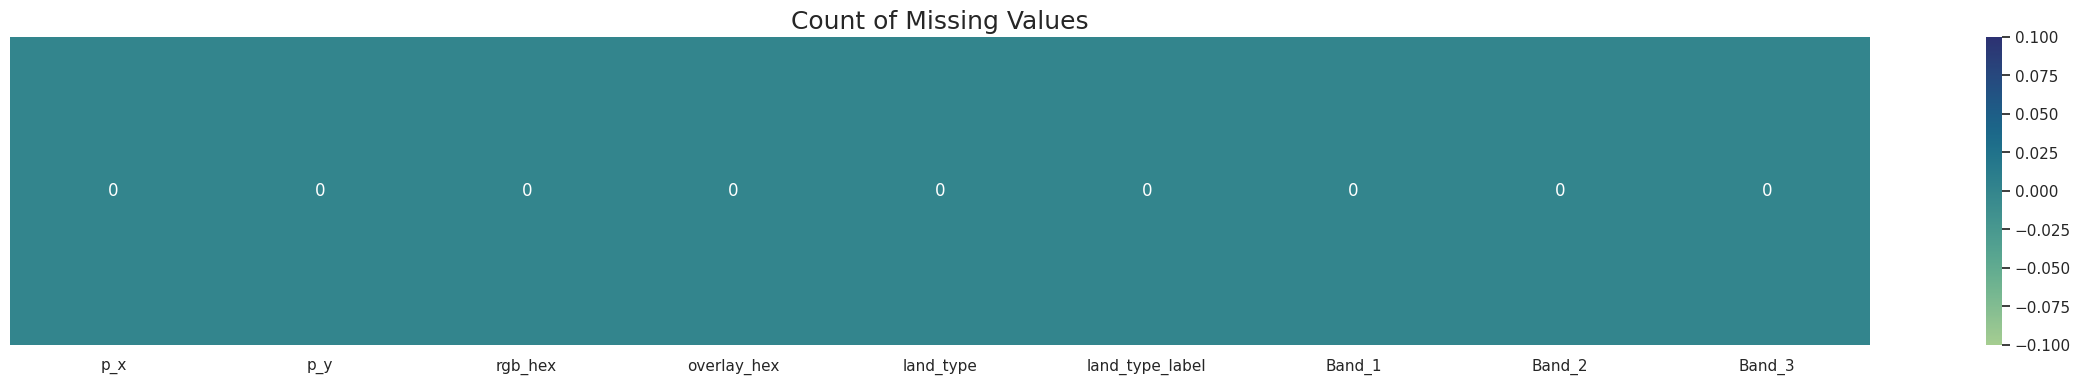

In [17]:
plt.figure(figsize=(30,4))
sns.heatmap((df.isna().sum()).to_frame(name='').T,cmap='crest', annot=True,
             fmt='0.0f').set_title('Count of Missing Values', fontsize=18)
plt.show()

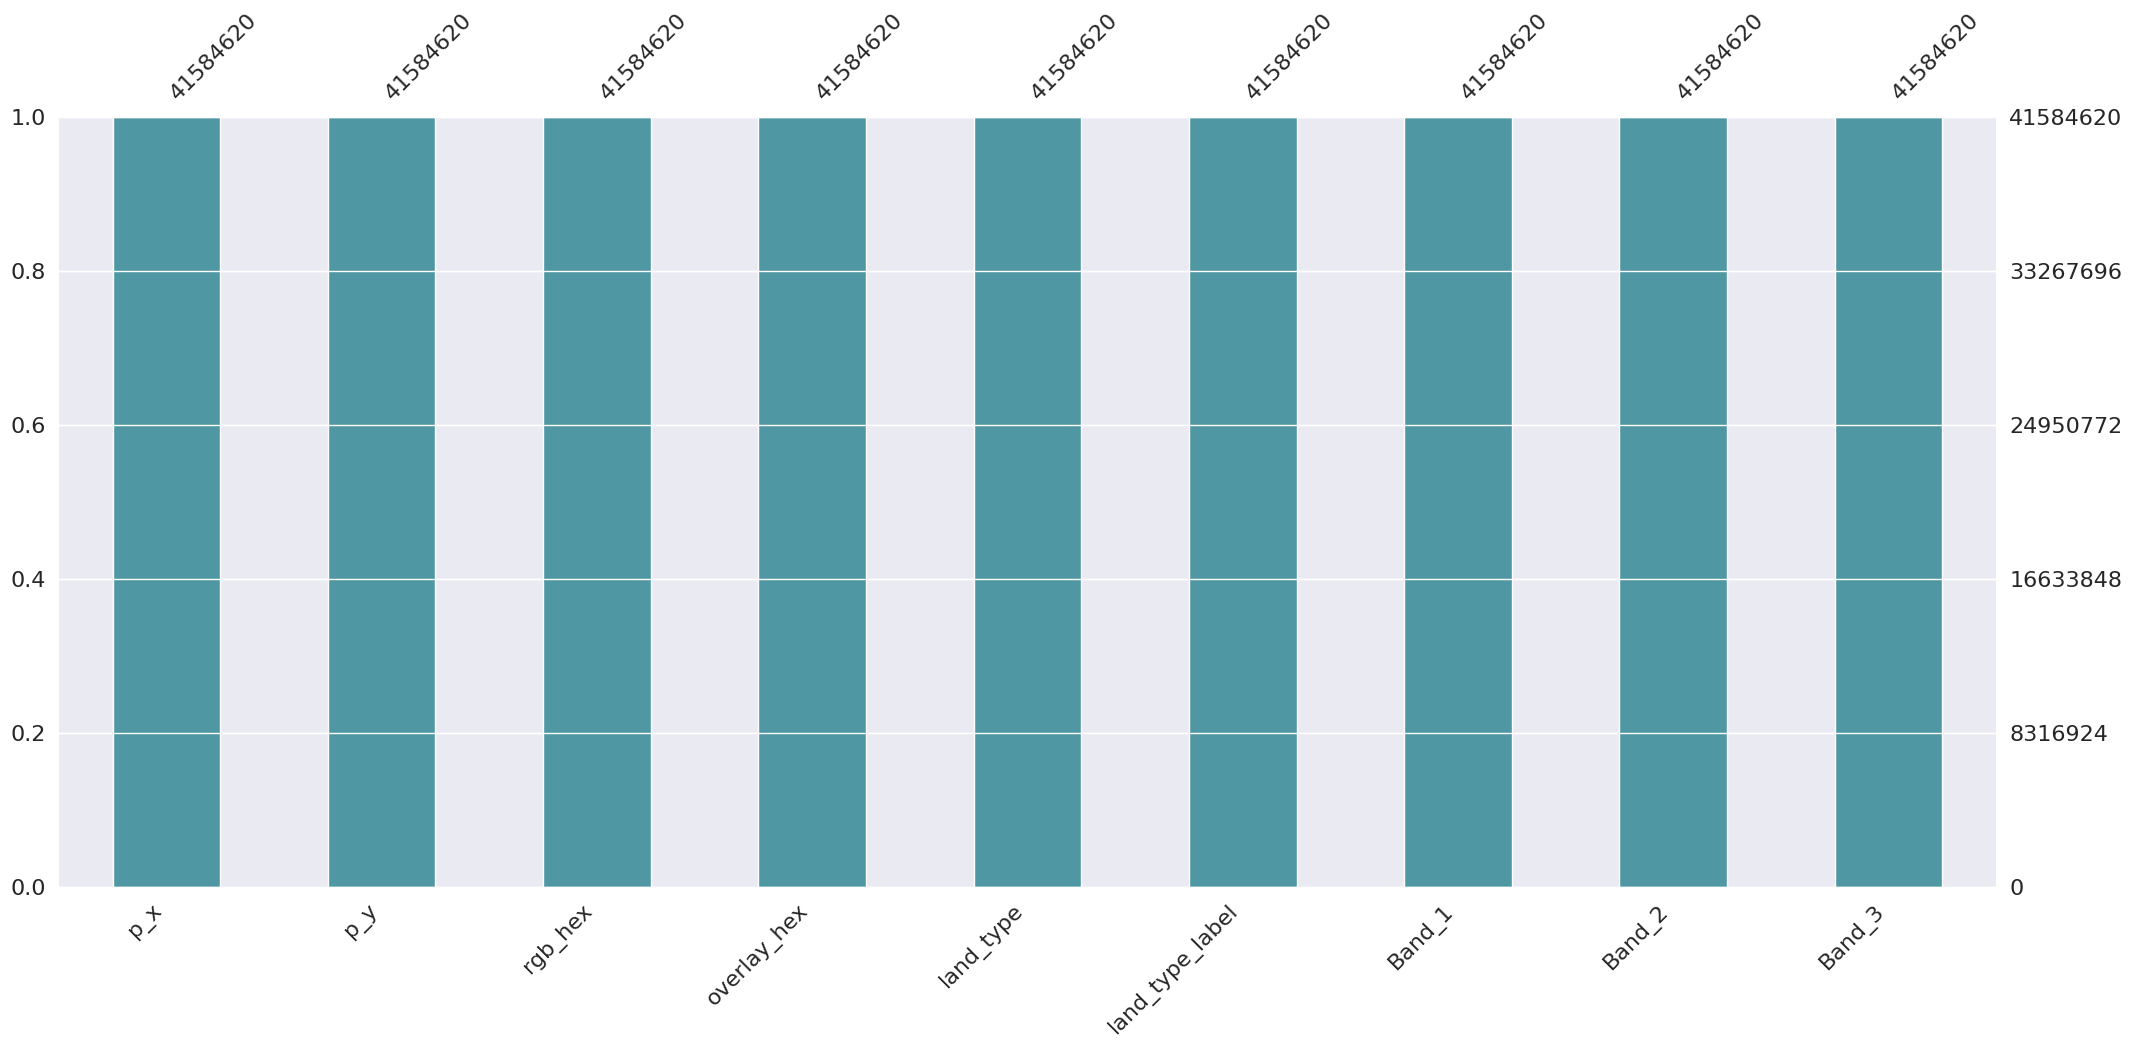

In [18]:
msno.bar(df, color='#5097A4')
plt.show()

In [19]:
df.describe()[1:].T.style.background_gradient(cmap='crest', axis=1)

,mean,std,min,25%,50%,75%,max
p_x,3860.706669,1706.923265,163.000000,2449.000000,3861.000000,5272.000000,7562.000000
p_y,4509.375124,2030.502341,141.000000,2823.000000,4509.000000,6196.000000,8878.000000
land_type,4.995713,0.132059,0.000000,5.000000,5.000000,5.000000,5.000000
Band_1,10416.215634,3024.201632,2.000000,8330.000000,10679.000000,11294.000000,61402.000000
Band_2,9983.454163,2755.724604,0.000000,8582.000000,9993.000000,10435.000000,61945.000000
Band_3,9177.641335,2554.501788,0.000000,8049.000000,9140.000000,9452.000000,61951.000000


In [20]:
# finding unique data
df.apply(lambda x: len(x.unique()))

p_x                  7400
p_y                  8738
rgb_hex            119052
overlay_hex             4
land_type               4
land_type_label         4
Band_1              52046
Band_2              51638
Band_3              52711
dtype: int64

In [21]:
unique = df.nunique().sort_values()
unique_values = df.apply(lambda x: x.unique())
pd.DataFrame({'Number of Unique Values': unique, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
Band_1,52046,"[8311.0, 8203.0, 8573.0, 8342.0, 8230.0, 8274...."
Band_2,51638,"[8706.0, 8680.0, 8998.0, 8762.0, 8778.0, 8702...."
Band_3,52711,"[8190.0, 8048.0, 8320.0, 8252.0, 8059.0, 8140...."
land_type,4,"[5, 1, 0, 4]"
land_type_label,4,"[Unknown, Water, Snow/Cloud, Bare Soil]"
overlay_hex,4,"[#808080, #1E90FF, #FFFFFF, #D2691E]"
p_x,7400,"[1920, 1921, 1922, 1923, 1924, 1925, 1926, 192..."
p_y,8738,"[141, 142, 143, 144, 145, 146, 147, 148, 149, ..."
rgb_hex,119052,"[#222321, #232522, #222421, #2D2C25, #302F29, ..."


In [22]:
# from ydata_profiling import ProfileReport

In [23]:
# profile = ProfileReport(df, 
#                         title='Dataset Report', 
#                         minimal=True, 
#                         progress_bar=False, 
#                         samples=None, 
#                         correlations=None, 
#                         interactions=None, 
#                         explorative=True, 
#                         notebook={'iframe': {'height': '600px'}}, 
#                         html={'style': {'primary_color': '#5097A4'}}, 
#                         missing_diagrams={'heatmap': False, 'dendrogram': False})

# Display the report as an iframe in the notebook
# profile.to_notebook_iframe()

In [24]:
corr = df.corr(numeric_only=True).T.style.background_gradient(cmap='crest', axis=1)
corr

,p_x,p_y,land_type,Band_1,Band_2,Band_3
p_x,1.000000,-0.014468,0.057157,0.122010,0.008175,-0.023219
p_y,-0.014468,1.000000,-0.024825,0.135615,0.124036,0.132432
land_type,0.057157,-0.024825,1.000000,-0.015632,-0.019811,0.016826
Band_1,0.122010,0.135615,-0.015632,1.000000,0.982786,0.947246
Band_2,0.008175,0.124036,-0.019811,0.982786,1.000000,0.983205
Band_3,-0.023219,0.132432,0.016826,0.947246,0.983205,1.000000


In [25]:
# plt.figure(figsize=(20, 12))
# sns.heatmap(
#     df.corr(numeric_only=True),
#     cmap='crest',
#     annot=True,
#     linewidths=0.6,
#     cbar=False)

# plt.xticks(rotation=60, size=10)
# plt.yticks(size=10)
# plt.title('Analysis of Correlations', size=20)
# plt.tight_layout()
# plt.show()

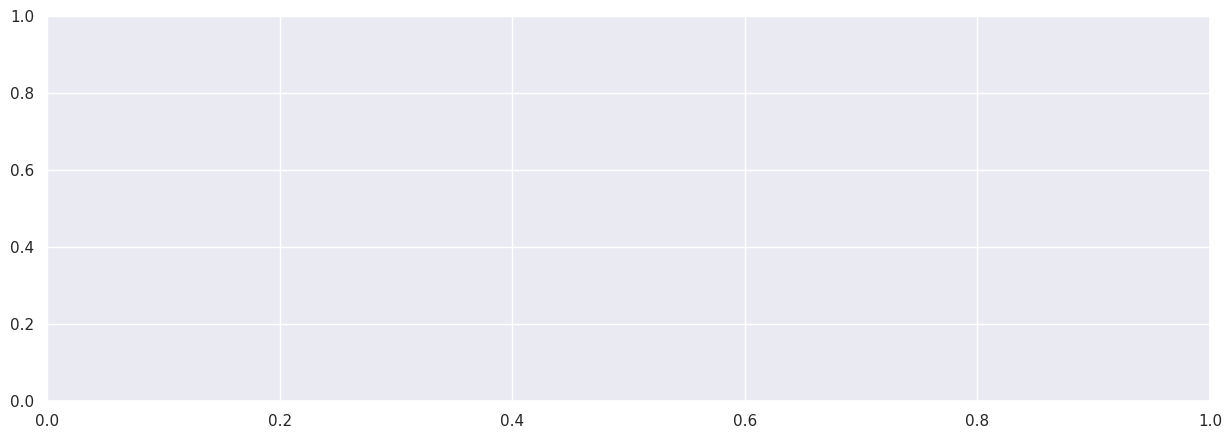

In [26]:
corr = df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(15, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
cut_off = 0.25
extreme_1 = 0.5
extreme_2 = 0.75
extreme_3 = 0.9
mask |= np.abs(corr) < cut_off
corr = corr[~mask]
remove_empty_rows_and_cols = True
if remove_empty_rows_and_cols:
    wanted_cols = np.flatnonzero(np.count_nonzero(~mask, axis=1))
    wanted_rows = np.flatnonzero(np.count_nonzero(~mask, axis=0))
    corr = corr.iloc[wanted_cols, wanted_rows]

annot = [[f"{val:.4f}"
          + ('' if abs(val) < extreme_1 else '\n*')
          + ('' if abs(val) < extreme_2 else '*')
          + ('' if abs(val) < extreme_3 else '*')
          for val in row] for row in corr.to_numpy()]
# heatmap = sns.heatmap(corr, vmin=-1, vmax=1, annot=annot, fmt='', cmap='crest')
# heatmap.set_title('Triangle Correlation Heatmap', fontdict={'fontsize': 12}, pad=16)
# plt.show()

In [27]:
corr

,Band_1,Band_2
Band_2,0.982786,NaN
Band_3,0.947246,0.983205


In [28]:
df1=df.copy()

In [29]:
# import plotly.graph_objects as go
# import plotly.express as px
# # ============================================================================
# # 1. LAND TYPE DISTRIBUTION - HORIZONTAL BAR + DONUT (FIXED)
# # ============================================================================

# # Get land type data with counts - CORRECT VERSION
# landtype_data = df1['land_type'].value_counts().reset_index()
# landtype_data.columns = ['Land_Type', 'Count']

# # Verify columns are correct
# print(f"\n🔍 Checking landtype_data columns:")
# print(f"   Columns: {landtype_data.columns.tolist()}")
# print(f"   Land_Type dtype: {landtype_data['Land_Type'].dtype}")
# print(f"   Count dtype: {landtype_data['Count'].dtype}")
# print(f"\n   First 3 rows:")
# print(landtype_data.head(3))

# # Beautiful earth/nature colors
# nature_colors = ['#2ecc71', '#27ae60', '#16a085', '#1abc9c', 
#                  '#3498db', '#2980b9', '#8e44ad', '#9b59b6']

# # Horizontal bar chart
# fig1 = go.Figure(go.Bar(
#     x=landtype_data['Count'][::-1],
#     y=landtype_data['Land_Type'].astype(str)[::-1],  # ✅ Convert to string
#     marker=dict(
#         color=nature_colors[:len(landtype_data)],
#         line=dict(color='white', width=2)
#     ),
#     text=[f'{x:,}' for x in landtype_data['Count'][::-1]],  # ✅ Use list comprehension
#     textposition='outside',
#     textfont=dict(size=11, color='#2c3e50', family='Arial'),
#     orientation='h',
#     hovertemplate='<b>%{y}</b><br>Pixels: %{x:,}<br><extra></extra>'
# ))

# fig1.update_layout(
#     title={
#         'text': '🌿 Land Type Distribution - Alpine Vegetation Classification 🏔️',
#         'x': 0.5,
#         'xanchor': 'center',
#         'font': {'size': 20, 'family': 'Arial Black', 'color': '#2c3e50'}
#     },
#     xaxis_title="Number of Pixels",
#     xaxis=dict(
#         titlefont=dict(size=14, color='#34495e'),
#         showgrid=True,
#         gridcolor='rgba(189, 195, 199, 0.2)'
#     ),
#     yaxis=dict(
#         titlefont=dict(size=14, color='#34495e'),
#         tickfont=dict(size=11, color='#2c3e50')
#     ),
#     template='plotly_white',
#     plot_bgcolor='rgba(248, 249, 250, 0.5)',
#     paper_bgcolor='white',
#     height=500,
#     width=1000,
#     margin=dict(l=200, r=80, t=100, b=80)
# )

# # fig1.show()

# # Statistics - FIXED
# print(f"\n{'='*70}")
# print(f"🌿 LAND TYPE STATISTICS")
# print(f"{'='*70}")
# for idx, row in landtype_data.iterrows():
#     pct = (row['Count'] / landtype_data['Count'].sum()) * 100
#     land_type_str = str(row['Land_Type'])  # ✅ Convert to string
#     print(f"{idx+1}. {land_type_str:<30s}: {row['Count']:>8,} pixels ({pct:>6.2f}%)")
# print(f"{'='*70}\n")

# # ============================================================================
# # REST OF THE CODE - WITH SAME FIX PATTERN
# # ============================================================================

# # 2. Donut Pie
# top_3_land = landtype_data.head(3)
# others_land = landtype_data.iloc[3:]['Count'].sum()

# pie_land_data = pd.concat([
#     top_3_land,
#     pd.DataFrame({'Land_Type': ['Other Types'], 'Count': [others_land]})
# ], ignore_index=True)

# fig2 = go.Figure(data=[go.Pie(
#     labels=pie_land_data['Land_Type'].astype(str),  # ✅ Convert to string
#     values=pie_land_data['Count'],
#     textinfo="label+percent",
#     textfont=dict(size=12, family='Arial', color='white'),
#     pull=[0.05, 0.05, 0.05, 0],
#     showlegend=False,
#     marker=dict(
#         colors=['#27ae60', '#16a085', '#3498db', '#95a5a6'],
#         line=dict(color='white', width=3)
#     ),
#     hovertemplate='<b>%{label}</b><br>Pixels: %{value:,}<br>%{percent}<br><extra></extra>',
#     hole=0.6
# )])

# top_3_pct = (top_3_land['Count'].sum() / pie_land_data['Count'].sum() * 100)

# fig2.update_layout(
#     title={
#         'text': '🌿 Dominant Land Types Distribution 🌿',
#         'x': 0.5,
#         'xanchor': 'center',
#         'font': {'size': 20, 'family': 'Arial Black', 'color': '#2c3e50'}
#     },
#     height=600,
#     width=700,
#     plot_bgcolor='white',
#     paper_bgcolor='white',
#     annotations=[
#         dict(
#             text=f"<b>{top_3_pct:.1f}%</b><br>of pixels are<br><b>Top 3</b><br>vegetation types",
#             x=0.5, y=0.5,
#             font=dict(size=13, family='Arial', color='#2c3e50'),
#             showarrow=False,
#             align='center'
#         )
#     ]
# )

# # fig2.show()

# # ============================================================================
# # 3. OVERLAY HEX (SAME AS BEFORE - NO CHANGES NEEDED)
# # ============================================================================

# overlay_data = df1['overlay_hex'].value_counts().reset_index()
# overlay_data.columns = ['Overlay_Color', 'Count']
# overlay_colors_display = [color[:7] for color in overlay_data['Overlay_Color']]

# fig3 = go.Figure(go.Bar(
#     x=overlay_data['Count'][::-1],
#     y=overlay_data['Overlay_Color'].astype(str)[::-1],  # ✅ Convert to string
#     marker=dict(
#         color=overlay_colors_display[::-1],
#         line=dict(color='white', width=2)
#     ),
#     text=[f'{x:,}' for x in overlay_data['Count'][::-1]],  # ✅ List comprehension
#     textposition='outside',
#     textfont=dict(size=11, color='#2c3e50'),
#     orientation='h',
#     hovertemplate='<b>%{y}</b><br>Count: %{x:,}<br><extra></extra>'
# ))

# fig3.update_layout(
#     title={
#         'text': '🎨 Overlay Color Distribution - Vegetation Classification 🎨',
#         'x': 0.5,
#         'xanchor': 'center',
#         'font': {'size': 20, 'family': 'Arial Black', 'color': '#2c3e50'}
#     },
#     xaxis_title="Number of Pixels",
#     template='plotly_white',
#     height=500,
#     width=900,
#     margin=dict(l=150, r=80, t=100, b=80)
# )

# # fig3.show()

# # RGB visualization (same fix)
# rgb_sample = df1['rgb_hex'].value_counts().head(20)

# fig_rgb = go.Figure(go.Bar(
#     x=rgb_sample.index,
#     y=rgb_sample.values,
#     marker=dict(
#         color=rgb_sample.index,
#         line=dict(color='white', width=1.5)
#     ),
#     text=[f'{val:,}' for val in rgb_sample.values],  # ✅ Fixed
#     textposition='outside',
#     textfont=dict(size=9, color='#2c3e50'),
#     hovertemplate='<b>%{x}</b><br>Pixels: %{y:,}<br><extra></extra>'
# ))

# fig_rgb.update_layout(
#     title={
#         'text': f'🌈 Top 20 RGB Colors (out of {df1["rgb_hex"].nunique():,} unique) 🌈',
#         'x': 0.5,
#         'xanchor': 'center',
#         'font': {'size': 18, 'family': 'Arial Black', 'color': '#2c3e50'}
#     },
#     xaxis_title="RGB Hex Code",
#     yaxis_title="Pixel Count",
#     template='plotly_white',
#     height=500,
#     width=1400,
#     xaxis=dict(tickangle=-45, tickfont=dict(size=9))
# )

# # fig_rgb.show()

# print(f"\n{'='*70}")
# print(f"🌈 RGB COLOR DIVERSITY")
# print(f"{'='*70}")
# print(f"Total unique RGB colors: {df1['rgb_hex'].nunique():,}")
# print(f"Most common color: {rgb_sample.index[0]} ({rgb_sample.values[0]:,} pixels)")
# print(f"Color diversity index: {df1['rgb_hex'].nunique() / len(df1):.4f}")
# print(f"{'='*70}\n")


🔍 Checking landtype_data columns:
   Columns: ['Land_Type', 'Count']
   Land_Type dtype: int64
   Count dtype: int64

   First 3 rows:
   Land_Type     Count
0          5  41540500
1          1     41000
2          0      2786

🌿 LAND TYPE STATISTICS
1. 5                             : 41,540,500 pixels ( 99.89%)
2. 1                             :   41,000 pixels (  0.10%)
3. 0                             :    2,786 pixels (  0.01%)
4. 4                             :      334 pixels (  0.00%)


🌈 RGB COLOR DIVERSITY
Total unique RGB colors: 119,052
Most common color: #2E2A26 (2,111,174 pixels)
Color diversity index: 0.0029



In [30]:
# # Color palette
# colors_palette = px.colors.qualitative.Set3
# nature_palette = ['#2ecc71', '#27ae60', '#16a085', '#1abc9c', 
#                   '#3498db', '#2980b9', '#8e44ad', '#9b59b6',
#                   '#e74c3c', '#c0392b']

# def create_interactive_sunflower_pie(data, column, title, top_n=None, use_actual_colors=False):
#     """
#     Create interactive sunflower pie chart for hyperspectral data
#     """
#     if top_n:
#         values_df = data[column].value_counts().head(top_n).reset_index()
#     else:
#         values_df = data[column].value_counts().reset_index()
    
#     # ✅ FIX: Set column names explicitly
#     values_df.columns = ['Category', 'Count']
#     values_df['Percentage'] = (values_df['Count'] / values_df['Count'].sum() * 100).round(2)
    
#     # Create sunflower pull effect
#     pull_values = []
#     for pct in values_df['Percentage']:
#         if pct < 5:
#             pull_values.append(0.15)
#         elif pct < 10:
#             pull_values.append(0.1)
#         elif pct < 20:
#             pull_values.append(0.05)
#         else:
#             pull_values.append(0)
    
#     # Use actual colors for overlay_hex
#     if use_actual_colors and column == 'overlay_hex':
#         chart_colors = [str(color)[:7] for color in values_df['Category']]
#     else:
#         chart_colors = nature_palette[:len(values_df)]
    
#     # Create figure
#     fig = go.Figure(data=[go.Pie(
#         labels=[str(cat) for cat in values_df['Category']],  # ✅ Convert to string
#         values=values_df['Count'],
#         hole=0.4,
#         pull=pull_values,
#         marker=dict(
#             colors=chart_colors,
#             line=dict(color='white', width=3)
#         ),
#         textposition='outside',
#         textfont=dict(size=13, family='Arial', color='#2c3e50'),
#         textinfo='label+percent',
#         hovertemplate='<b style="font-size:16px">%{label}</b><br><br>' +
#                      '📊 Pixels: <b>%{value:,}</b><br>' +
#                      '📈 Percentage: <b>%{percent}</b><br>' +
#                      '🛰️ Total Coverage: <b>%{value:,} pixels</b><br>' +
#                      '<extra></extra>',
#         insidetextorientation='horizontal'
#     )])
    
#     # Update layout
#     fig.update_layout(
#         title={
#             'text': f'🌻 {title} 🌻',
#             'x': 0.5,
#             'xanchor': 'center',
#             'font': {'size': 22, 'family': 'Arial Black', 'color': '#2c3e50'}
#         },
#         height=650,
#         width=850,
#         showlegend=True,
#         legend=dict(
#             orientation="v",
#             yanchor="middle",
#             y=0.5,
#             xanchor="left",
#             x=1.05,
#             font=dict(size=11, family='Arial'),
#             bgcolor='rgba(255,255,255,0.9)',
#             bordercolor='#34495e',
#             borderwidth=2
#         ),
#         plot_bgcolor='#f8f9fa',
#         paper_bgcolor='#ffffff',
#         annotations=[
#             dict(
#                 text=f'Total<br><b>{values_df["Count"].sum():,}</b><br>pixels',
#                 x=0.5, y=0.5,
#                 font=dict(size=16, family='Arial Black', color='#2c3e50'),
#                 showarrow=False
#             )
#         ]
#     )
    
#     return fig

# # ============================================================================
# # CREATE INTERACTIVE CHARTS
# # ============================================================================

# print("🌻 Creating interactive sunflower pie charts...\n")

# # Chart 1: Land Type Distribution
# fig1 = create_interactive_sunflower_pie(
#     df1, 'land_type', 
#     'Land Type Distribution - Alpine Vegetation Classification 🏔️'
# )
# fig1.show()

# # Chart 2: Overlay Hex Distribution (with actual colors!)
# fig2 = create_interactive_sunflower_pie(
#     df1, 'overlay_hex',
#     'Overlay Color Classification Codes 🎨',
#     use_actual_colors=True
# )
# fig2.show()

# # ============================================================================
# # PRINT STATISTICS (FIXED)
# # ============================================================================

# # Land Type Statistics
# landtype_stats = df1['land_type'].value_counts().reset_index()
# landtype_stats.columns = ['Land_Type', 'Count']  # ✅ Explicit column names

# print(f"\n{'='*70}")
# print(f"🌿 LAND TYPE BREAKDOWN")
# print(f"{'='*70}")
# for idx, row in landtype_stats.iterrows():
#     pct = (row['Count'] / len(df1)) * 100
#     land_type_str = str(row['Land_Type'])  # ✅ Convert to string
#     print(f"{idx+1}. {land_type_str:<35s}: {row['Count']:>8,} ({pct:>5.2f}%)")
# print(f"{'='*70}\n")

# # Overlay Hex Statistics
# overlay_stats = df1['overlay_hex'].value_counts().reset_index()
# overlay_stats.columns = ['Overlay_Hex', 'Count']  # ✅ Explicit column names

# print(f"{'='*70}")
# print(f"🎨 OVERLAY COLOR BREAKDOWN")
# print(f"{'='*70}")
# for idx, row in overlay_stats.iterrows():
#     pct = (row['Count'] / len(df1)) * 100
#     overlay_str = str(row['Overlay_Hex'])  # ✅ Convert to string
#     print(f"{idx+1}. {overlay_str:<15s}: {row['Count']:>8,} ({pct:>5.2f}%)")
# print(f"{'='*70}\n")

# # ============================================================================
# # BONUS: COMBINED SIDE-BY-SIDE VIEW
# # ============================================================================

# from plotly.subplots import make_subplots

# fig_combined = make_subplots(
#     rows=1, cols=2,
#     specs=[[{'type': 'pie'}, {'type': 'pie'}]],
#     subplot_titles=('🌿 Land Type Classification', '🎨 Overlay Color Codes')
# )

# # Land type pie
# pull_land = [0.1 if p < 10 else 0.05 if p < 20 else 0 
#              for p in (landtype_stats['Count'] / landtype_stats['Count'].sum() * 100)]

# fig_combined.add_trace(
#     go.Pie(
#         labels=[str(cat) for cat in landtype_stats['Land_Type']],  # ✅ Convert to string
#         values=landtype_stats['Count'],
#         hole=0.45,
#         pull=pull_land,
#         marker=dict(colors=nature_palette[:len(landtype_stats)],
#                    line=dict(color='white', width=3)),
#         textinfo='label+percent',
#         textfont=dict(size=11, color='white'),
#         hovertemplate='<b>%{label}</b><br>Pixels: %{value:,}<br>%{percent}<br><extra></extra>',
#         showlegend=False
#     ),
#     row=1, col=1
# )

# # Overlay hex pie
# pull_overlay = [0.1 if p < 10 else 0.05 if p < 20 else 0 
#                 for p in (overlay_stats['Count'] / overlay_stats['Count'].sum() * 100)]
# overlay_colors_actual = [str(color)[:7] for color in overlay_stats['Overlay_Hex']]

# fig_combined.add_trace(
#     go.Pie(
#         labels=[str(cat) for cat in overlay_stats['Overlay_Hex']],  # ✅ Convert to string
#         values=overlay_stats['Count'],
#         hole=0.45,
#         pull=pull_overlay,
#         marker=dict(colors=overlay_colors_actual,
#                    line=dict(color='white', width=3)),
#         textinfo='label+percent',
#         textfont=dict(size=11, color='white'),
#         hovertemplate='<b>%{label}</b><br>Pixels: %{value:,}<br>%{percent}<br><extra></extra>',
#         showlegend=False
#     ),
#     row=1, col=2
# )

# # Annotations
# fig_combined.add_annotation(
#     text=f'<b>{landtype_stats["Count"].sum():,}</b><br>Total<br>Pixels',
#     x=0.225, y=0.5,
#     xref='paper', yref='paper',
#     font=dict(size=14, color='#2c3e50'),
#     showarrow=False
# )

# fig_combined.add_annotation(
#     text=f'<b>{overlay_stats["Count"].sum():,}</b><br>Total<br>Pixels',
#     x=0.775, y=0.5,
#     xref='paper', yref='paper',
#     font=dict(size=14, color='#2c3e50'),
#     showarrow=False
# )

# fig_combined.update_layout(
#     title={
#         'text': '🛰️ Hyperspectral Classification Overview 🛰️<br><sub>EnMAP Satellite Data - Tyrol Alpine Region</sub>',
#         'x': 0.5,
#         'xanchor': 'center',
#         'font': {'size': 22, 'family': 'Arial Black', 'color': '#2c3e50'}
#     },
#     height=600,
#     width=1600,
#     plot_bgcolor='#f8f9fa',
#     paper_bgcolor='#ffffff'
# )

# # fig_combined.show()

In [31]:
# Check number of unique overlay colors
print(f"Number of unique overlay colors: {len(df1['overlay_hex'].unique())}")
print("\n" + "="*60)

# Count occurrences of each unique overlay_hex
print("\nOverlay color distribution:")
print(df1['overlay_hex'].value_counts().sort_index())
print("\n" + "="*60)

# Create mapping from overlay_hex to land_type (0 to n-1)
unique_overlays = df1['overlay_hex'].unique()
overlay_to_class = {overlay: idx for idx, overlay in enumerate(sorted(unique_overlays))}

# Display the mapping

print("\nMapping: overlay_hex → land_type (class)")
print("-" * 60)
for overlay, class_id in sorted(overlay_to_class.items()):
    count = len(df1[df1['overlay_hex'] == overlay])
    print(f"{overlay} → Class {class_id}  (count: {count:,})")

print("\n" + "="*60)

# Create new column 'land_type' based on the mapping
df1['land_type'] = df1['overlay_hex'].map(overlay_to_class)

# Verify the mapping worked correctly
print("\nVerification - land_type distribution:")
print(df1['land_type'].value_counts().sort_index())
print("\n" + "="*60)

# Display sample rows with both columns
print("\nSample data with overlay_hex and land_type:")
print(df1[['overlay_hex', 'land_type']].head(10))

Number of unique overlay colors: 4


Overlay color distribution:
overlay_hex
#1E90FF       41000
#808080    41540500
#D2691E         334
#FFFFFF        2786
Name: count, dtype: int64


Mapping: overlay_hex → land_type (class)
------------------------------------------------------------
#1E90FF → Class 0  (count: 41,000)
#808080 → Class 1  (count: 41,540,500)
#D2691E → Class 2  (count: 334)
#FFFFFF → Class 3  (count: 2,786)


Verification - land_type distribution:
land_type
0       41000
1    41540500
2         334
3        2786
Name: count, dtype: int64


Sample data with overlay_hex and land_type:
  overlay_hex  land_type
0     #808080          1
1     #808080          1
2     #808080          1
3     #808080          1
4     #808080          1
5     #808080          1
6     #808080          1
7     #808080          1
8     #808080          1
9     #808080          1



SUMMARY STATISTICS
Total samples: 41,584,620
Number of classes: 4

Class balance (land type):
  Class 0: 41,000 samples (0.10%)
  Class 1: 41,540,500 samples (99.89%)
  Class 2: 334 samples (0.00%)
  Class 3: 2,786 samples (0.01%)


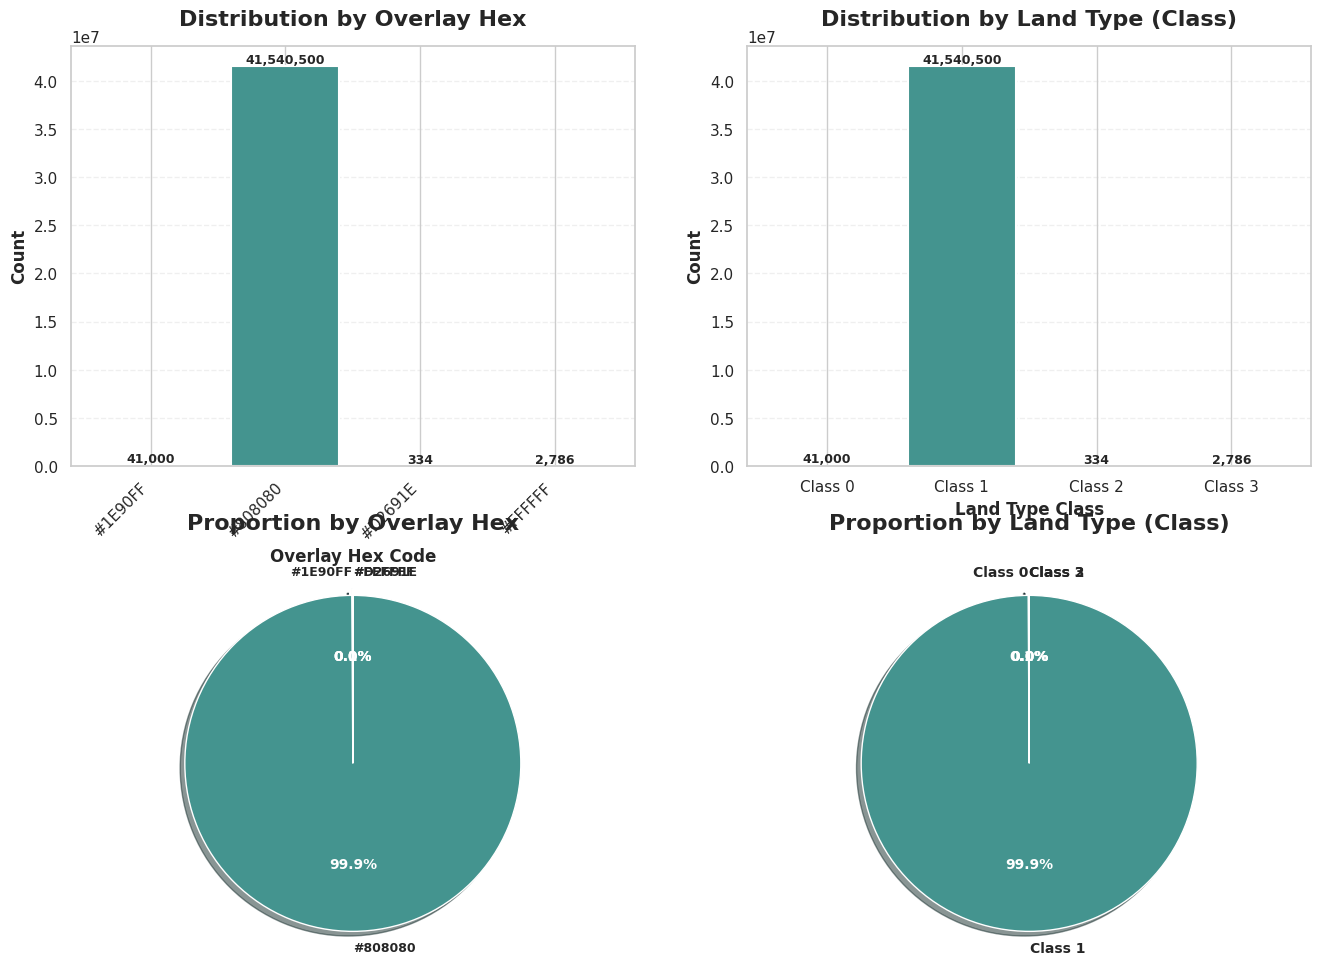

In [32]:
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 10
colors = sns.color_palette("crest", n_colors=len(df1['overlay_hex'].unique()))

# Create figure with 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data
overlay_counts = df1['overlay_hex'].value_counts().sort_index()
landtype_counts = df1['land_type'].value_counts().sort_index()

# ============================================
# TOP ROW: BAR PLOTS
# ============================================

# Plot 1: Bar chart for overlay_hex
axes[0, 0].bar(range(len(overlay_counts)), overlay_counts.values, 
               color=colors, edgecolor='white', linewidth=1.5)
axes[0, 0].set_title('Distribution by Overlay Hex', fontsize=16, fontweight='bold', pad=15)
axes[0, 0].set_xlabel('Overlay Hex Code', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(range(len(overlay_counts)))
axes[0, 0].set_xticklabels(overlay_counts.index, rotation=45, ha='right')
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (idx, val) in enumerate(overlay_counts.items()):
    axes[0, 0].text(i, val, f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Bar chart for land_type
axes[0, 1].bar(range(len(landtype_counts)), landtype_counts.values, 
               color=colors, edgecolor='white', linewidth=1.5)
axes[0, 1].set_title('Distribution by Land Type (Class)', fontsize=16, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('Land Type Class', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(len(landtype_counts)))
axes[0, 1].set_xticklabels([f'Class {i}' for i in landtype_counts.index], rotation=0)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (idx, val) in enumerate(landtype_counts.items()):
    axes[0, 1].text(i, val, f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Pie chart for overlay_hex
wedges, texts, autotexts = axes[1, 0].pie(
    overlay_counts.values, 
    labels=overlay_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.02] * len(overlay_counts),  # Slightly separate slices
    shadow=True,
    textprops={'fontsize': 9, 'fontweight': 'bold'}
)
axes[1, 0].set_title('Proportion by Overlay Hex', fontsize=16, fontweight='bold', pad=15)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)

# Plot 4: Pie chart for land_type
wedges2, texts2, autotexts2 = axes[1, 1].pie(
    landtype_counts.values,
    labels=[f'Class {i}' for i in landtype_counts.index],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.02] * len(landtype_counts),  # Slightly separate slices
    shadow=True,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
axes[1, 1].set_title('Proportion by Land Type (Class)', fontsize=16, fontweight='bold', pad=15)

for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontsize(10)

# fig.suptitle('Class Distribution Analysis', fontsize=20, fontweight='bold', y=0.98)

# # Adjust layout
# plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show()

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(f"Total samples: {len(df1):,}")
print(f"Number of classes: {len(df1['land_type'].unique())}")
print(f"\nClass balance (land type):")
for i in sorted(df1['land_type'].unique()):
    count = len(df1[df1['land_type'] == i])
    percentage = (count / len(df1)) * 100
    print(f"  Class {i}: {count:,} samples ({percentage:.2f}%)")
print("="*70)

In [33]:
# colors = ['#006466', '#065A60', '#0B525B', '#144552','#1B3A4B', '#212F45', '#272640', '#312244','#3E1F47', '#4D194D']
# fig = px.pie(df1, names='land_type', title='land_type',color_discrete_sequence=colors)
# fig.show()

In [34]:
# import cudf  # GPU DataFrame
# import cupy as cp
# import matplotlib.pyplot as plt

# # Load directly into GPU memory
# df_gpu = df1

# # Transfer to CPU only for plotting (minimal data)
# x = df_gpu['p_x'].to_numpy()
# y = df_gpu['p_y'].to_numpy()
# c = df_gpu['land_type'].to_numpy()

# plt.scatter(x, y, c=c, cmap='tab10', s=1, alpha=0.5)
# plt.show()

In [35]:
# import cudf
# import datashader as ds
# import datashader.transfer_functions as tf

# df_gpu = cudf.DataFrame({
#     'p_x': df['p_x'],
#     'p_y': df['p_y'],
#     'land_type': df['land_type'].astype('category')
# })

# canvas = ds.Canvas(plot_width=800, plot_height=400)
# agg = canvas.points(df_gpu, 'p_x', 'p_y', ds.count_cat('land_type'))
# img = tf.shade(agg, how='linear')
# img.to_pil().save('output.png')

In [36]:
# import cupy as cp
# import matplotlib.pyplot as plt

# # Process filtering/grouping on GPU
# x_gpu = cp.asarray(df['p_x'].values)
# y_gpu = cp.asarray(df['p_y'].values)
# c_gpu = cp.asarray(df['land_type'].values)

# # Filter on GPU (very fast)
# mask = c_gpu == 1
# x_class1 = cp.asnumpy(x_gpu[mask])
# y_class1 = cp.asnumpy(y_gpu[mask])

# plt.scatter(x_class1, y_class1, s=1, alpha=0.6)
# plt.show()

In [37]:
# import cudf
# import plotly.express as px

# df_gpu = cudf.read_parquet('data.parquet')

# # All heavy ops on GPU
# df_sampled = df_gpu.sample(n=500_000)  # GPU-accelerated sampling

# # Convert only sampled data to CPU for Plotly
# df_plot = df_sampled.to_pandas()

# fig = px.scatter(df_plot, x='p_x', y='p_y', 
#                  color='land_type', opacity=0.5,
#                  render_mode='webgl')  # WebGL = GPU rendering in browser
# fig.show()

In [38]:
# # Random sample - plot only 10% of data
# df_sample = df1.sample(frac=0.1, random_state=42)

# plt.scatter(df_sample['p_x'], df_sample['p_y'], 
#             c=df_sample['land_type'], cmap='tab10', s=1, alpha=0.5)

In [39]:
# import datashader as ds
# import datashader.transfer_functions as tf
# from datashader.mpl_ext import dsshow

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # Plot 1 - colored by land_type
# dsshow(df1, ds.Point('p_x', 'p_y'), 
#        ds.count_cat('land_type'), ax=axes[0])

# # Plot 2 - per class
# dsshow(df1, ds.Point('p_x', 'p_y'),
#        ds.count_cat('land_type'), ax=axes[1])

In [40]:
# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# plt.hexbin(df1['p_x'], df1['p_y'], C=df1['land_type'],
#            gridsize=100, cmap='tab10', reduce_C_function=np.median)
# plt.colorbar(label='Land Type')

# plt.subplot(1, 2, 2)
# plt.hexbin(df1['p_x'], df1['p_y'], gridsize=100, cmap='YlOrRd')
# plt.colorbar(label='Count')
# plt.tight_layout()
# plt.show()

In [41]:
# plt.scatter(df1['p_x'], df1['p_y'], 
#             c=df1['land_type'], cmap='tab10', 
#             s=1, alpha=0.5, rasterized=True)  # ← add this

# plt.savefig('plot.pdf', dpi=150)  # rasterized only helps when saving

In [42]:
# # Convert to float32 to halve memory usage
# x = df1['p_x'].to_numpy(dtype='float32')
# y = df1['p_y'].to_numpy(dtype='float32')
# c = df1['land_type'].to_numpy(dtype='int8')

# plt.scatter(x, y, c=c, cmap='tab10', s=1, alpha=0.5)

In [43]:
# import numpy as np
# import matplotlib.pyplot as plt

# MAX_POINTS = 500_000  # tune as needed

# def plot_large_spatial(df, max_points=MAX_POINTS):
#     # Downsample if needed
#     if len(df) > max_points:
#         df_plot = df.sample(n=max_points, random_state=42)
#         print(f"Downsampled from {len(df):,} to {max_points:,} points")
#     else:
#         df_plot = df

#     # Use float32 to reduce memory
#     x = df_plot['p_x'].to_numpy(dtype='float32')
#     y = df_plot['p_y'].to_numpy(dtype='float32')
#     c = df_plot['land_type'].to_numpy(dtype='int8')

#     fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#     # Plot 1
#     sc = axes[0].scatter(x, y, c=c, cmap='tab10', s=1, 
#                           alpha=0.5, rasterized=True)
#     plt.colorbar(sc, ax=axes[0], label='Land Type')
#     axes[0].set_title('Spatial Distribution of Land Types')

#     # Plot 2 - per class
#     for land_type in sorted(df_plot['land_type'].unique()):
#         mask = c == land_type
#         axes[1].scatter(x[mask], y[mask], label=f'Class {land_type}', 
#                         s=1, alpha=0.6, rasterized=True)
#     axes[1].legend(markerscale=5)
#     axes[1].set_title('Spatial Distribution by Class')

#     plt.tight_layout()
#     plt.savefig('spatial_plot.png', dpi=150, bbox_inches='tight')
#     plt.show()

# plot_large_spatial(df1)

In [44]:
# Check what band columns are actually found
print(f"Number of band_cols found: {len(band_cols)}")
print(f"First few: {band_cols[:5]}")
print(f"Last few: {band_cols[-5:]}")

# Check actual column names
print("\nAll columns sample:")
print(df.columns.tolist()[:20])

NameError: name 'band_cols' is not defined

In [ ]:
# Maybe columns are named differently — try these alternatives
band_cols = [col for col in df.columns if col.startswith('Band_')]   # Band_1, Band_2
band_cols = [col for col in df.columns if col.startswith('band_')]   # band_1, band_2  
band_cols = [col for col in df.columns if col.startswith('B')]       # B1, B2, B3
band_cols = [col for col in df.columns if 'band' in col.lower()]     # any case

print(f"Found {len(band_cols)} band columns")
print(band_cols[:5])

In [ ]:
band_cols = [col for col in df.columns if 'band' in col.lower()]  # adjust prefix as needed

# Dynamically use actual number of bands
n_bands = len(band_cols)
print(f"Plotting {n_bands} bands")

# plt.figure(figsize=(14, 6))

for land_type in sorted(df['land_type'].unique()):
    subset = df[df['land_type'] == land_type]
    mean_spectrum = subset[band_cols].mean()

    plt.plot(range(1, n_bands + 1), mean_spectrum.values,   # ← dynamic range
             label=f'Class {land_type}', linewidth=2, alpha=0.8)

# plt.xlabel('Band Number', fontsize=12, fontweight='bold')
# plt.ylabel('Mean Reflectance', fontsize=12, fontweight='bold')
# plt.title('Mean Spectral Signature per Land Type', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

In [ ]:
# DEBUG — run this first


In [ ]:
print("All columns:", df1.columns.tolist())
print("\nColumns with 'band' (any case):", [c for c in df1.columns if 'band' in c.lower()])
print("Columns with 'B':", [c for c in df1.columns if c.startswith('B')])

In [49]:
band_cols = [col for col in df1.columns if col.startswith('Band_')]
# n_bands = len(band_cols)
# print(f"Total bands: {n_bands}")  # 3

# # ============================================
# # Plot 1 — Mean Spectral Signature
# # ============================================
# plt.figure(figsize=(10, 5))

# for land_type in sorted(df1['land_type'].unique()):
#     subset = df1[df1['land_type'] == land_type]
#     mean_spectrum = subset[band_cols].mean()
#     plt.plot(range(1, n_bands + 1), mean_spectrum.values,
#              label=f'Class {land_type}', linewidth=2, alpha=0.8, marker='o')

# plt.xticks(range(1, n_bands + 1), band_cols, rotation=0)
# plt.xlabel('Band', fontsize=12, fontweight='bold')
# plt.ylabel('Mean Reflectance', fontsize=12, fontweight='bold')
# plt.title('Mean Spectral Signature per Land Type', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# # ============================================
# # Plot 2 — Correlation Heatmap (all 3 bands)
# # ============================================
# # With only 3 bands, use ALL of them (no sampling needed)
# corr = df1[band_cols].corr()
# print(f"Correlation matrix shape: {corr.shape}")

# cut_off   = 0.25
# extreme_1 = 0.5
# extreme_2 = 0.75
# extreme_3 = 0.9

# corr_np = corr.to_numpy()

# # No upper-triangle masking for 3x3 — show full matrix
# def make_annot(val):
#     if np.isnan(val): return ''
#     stars = ''
#     if abs(val) >= extreme_1: stars += '\n*'
#     if abs(val) >= extreme_2: stars += '*'
#     if abs(val) >= extreme_3: stars += '*'
#     return f"{val:.4f}{stars}"

# annot = np.vectorize(make_annot)(corr_np)

# f, ax = plt.subplots(figsize=(7, 5))
# sns.heatmap(corr, vmin=-1, vmax=1,
#             annot=annot, fmt='',
#             cmap='crest',
#             cbar_kws={'label': 'Correlation Coefficient'},
#             linewidths=0.5, linecolor='white')

# ax.set_title('Band Correlation Heatmap\n(All 3 Bands)',
#              fontdict={'fontsize': 13, 'fontweight': 'bold'}, pad=12)

# legend_text = "* = |r| ≥ 0.5\n** = |r| ≥ 0.75\n*** = |r| ≥ 0.9"
# plt.text(1.15, 0.5, legend_text, transform=ax.transAxes, fontsize=10,
#          verticalalignment='center',
#          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# plt.xticks(rotation=45, ha='right')
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

# # ============================================
# # Correlation Statistics
# # ============================================
# print("\n" + "="*50)
# print("CORRELATION STATISTICS (3 Bands)")
# print("="*50)

# corr_values = corr.values[np.triu_indices_from(corr.values, k=1)]
# print(f"Total pairs:               {len(corr_values)}")   # only 3 pairs for 3 bands
# print(f"Mean correlation:          {np.mean(corr_values):.4f}")
# print(f"Median correlation:        {np.median(corr_values):.4f}")
# print(f"Max correlation:           {np.max(corr_values):.4f}")
# print(f"Min correlation:           {np.min(corr_values):.4f}")
# print(f"\nHigh        (|r| ≥ 0.90): {np.sum(np.abs(corr_values) >= 0.9)}")
# print(f"Medium  (0.75 ≤ |r| < 0.90): {np.sum((np.abs(corr_values) >= 0.75) & (np.abs(corr_values) < 0.9))}")
# print(f"Moderate(0.50 ≤ |r| < 0.75): {np.sum((np.abs(corr_values) >= 0.5)  & (np.abs(corr_values) < 0.75))}")
# print(f"Weak    (0.25 ≤ |r| < 0.50): {np.sum((np.abs(corr_values) >= 0.25) & (np.abs(corr_values) < 0.5))}")
# print(f"Very weak      (|r| < 0.25): {np.sum(np.abs(corr_values) < 0.25)}")
# print("="*50)
# print("\nNote: Only 3 bands (RGB). Dimensionality reduction")
# print("may have limited benefit with so few features.")

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# # Plot 1: Histogram of correlations
# axes[0].hist(corr_values, bins=50, color='steelblue', 
#             edgecolor='white', alpha=0.8)
# axes[0].axvline(x=0.5, color='orange', linestyle='--', 
#                linewidth=2, label='|r| = 0.5')
# axes[0].axvline(x=0.75, color='red', linestyle='--', 
#                linewidth=2, label='|r| = 0.75')
# axes[0].axvline(x=0.9, color='darkred', linestyle='--', 
#                linewidth=2, label='|r| = 0.9')
# axes[0].set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
# axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
# axes[0].set_title('Distribution of Pairwise Correlations', 
#                  fontsize=14, fontweight='bold')
# axes[0].legend()
# axes[0].grid(alpha=0.3)

# # Plot 2: Box plot
# bp = axes[1].boxplot([corr_values], 
#                      vert=True, 
#                      patch_artist=True,
#                      labels=['All Correlations'])
# bp['boxes'][0].set_facecolor('lightblue')
# bp['boxes'][0].set_edgecolor('darkblue')
# bp['medians'][0].set_color('red')
# bp['medians'][0].set_linewidth(2)

# axes[1].axhline(y=0.5, color='orange', linestyle='--', 
#                linewidth=2, alpha=0.7, label='Moderate')
# axes[1].axhline(y=0.75, color='red', linestyle='--', 
#                linewidth=2, alpha=0.7, label='Strong')
# axes[1].axhline(y=0.9, color='darkred', linestyle='--', 
#                linewidth=2, alpha=0.7, label='Very Strong')

# axes[1].set_ylabel('Correlation Coefficient', fontsize=12, fontweight='bold')
# axes[1].set_title('Box Plot of Correlations', fontsize=14, fontweight='bold')
# axes[1].legend()
# axes[1].grid(alpha=0.3, axis='y')

# plt.tight_layout()
# plt.show()

In [48]:
corr_full = df1[band_cols].corr()

# f, ax = plt.subplots(figsize=(20, 18))

# sns.heatmap(corr_full, 
#            vmin=-1, 
#            vmax=1, 
#            cmap='crest',
#            cbar_kws={'label': 'Correlation'},
#            xticklabels=20,
#            yticklabels=20,
#            square=True)

# plt.title('Full Correlation Heatmap (All 218 Bands)', 
#          fontsize=16, fontweight='bold', pad=20)
# plt.xlabel('Band Number', fontsize=12, fontweight='bold')
# plt.ylabel('Band Number', fontsize=12, fontweight='bold')
# plt.tight_layout()
# plt.show()

print("✅ Done!")

NameError: name 'band_cols' is not defined

In [ ]:
# RGB Natural Color Map
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Convert hex to RGB for visualization
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

# Create RGB array for natural color image
rgb_colors = df1['rgb_hex'].apply(hex_to_rgb)
rgb_array = np.array(rgb_colors.tolist()) / 255.0  # Normalize to 0-1

# Left: Natural color (RGB)
# axes[0].scatter(df1['p_x'], df1['p_y'], 
#                c=rgb_array, 
#                s=2, 
#                alpha=0.9)
# axes[0].set_title('Natural Color (RGB) Image', 
#                   fontsize=16, fontweight='bold')
# axes[0].set_xlabel('X Coordinate', fontsize=12, fontweight='bold')
# axes[0].set_ylabel('Y Coordinate', fontsize=12, fontweight='bold')
# axes[0].set_aspect('equal')

# # Right: Land type classification
# scatter = axes[1].scatter(df1['p_x'], df1['p_y'], 
#                          c=df1['land_type'],
#                          cmap='tab10',
#                          s=2,
#                          alpha=0.9)
# axes[1].set_title('Land Type Classification', 
#                   fontsize=16, fontweight='bold')
# axes[1].set_xlabel('X Coordinate', fontsize=12, fontweight='bold')
# axes[1].set_ylabel('Y Coordinate', fontsize=12, fontweight='bold')
# axes[1].set_aspect('equal')

# # Add colorbar
# cbar = plt.colorbar(scatter, ax=axes[1], 
#                    ticks=sorted(df1['land_type'].unique()))
# cbar.set_label('Land Type Class', fontsize=12, fontweight='bold')

# plt.suptitle('Hyperspectral Image - Tyrol, Austria', 
#             fontsize=20, fontweight='bold', y=0.98)
# plt.tight_layout()
# plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7d1460942200> (for post_execute):


KeyboardInterrupt: 

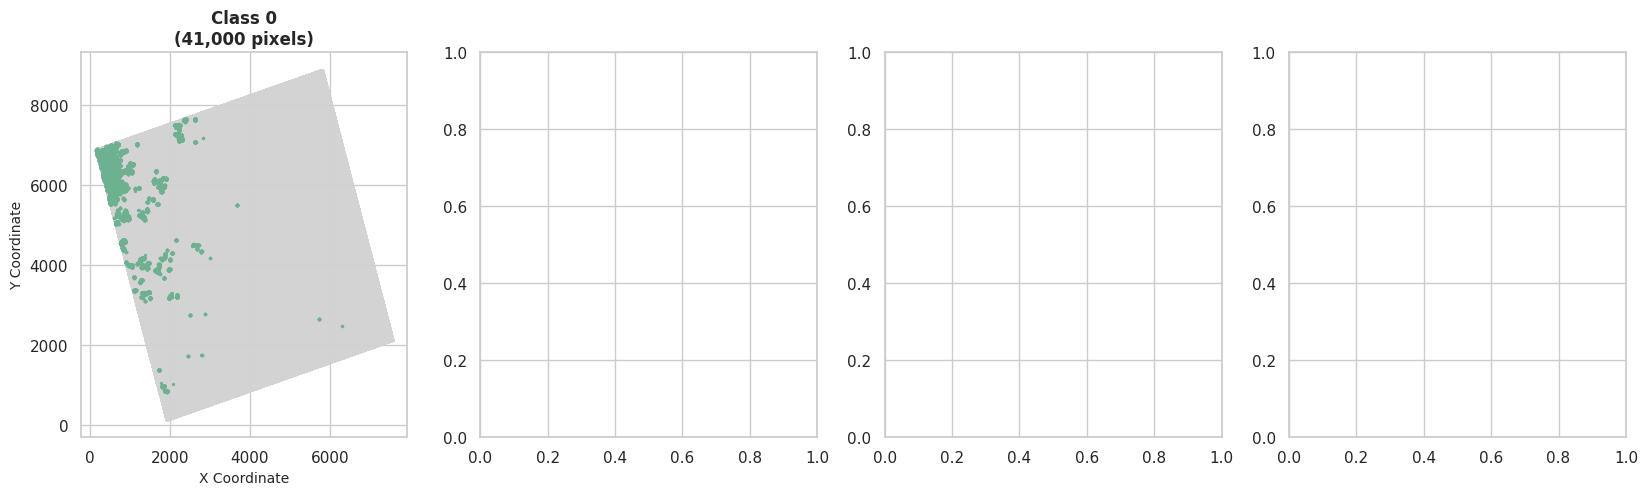

In [45]:
# Separate Map for Each Class
n_classes = len(df1['land_type'].unique())
n_cols = 4
n_rows = (n_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

colors = sns.color_palette("crest", n_colors=n_classes)

for idx, land_type in enumerate(sorted(df1['land_type'].unique())):
    # Get subset for this class
    subset = df1[df1['land_type'] == land_type]
    
    # Plot all pixels in gray
    axes[idx].scatter(df1['p_x'], df1['p_y'], 
                     c='lightgray', s=1, alpha=0.3)
    
    # Highlight current class
    axes[idx].scatter(subset['p_x'], subset['p_y'], 
                     c=[colors[idx]], s=2, alpha=0.9)
    
    axes[idx].set_title(f'Class {land_type}\n({len(subset):,} pixels)', 
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('X Coordinate', fontsize=10)
    axes[idx].set_ylabel('Y Coordinate', fontsize=10)
    axes[idx].set_aspect('equal')

# Hide extra subplots
for idx in range(n_classes, len(axes)):
    axes[idx].axis('off')

# plt.suptitle('Individual Class Distribution Maps', 
#             fontsize=18, fontweight='bold', y=1.00)
# plt.tight_layout()
# plt.show()

In [ ]:
# # ============================================
# # METHOD 4: Professional Map with Custom Legend
# # ============================================
# from matplotlib.patches import Patch

# fig, ax = plt.subplots(figsize=(18, 12))

# # Define custom colors for each class
# class_colors = sns.color_palette("Spectral", n_colors=n_classes)

# # Plot each class with its color
# for idx, land_type in enumerate(sorted(df1['land_type'].unique())):
#     subset = df1[df1['land_type'] == land_type]
#     ax.scatter(subset['p_x'], subset['p_y'],
#               c=[class_colors[idx]],
#               s=3,
#               alpha=0.8,
#               label=f'Class {land_type} ({len(subset):,} px)',
#               edgecolors='none')

# # Customize plot
# ax.set_title('Hyperspectral Land Cover Classification Map\nTyrol Alpine Region, Austria',
#             fontsize=20, fontweight='bold', pad=20)
# ax.set_xlabel('Easting (X Coordinate in meters)', fontsize=14, fontweight='bold')
# ax.set_ylabel('Northing (Y Coordinate in meters)', fontsize=14, fontweight='bold')
# ax.set_aspect('equal')
# ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# # Add legend
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),
#          fontsize=11, framealpha=0.9,
#          title='Land Type Classes', title_fontsize=13)

# # Add text annotation
# textstr = f'Total Pixels: {len(df1):,}\nSpectral Bands: 218\nSpatial Coverage: Alpine Region'
# props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
# ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
#        verticalalignment='top', bbox=props)

# plt.tight_layout()
# plt.show()

In [ ]:
# # ============================================
# # METHOD 5: 3D Visualization (Optional)
# # ============================================
# from mpl_toolkits.mplot3d import Axes3D

# # Sample data for faster plotting (optional)
# sample_size = 50000
# df_sample = df1.sample(n=min(sample_size, len(df1)), random_state=42)

# fig = plt.figure(figsize=(16, 12))
# ax = fig.add_subplot(111, projection='3d')

# # Use first principal component as Z-axis
# # (or you can use elevation if available)
# scatter = ax.scatter(df_sample['p_x'], 
#                     df_sample['p_y'],
#                     df_sample['Band_1'],  # or use PCA component
#                     c=df_sample['land_type'],
#                     cmap='tab10',
#                     s=5,
#                     alpha=0.6)

# ax.set_xlabel('X Coordinate', fontsize=12, fontweight='bold')
# ax.set_ylabel('Y Coordinate', fontsize=12, fontweight='bold')
# ax.set_zlabel('Band_1 Reflectance', fontsize=12, fontweight='bold')
# ax.set_title('3D Spatial-Spectral Visualization', 
#             fontsize=16, fontweight='bold', pad=20)

# plt.colorbar(scatter, label='Land Type', shrink=0.5)
# plt.tight_layout()
# plt.show()

In [ ]:
print("="*60)
print("SPATIAL MAP STATISTICS")
print("="*60)
print(f"X Coordinate Range: {df1['p_x'].min():.0f} to {df1['p_x'].max():.0f} meters")
print(f"Y Coordinate Range: {df1['p_y'].min():.0f} to {df1['p_y'].max():.0f} meters")
print(f"Map Width: {df1['p_x'].max() - df1['p_x'].min():.0f} meters")
print(f"Map Height: {df1['p_y'].max() - df1['p_y'].min():.0f} meters")
print(f"Total Area: ~{(df1['p_x'].max() - df1['p_x'].min()) * (df1['p_y'].max() - df1['p_y'].min()) / 1e6:.2f} km²")
print(f"Total Pixels: {len(df1):,}")
print("="*60)

In [46]:
# ============================================
# Calculate wavelength for each band
# ============================================
import numpy as np
import pandas as pd

# Spectral range
wavelength_min = 420  # nm
wavelength_max = 2450  # nm
n_bands = 218

# Create wavelength array
wavelengths = np.linspace(wavelength_min, wavelength_max, n_bands)

# Create mapping
band_wavelength_map = {f'Band_{i+1}': wavelengths[i] for i in range(n_bands)}

# Display first 10 and some key bands
print("="*70)
print("BAND TO WAVELENGTH MAPPING")
print("="*70)
print(f"{'Band':<12} {'Wavelength (nm)':<18} {'Region'}")
print("-"*70)

for i in [0, 19, 39, 59, 99, 139, 179, 217]:
    band_name = f'Band_{i+1}'
    wl = wavelengths[i]
    
    # Determine region
    if wl < 450:
        region = "Blue (Visible)"
    elif wl < 520:
        region = "Cyan-Green (Visible)"
    elif wl < 600:
        region = "Green (Visible)"
    elif wl < 650:
        region = "Yellow-Orange (Visible)"
    elif wl < 700:
        region = "Red (Visible)"
    elif wl < 1000:
        region = "Near Infrared (NIR)"
    elif wl < 1400:
        region = "NIR / SWIR transition"
    elif wl < 1900:
        region = "Short-Wave Infrared 1 (SWIR-1)"
    else:
        region = "Short-Wave Infrared 2 (SWIR-2)"
    
    print(f"{band_name:<12} {wl:>6.1f} nm        {region}")

print("="*70)

BAND TO WAVELENGTH MAPPING
Band         Wavelength (nm)    Region
----------------------------------------------------------------------
Band_1        420.0 nm        Blue (Visible)
Band_20       597.7 nm        Green (Visible)
Band_40       784.8 nm        Near Infrared (NIR)
Band_60       971.9 nm        Near Infrared (NIR)
Band_100     1346.1 nm        NIR / SWIR transition
Band_140     1720.3 nm        Short-Wave Infrared 1 (SWIR-1)
Band_180     2094.5 nm        Short-Wave Infrared 2 (SWIR-2)
Band_218     2450.0 nm        Short-Wave Infrared 2 (SWIR-2)


In [ ]:
# PCA with Density Contours
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde

# Prepare data
X = df1[band_cols].values
y = df1['land_type'].values

# Standardize and apply PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create plot
fig, ax = plt.subplots(figsize=(16, 12))

colors = sns.color_palette("Set2", n_colors=len(np.unique(y)))

for idx, land_type in enumerate(sorted(np.unique(y))):
    mask = y == land_type
    x_class = X_pca[mask, 0]
    y_class = X_pca[mask, 1]
    
    # Scatter plot
    ax.scatter(x_class, y_class, 
              c=[colors[idx]], s=20, alpha=0.4,
              label=f'Class {land_type}', edgecolors='none')
    
    # Density contours
    if len(x_class) > 50:  # Need enough points for KDE
        try:
            xy = np.vstack([x_class, y_class])
            kde = gaussian_kde(xy)
            
            # Create grid
            x_min, x_max = x_class.min(), x_class.max()
            y_min, y_max = y_class.min(), y_class.max()
            xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
            positions = np.vstack([xx.ravel(), yy.ravel()])
            density = kde(positions).reshape(xx.shape)
            
            # Plot contours
            ax.contour(xx, yy, density, colors=[colors[idx]], 
                      levels=5, linewidths=2, alpha=0.8)
        except:
            pass

# ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', 
#              fontsize=14, fontweight='bold')
# ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', 
#              fontsize=14, fontweight='bold')
# ax.set_title('PCA Projection with Density Contours', 
#             fontsize=16, fontweight='bold', pad=20)
# ax.legend(fontsize=11, framealpha=0.9)
# ax.grid(alpha=0.3, linestyle='--')

# plt.tight_layout()
# plt.show()

In [ ]:
# ============================================
# Plot 5: Parallel Coordinates Plot
# ============================================
from pandas.plotting import parallel_coordinates

# Select representative bands
selected_bands = [f'Band_{i}' for i in [20, 50, 80, 110, 140, 170, 200]]

# Sample data for readability
sample_size = 5000
df_sample = df1.sample(n=min(sample_size, len(df1)), random_state=42)

# Prepare data
plot_data = df_sample[selected_bands + ['land_type']].copy()
plot_data['land_type'] = plot_data['land_type'].apply(lambda x: f'Class {x}')

# Create plot
# fig, ax = plt.subplots(figsize=(18, 10))

# parallel_coordinates(plot_data, 'land_type', 
#                     color=sns.color_palette("husl", len(df1['land_type'].unique())),
#                     alpha=0.3, ax=ax, linewidth=1.5)

# ax.set_title('Parallel Coordinates: Spectral Patterns Across Bands', 
#             fontsize=16, fontweight='bold', pad=20)
# ax.set_xlabel('Spectral Bands', fontsize=14, fontweight='bold')
# ax.set_ylabel('Normalized Reflectance', fontsize=14, fontweight='bold')
# ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
# ax.grid(alpha=0.3, axis='y')

# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()

In [ ]:
# Radar Chart for Mean Reflectance
from math import pi

# Select bands for radar
radar_bands = [f'Band_{i}' for i in [20, 50, 80, 110, 140, 170, 200]]
categories = ['Blue', 'Green', 'Red', 'NIR-1', 'NIR-2', 'SWIR-1', 'SWIR-2']

# Calculate mean for each class
fig, axes = plt.subplots(2, 4, figsize=(20, 10), 
                         subplot_kw=dict(projection='polar'))
axes = axes.flatten()

colors = sns.color_palette("husl", len(df1['land_type'].unique()))

for idx, land_type in enumerate(sorted(df1['land_type'].unique())):
    ax = axes[idx]
    
    # Get mean values
    subset = df1[df1['land_type'] == land_type]
    values = [subset[band].mean() for band in radar_bands]
    values += values[:1]  # Complete the circle
    
    # Angles for each axis
    angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
    angles += angles[:1]
    
    # Plot
    ax.plot(angles, values, 'o-', linewidth=2, 
           color=colors[idx], label=f'Class {land_type}')
    ax.fill(angles, values, alpha=0.25, color=colors[idx])
    
    # Styling
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, max([subset[band].mean() for band in radar_bands]) * 1.2)
    ax.set_title(f'Class {land_type}\n({len(subset):,} pixels)', 
                fontsize=12, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3)

# Hide extra subplot
axes[-1].axis('off')

plt.suptitle('Radar Charts: Mean Spectral Signatures by Land Type', 
            fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
# Box Plot Matrix for Key Bands
key_bands_box = [f'Band_{i}' for i in [20, 60, 100, 150, 200]]
band_labels = ['Blue', 'Red', 'NIR', 'SWIR-1', 'SWIR-2']

fig, axes = plt.subplots(1, len(key_bands_box), figsize=(20, 6))

colors = sns.color_palette("Set3", n_colors=len(df1['land_type'].unique()))

for idx, (band, label) in enumerate(zip(key_bands_box, band_labels)):
    ax = axes[idx]
    
    # Prepare data for box plot
    data_to_plot = [df1[df1['land_type'] == lt][band].values 
                   for lt in sorted(df1['land_type'].unique())]
    
    bp = ax.boxplot(data_to_plot, 
                    labels=[f'C{i}' for i in sorted(df1['land_type'].unique())],
                    patch_artist=True,
                    showfliers=False)  # Hide outliers for clarity
    
    # Color boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'{label}\n({band})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Land Type', fontsize=10, fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Reflectance', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Box Plot Comparison Across Spectral Regions', 
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# Mean Spectral Signatures with Confidence Bands
band_cols = [col for col in df1.columns if col.startswith('Band_')]
band_numbers = range(1, len(band_cols) + 1)

fig, ax = plt.subplots(figsize=(18, 8))

# Color palette
colors = sns.color_palette("husl", n_colors=len(df1['land_type'].unique()))

for idx, land_type in enumerate(sorted(df1['land_type'].unique())):
    subset = df1[df1['land_type'] == land_type][band_cols]
    
    # Calculate mean and std
    mean_spectrum = subset.mean()
    std_spectrum = subset.std()
    
    # Confidence interval (95%)
    n = len(subset)
    ci = 1.96 * std_spectrum / np.sqrt(n)
    
    # Plot mean line
    ax.plot(band_numbers, mean_spectrum.values, 
           color=colors[idx], linewidth=2.5, 
           label=f'Class {land_type} (n={n:,})', alpha=0.9)
    
    # Plot confidence band
    ax.fill_between(band_numbers, 
                    mean_spectrum.values - ci.values,
                    mean_spectrum.values + ci.values,
                    color=colors[idx], alpha=0.15)

ax.set_xlabel('Band Number (420-2450 nm)', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Reflectance', fontsize=14, fontweight='bold')
ax.set_title('Spectral Signatures by Land Type\nwith 95% Confidence Intervals', 
            fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3, linestyle='--')

# Add wavelength regions
ax.axvspan(0, 75, alpha=0.1, color='blue', label='Visible')
ax.axvspan(75, 150, alpha=0.1, color='orange', label='NIR')
ax.axvspan(150, 218, alpha=0.1, color='red', label='SWIR')

plt.tight_layout()
plt.show()

In [ ]:
# Ridge Plot for Selected Bands
from scipy.stats import gaussian_kde

# Select a few representative bands
selected_bands_indices = [10, 50, 100, 150, 200]  # VIS, NIR, SWIR regions
selected_band_names = [f'Band_{i}' for i in selected_bands_indices]

fig, axes = plt.subplots(len(df1['land_type'].unique()), 1, 
                         figsize=(16, 12), sharex=True)

colors = sns.color_palette("Spectral", n_colors=len(selected_band_names))

for idx, land_type in enumerate(sorted(df1['land_type'].unique())):
    ax = axes[idx]
    subset = df1[df1['land_type'] == land_type]
    
    # Plot density for each selected band
    for band_idx, band_name in enumerate(selected_band_names):
        data = subset[band_name].values
        
        # Calculate KDE
        kde = gaussian_kde(data)
        x_range = np.linspace(data.min(), data.max(), 200)
        density = kde(x_range)
        
        # Normalize for visibility
        density = density / density.max() * 0.8
        
        ax.fill_between(x_range, band_idx + density, band_idx,
                       color=colors[band_idx], alpha=0.7)
        ax.plot(x_range, band_idx + density,
               color=colors[band_idx], linewidth=2)
    
    # Styling
    ax.set_yticks(range(len(selected_band_names)))
    ax.set_yticklabels(selected_band_names, fontsize=10)
    ax.set_ylabel(f'Class {land_type}', fontsize=12, fontweight='bold', rotation=0, 
                 ha='right', va='center')
    ax.set_xlim(0, 0.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    if idx < len(df1['land_type'].unique()) - 1:
        ax.spines['bottom'].set_visible(False)
        ax.set_xticks([])
    else:
        ax.set_xlabel('Reflectance', fontsize=14, fontweight='bold')

plt.suptitle('Ridge Plot: Reflectance Distribution by Band and Land Type', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
# Violin Plot for Key Bands
# Select bands from different spectral regions
key_bands = {
    'Band_20': 'Blue (470nm)',
    'Band_40': 'Green (560nm)', 
    'Band_60': 'Red (650nm)',
    'Band_100': 'NIR (900nm)',
    'Band_150': 'SWIR-1 (1400nm)',
    'Band_200': 'SWIR-2 (2200nm)'
}

# Prepare data for plotting
data_for_plot = []
for band, label in key_bands.items():
    for land_type in sorted(df1['land_type'].unique()):
        subset = df1[df1['land_type'] == land_type]
        for value in subset[band].values[::100]:  # Sample for speed
            data_for_plot.append({
                'Band': label,
                'Land Type': f'Class {land_type}',
                'Reflectance': value
            })

import pandas as pd
df_plot = pd.DataFrame(data_for_plot)

# Create violin plot
fig, ax = plt.subplots(figsize=(18, 10))

sns.violinplot(data=df_plot, x='Band', y='Reflectance', hue='Land Type',
              palette='husl', ax=ax, split=False, inner='quartile',
              linewidth=1.5)

ax.set_title('Reflectance Distribution Across Spectral Regions', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Spectral Band', fontsize=14, fontweight='bold')
ax.set_ylabel('Reflectance', fontsize=14, fontweight='bold')
ax.legend(title='Land Type', bbox_to_anchor=(1.05, 1), 
         loc='upper left', fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

Principal Component Analysis (PCA)
- What it is: A statistical technique that transforms a high-dimensional dataset into a lower-dimensional one. It finds new, uncorrelated variables (principal components) that capture the maximum possible variance in the data. It finds new variables by creating a new coordinate system where the axes are ranked by the amount of variance they explain. The first principal component (PC1) captures the most variance, the second (PC2) captures the next most, and so on.
- Why it's used: To simplify complex datasets, reduce noise, and make data easier to visualize and analyze. It is widely used in machine learning, pattern recognition, and signal processing. 

In [ ]:
# ============================================================================
# COMPREHENSIVE PCA ANALYSIS FOR HYPERSPECTRAL DATA
# ============================================================================
# Principal Component Analysis (PCA) is a dimensionality reduction technique
# that transforms high-dimensional data into a lower-dimensional space while
# preserving the maximum variance in the data. For hyperspectral imagery with
# 218 highly correlated spectral bands, PCA helps:
#   1. Reduce computational complexity
#   2. Remove redundancy between spectral bands
#   3. Identify the most informative features
#   4. Visualize high-dimensional data in 2D/3D space
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("🔬 STARTING COMPREHENSIVE PCA ANALYSIS")
print("="*80)

# ============================================================================
# STEP 1: DATA PREPARATION
# ============================================================================
# Extract spectral bands (features) and labels (land types)
# The 'X' matrix contains all 218 spectral measurements for each pixel
# The 'y' vector contains the corresponding land type classification
# ============================================================================

band_cols = [col for col in df1.columns if col.startswith('Band_')]
X = df1[band_cols].values  # Shape: (n_samples, 218)
y = df1['land_type'].values  # Shape: (n_samples,)

print(f"\n📊 Data Shape Information:")
print(f"   • Number of samples (pixels): {X.shape[0]:,}")
print(f"   • Number of features (spectral bands): {X.shape[1]}")
print(f"   • Number of classes (land types): {len(np.unique(y))}")
print(f"   • Wavelength range: 420-2450 nm")
print(f"   • Spectral resolution: ~9.3 nm/band")

# Check for any missing or infinite values
print(f"\n🔍 Data Quality Check:")
print(f"   • Missing values: {np.isnan(X).sum()}")
print(f"   • Infinite values: {np.isinf(X).sum()}")
print(f"   • Min value: {X.min():.6f}")
print(f"   • Max value: {X.max():.6f}")

# ============================================================================
# STEP 2: DATA STANDARDIZATION
# ============================================================================
# Standardization (Z-score normalization) is CRUCIAL for PCA because:
#   1. PCA is sensitive to the scale of features
#   2. Different spectral bands may have different reflectance ranges
#   3. We want each band to contribute equally to the principal components
# 
# Standardization formula: z = (x - μ) / σ
# Where μ is the mean and σ is the standard deviation
# ============================================================================

print("\n" + "="*80)
print("⚙️  STEP 2: STANDARDIZING DATA")
print("="*80)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ Standardization Complete!")
print(f"   • Mean after scaling: {X_scaled.mean():.10f} (should be ~0)")
print(f"   • Std after scaling: {X_scaled.std():.10f} (should be ~1)")
print(f"   • Min value: {X_scaled.min():.3f}")
print(f"   • Max value: {X_scaled.max():.3f}")

# Visualize the effect of standardization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Before standardization
axes[0].boxplot([X[:, i] for i in [0, 50, 100, 150, 200]], 
                labels=['Band_1', 'Band_50', 'Band_100', 'Band_150', 'Band_200'])
axes[0].set_title('Raw Spectral Data (Before Standardization)', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Reflectance', fontsize=12)
axes[0].grid(alpha=0.3)

# After standardization
axes[1].boxplot([X_scaled[:, i] for i in [0, 50, 100, 150, 200]],
                labels=['Band_1', 'Band_50', 'Band_100', 'Band_150', 'Band_200'])
axes[1].set_title('Standardized Data (After Z-score Normalization)', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Standardized Value', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2, alpha=0.5)

plt.tight_layout()
plt.show()

# ============================================================================
# STEP 3: FITTING PCA WITH ALL COMPONENTS
# ============================================================================
# First, we fit PCA with all 218 components to understand the variance
# structure of the data. This helps us decide how many components to keep.
# ============================================================================

print("\n" + "="*80)
print("🔬 STEP 3: FITTING PCA (FULL DIMENSIONAL ANALYSIS)")
print("="*80)

pca_full = PCA(n_components=None)  # Keep all components initially
pca_full.fit(X_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print(f"\n📈 Variance Explained by Components:")
print(f"   • PC1 explains: {pca_full.explained_variance_ratio_[0]:.2%}")
print(f"   • PC2 explains: {pca_full.explained_variance_ratio_[1]:.2%}")
print(f"   • PC3 explains: {pca_full.explained_variance_ratio_[2]:.2%}")
print(f"   • PC1+PC2 explain: {cumulative_variance[1]:.2%}")
print(f"   • PC1+PC2+PC3 explain: {cumulative_variance[2]:.2%}")

# Show first 10 components
print(f"\n📊 First 10 Principal Components:")
for i in range(10):
    print(f"   • PC{i+1}: {pca_full.explained_variance_ratio_[i]:.4f} ({pca_full.explained_variance_ratio_[i]*100:.2f}%)")

print(f"   • PC1-10 combined: {cumulative_variance[9]:.4f} ({cumulative_variance[9]*100:.2f}%)")

# Find number of components for different variance thresholds
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"\n🎯 Components Needed for Variance Thresholds:")
print(f"   • 95% variance: {n_95} components (reduction: {218-n_95} bands)")
print(f"   • 99% variance: {n_99} components (reduction: {218-n_99} bands)")
print(f"   • 10 components: {cumulative_variance[9]:.2%} variance (reduction: {218-10} bands)")
print(f"   • Compression ratio (10 PCs): {218/10:.2f}x")
print(f"   • Compression ratio (95%): {218/n_95:.2f}x")

# ============================================================================
# VISUALIZATION 1: SCREE PLOT (ELBOW METHOD)
# ============================================================================
# The scree plot shows the amount of variance explained by each PC
# The "elbow" point indicates where adding more components provides
# diminishing returns
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Individual variance explained (first 20)
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20],
           color='steelblue', edgecolor='white', linewidth=1.5, alpha=0.8)
axes[0].plot(range(1, 21), pca_full.explained_variance_ratio_[:20],
            'ro-', linewidth=2, markersize=8, label='Variance per PC')

# Highlight 10th component
axes[0].axvline(x=10, color='green', linestyle='--', linewidth=2.5, 
               label='10 Components', alpha=0.7)
axes[0].axvspan(0, 10, alpha=0.15, color='green')

axes[0].set_xlabel('Principal Component', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Explained Variance Ratio', fontsize=13, fontweight='bold')
axes[0].set_title('Scree Plot: Individual Variance Explained\n(First 20 Components)',
                 fontsize=15, fontweight='bold', pad=15)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xticks(range(1, 21))

# Plot 2: Cumulative variance explained
axes[1].plot(range(1, 51), cumulative_variance[:50],
            'b-', linewidth=3, label='Cumulative Variance')
axes[1].axhline(y=0.95, color='r', linestyle='--', linewidth=2, 
               label='95% Threshold', alpha=0.7)
axes[1].axhline(y=0.99, color='orange', linestyle='--', linewidth=2,
               label='99% Threshold', alpha=0.7)

# Highlight 10 components
axes[1].axvline(x=10, color='green', linestyle='--', linewidth=2.5,
               label=f'10 PCs ({cumulative_variance[9]:.2%})', alpha=0.7)
axes[1].axhline(y=cumulative_variance[9], color='green', linestyle=':', 
               linewidth=2, alpha=0.5)

axes[1].axvline(x=n_95, color='r', linestyle=':', linewidth=2, alpha=0.5)
axes[1].axvline(x=n_99, color='orange', linestyle=':', linewidth=2, alpha=0.5)
axes[1].fill_between(range(1, 51), 0, cumulative_variance[:50],
                     alpha=0.2, color='steelblue')
axes[1].set_xlabel('Number of Components', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[1].set_title('Cumulative Variance Explained\n(First 50 Components)',
                 fontsize=15, fontweight='bold', pad=15)
axes[1].legend(fontsize=11, loc='lower right')
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# ============================================================================
# STEP 4: TRANSFORM DATA TO PRINCIPAL COMPONENT SPACE
# ============================================================================
# Now we transform the data using different numbers of components
# ============================================================================

print("\n" + "="*80)
print("🔄 STEP 4: TRANSFORMING DATA TO PC SPACE")
print("="*80)

# Transform with 2 components (for 2D visualization)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Transform with 3 components (for 3D visualization)
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# *** Transform with 10 components (for ML tasks) ***
pca_10 = PCA(n_components=10, random_state=42)
X_pca_10 = pca_10.fit_transform(X_scaled)

# Transform with optimal number (95% variance)
pca_optimal = PCA(n_components=n_95, random_state=42)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

print(f"\n✅ Transformations Complete!")
print(f"   • 2D PCA shape: {X_pca_2d.shape}")
print(f"   • 3D PCA shape: {X_pca_3d.shape}")
print(f"   • 10D PCA shape: {X_pca_10.shape} ⭐")
print(f"   • Optimal PCA shape: {X_pca_optimal.shape}")
print(f"   • Original shape: {X.shape}")
print(f"   • Dimensionality reduction (10 PCs): {X.shape[1]} → {X_pca_10.shape[1]} features")

print(f"\n📊 Variance Captured by Each Transformation:")
print(f"   • 2D: {pca_2d.explained_variance_ratio_.sum():.2%}")
print(f"   • 3D: {pca_3d.explained_variance_ratio_.sum():.2%}")
print(f"   • 10D: {pca_10.explained_variance_ratio_.sum():.2%} ⭐")
print(f"   • Optimal ({n_95}D): {pca_optimal.explained_variance_ratio_.sum():.2%}")

# ============================================================================
# VISUALIZATION 2: 2D PCA SCATTER PLOT WITH DENSITY CONTOURS
# ============================================================================
# This visualization shows how well the classes separate in the 2D PC space
# Density contours help identify class boundaries and overlaps
# ============================================================================

from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(16, 12))

colors = sns.color_palette("husl", n_colors=len(np.unique(y)))

for idx, land_type in enumerate(sorted(np.unique(y))):
    mask = y == land_type
    x_class = X_pca_2d[mask, 0]
    y_class = X_pca_2d[mask, 1]
    
    # Scatter plot with transparency
    ax.scatter(x_class, y_class,
              c=[colors[idx]], s=25, alpha=0.5,
              label=f'Class {land_type} (n={mask.sum():,})',
              edgecolors='none')
    
    # Add density contours for better visualization
    if len(x_class) > 100:  # Need enough points for KDE
        try:
            xy = np.vstack([x_class, y_class])
            kde = gaussian_kde(xy)
            
            # Create grid for contour
            x_min, x_max = x_class.min(), x_class.max()
            y_min, y_max = y_class.min(), y_class.max()
            xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
            positions = np.vstack([xx.ravel(), yy.ravel()])
            density = kde(positions).reshape(xx.shape)
            
            # Plot contours
            ax.contour(xx, yy, density, colors=[colors[idx]],
                      levels=3, linewidths=2.5, alpha=0.7)
        except:
            pass

# Formatting
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)',
             fontsize=14, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)',
             fontsize=14, fontweight='bold')
ax.set_title('2D PCA Projection with Density Contours\nHyperspectral Land Cover Classification',
            fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=10, framealpha=0.95, loc='best', ncol=2)
ax.grid(alpha=0.3, linestyle='--', linewidth=0.7)

# Add text box with info
textstr = f'Total Variance: {pca_2d.explained_variance_ratio_.sum():.2%}\nOriginal Dimensions: 218\nReduced Dimensions: 2'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='black', linewidth=2)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes,
       fontsize=11, verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.savefig('pca_2d_projection.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 3: 3D PCA SCATTER PLOT
# ============================================================================
# 3D visualization provides additional insights into class separability
# ============================================================================

fig = plt.figure(figsize=(18, 14))
ax = fig.add_subplot(111, projection='3d')

for idx, land_type in enumerate(sorted(np.unique(y))):
    mask = y == land_type
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
              c=[colors[idx]], s=20, alpha=0.6,
              label=f'Class {land_type}', edgecolors='none')

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})',
             fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})',
             fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})',
             fontsize=12, fontweight='bold')
ax.set_title(f'3D PCA Projection\nTotal Variance: {pca_3d.explained_variance_ratio_.sum():.2%}',
            fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.grid(alpha=0.3)

# Rotate for better view
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.savefig('pca_3d_projection.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 4: PCA LOADINGS FOR 10 COMPONENTS
# ============================================================================
# Loadings show how much each original feature contributes to each PC
# This helps interpret what spectral information each PC captures
# For the 10-component PCA used in ML tasks, we visualize all 10 loadings
# ============================================================================

print("\n" + "="*80)
print("📊 STEP 5: ANALYZING PCA LOADINGS (10 COMPONENTS)")
print("="*80)

# Get loadings for 10 PCs
loadings_10 = pca_10.components_.T  # Shape: (218, 10)

# Create figure with 10 subplots (5 rows x 2 columns)
fig, axes = plt.subplots(5, 2, figsize=(20, 20))
axes = axes.flatten()

wavelengths = np.linspace(420, 2450, 218)
pc_colors_10 = sns.color_palette("tab10", 10)

for i in range(10):
    axes[i].plot(wavelengths, loadings_10[:, i], 
                color=pc_colors_10[i], linewidth=2.5, alpha=0.9)
    axes[i].fill_between(wavelengths, 0, loadings_10[:, i],
                        color=pc_colors_10[i], alpha=0.3)
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Add spectral region markers
    axes[i].axvspan(420, 700, alpha=0.08, color='yellow')
    axes[i].axvspan(700, 1000, alpha=0.08, color='orange')
    axes[i].axvspan(1000, 2450, alpha=0.08, color='red')
    
    # Labels
    axes[i].set_ylabel(f'PC{i+1} Loading\n({pca_10.explained_variance_ratio_[i]:.2%})',
                      fontsize=11, fontweight='bold')
    axes[i].set_title(f'Principal Component {i+1} - Spectral Loadings',
                     fontsize=13, fontweight='bold', pad=10)
    axes[i].grid(alpha=0.3, linestyle='--')
    
    # Only show xlabel for bottom row
    if i >= 8:
        axes[i].set_xlabel('Wavelength (nm)', fontsize=11, fontweight='bold')
    
    # Add legend for first plot
    if i == 0:
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='yellow', alpha=0.3, label='Visible (420-700nm)'),
            Patch(facecolor='orange', alpha=0.3, label='NIR (700-1000nm)'),
            Patch(facecolor='red', alpha=0.3, label='SWIR (1000-2450nm)')
        ]
        axes[i].legend(handles=legend_elements, fontsize=9, loc='upper right')

plt.suptitle('PCA Loadings: All 10 Components for ML Classification\nSpectral Contribution Analysis',
            fontsize=17, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('pca_10_loadings.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💡 Loading Interpretation Guide:")
print(f"   • Positive loadings: wavelengths that increase PC value")
print(f"   • Negative loadings: wavelengths that decrease PC value")
print(f"   • Large absolute values: most important wavelengths for that PC")
print(f"   • Each PC captures different spectral patterns")

# ============================================================================
# VISUALIZATION 5: BIPLOT (PCA + LOADINGS COMBINED)
# ============================================================================
# Biplot combines both the data points and loading vectors
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 12))

# Plot data points
for idx, land_type in enumerate(sorted(np.unique(y))):
    mask = y == land_type
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
              c=[colors[idx]], s=15, alpha=0.4,
              label=f'Class {land_type}', edgecolors='none')

# Plot loading vectors (sample every 20th band for clarity)
loadings_2d = pca_2d.components_.T
scale_factor = 5  # Scale arrows for visibility

for i in range(0, 218, 20):
    ax.arrow(0, 0,
            loadings_2d[i, 0] * scale_factor,
            loadings_2d[i, 1] * scale_factor,
            head_width=0.2, head_length=0.3,
            fc='gray', ec='gray', alpha=0.5, linewidth=1.5)
    
    # Add band labels
    ax.text(loadings_2d[i, 0] * scale_factor * 1.1,
           loadings_2d[i, 1] * scale_factor * 1.1,
           f'B{i+1}', fontsize=8, ha='center', va='center',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})',
             fontsize=14, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})',
             fontsize=14, fontweight='bold')
ax.set_title('PCA Biplot: Data Points + Loading Vectors\n(Every 20th band shown)',
            fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=10, loc='best', framealpha=0.9, ncol=2)
ax.grid(alpha=0.3, linestyle='--')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('pca_biplot.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 6: CLASS SEPARATION ANALYSIS
# ============================================================================
# Analyze how well PCA separates different classes
# ============================================================================

from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# Calculate silhouette score (measure of class separation)
silhouette_2d = silhouette_score(X_pca_2d, y)
silhouette_3d = silhouette_score(X_pca_3d, y)
silhouette_10d = silhouette_score(X_pca_10, y)
silhouette_optimal = silhouette_score(X_pca_optimal, y)

print("\n" + "="*80)
print("📈 CLASS SEPARATION ANALYSIS")
print("="*80)
print(f"\n🎯 Silhouette Scores (higher is better, range: -1 to 1):")
print(f"   • 2D PCA: {silhouette_2d:.4f}")
print(f"   • 3D PCA: {silhouette_3d:.4f}")
print(f"   • 10D PCA: {silhouette_10d:.4f} ⭐")
print(f"   • Optimal PCA ({n_95} components): {silhouette_optimal:.4f}")

print(f"\n💡 Interpretation:")
print(f"   • 10-component PCA achieves {silhouette_10d:.4f} separation score")
print(f"   • This is {((silhouette_10d/silhouette_2d - 1)*100):+.1f}% vs 2D PCA")
print(f"   • This is {((silhouette_10d/silhouette_optimal - 1)*100):+.1f}% vs Optimal PCA")

# Calculate class centroids and distances for 10D
centroids_10d = np.array([X_pca_10[y == lt].mean(axis=0) 
                         for lt in sorted(np.unique(y))])

# Pairwise distances between class centroids
dist_matrix_10d = cdist(centroids_10d, centroids_10d, metric='euclidean')

# Visualize centroid distances for 2D, 10D side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 2D distances
centroids_2d = np.array([X_pca_2d[y == lt].mean(axis=0) 
                        for lt in sorted(np.unique(y))])
dist_matrix_2d = cdist(centroids_2d, centroids_2d, metric='euclidean')

sns.heatmap(dist_matrix_2d, annot=True, fmt='.2f', cmap='RdYlBu_r',
           xticklabels=[f'C{i}' for i in sorted(np.unique(y))],
           yticklabels=[f'C{i}' for i in sorted(np.unique(y))],
           cbar_kws={'label': 'Euclidean Distance'}, ax=axes[0])
axes[0].set_title('Pairwise Distances: 2D PCA Space',
                 fontsize=14, fontweight='bold', pad=15)

# 10D distances
sns.heatmap(dist_matrix_10d, annot=True, fmt='.2f', cmap='RdYlBu_r',
           xticklabels=[f'C{i}' for i in sorted(np.unique(y))],
           yticklabels=[f'C{i}' for i in sorted(np.unique(y))],
           cbar_kws={'label': 'Euclidean Distance'}, ax=axes[1])
axes[1].set_title('Pairwise Distances: 10D PCA Space ⭐',
                 fontsize=14, fontweight='bold', pad=15)

plt.suptitle('Class Centroid Distance Comparison: 2D vs 10D PCA',
            fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('class_separation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🔍 Class Separation in 10D PCA:")
print(f"   Most Separable Classes:")
max_dist_idx = np.unravel_index(dist_matrix_10d.argmax(), dist_matrix_10d.shape)
print(f"   • Classes {max_dist_idx[0]} and {max_dist_idx[1]}: {dist_matrix_10d[max_dist_idx]:.3f} units apart")

print(f"\n   ⚠️  Most Confused Classes:")
mask = np.ones_like(dist_matrix_10d, dtype=bool)
np.fill_diagonal(mask, 0)
min_dist_idx = np.unravel_index(dist_matrix_10d[mask].argmin(), dist_matrix_10d.shape)
print(f"   • Classes {min_dist_idx[0]} and {min_dist_idx[1]}: {dist_matrix_10d[min_dist_idx]:.3f} units apart")

# ============================================================================
# VISUALIZATION 7: RECONSTRUCTION ERROR ANALYSIS
# ============================================================================
# Show how well we can reconstruct original data from PC representation
# ============================================================================

print("\n" + "="*80)
print("🔧 RECONSTRUCTION ERROR ANALYSIS")
print("="*80)

# Reconstruct using different numbers of components
n_components_test = [2, 5, 10, 20, 50, n_95]
reconstruction_errors = []

for n in n_components_test:
    pca_temp = PCA(n_components=n)
    X_transformed = pca_temp.fit_transform(X_scaled)
    X_reconstructed = pca_temp.inverse_transform(X_transformed)
    
    # Calculate MSE
    mse = np.mean((X_scaled - X_reconstructed) ** 2)
    reconstruction_errors.append(mse)
    
    if n == 10:
        print(f"\n   ⭐ 10 Components: MSE = {mse:.6f}")
    
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(n_components_test, reconstruction_errors, 'bo-', linewidth=3, markersize=10)

# Highlight 10 components
ten_idx = n_components_test.index(10)
ax.plot(10, reconstruction_errors[ten_idx], 'go', markersize=15, 
       label='10 Components', zorder=5)

ax.set_xlabel('Number of Components', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=13, fontweight='bold')
ax.set_title('Reconstruction Error vs Number of Components',
            fontsize=15, fontweight='bold', pad=15)
ax.grid(alpha=0.3, linestyle='--')
ax.set_yscale('log')
ax.legend(fontsize=11)

# Add annotations
for i, (n, err) in enumerate(zip(n_components_test, reconstruction_errors)):
    if n == 10:
        ax.annotate(f'⭐ {n} PCs\nMSE: {err:.6f}',
                   xy=(n, err), xytext=(15, 20),
                   textcoords='offset points',
                   bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9),
                   fontsize=10, fontweight='bold',
                   arrowprops=dict(arrowstyle='->', color='green', lw=2))
    else:
        ax.annotate(f'{n} PCs\nMSE: {err:.6f}',
                   xy=(n, err), xytext=(10, 10),
                   textcoords='offset points',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                   fontsize=9)

plt.tight_layout()
plt.savefig('reconstruction_error.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 8: VARIANCE CONTRIBUTION PIE CHART (10 PCs)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Pie chart for 10 PCs
pie_labels = [f'PC{i+1}\n{pca_10.explained_variance_ratio_[i]:.1%}' 
              for i in range(10)]
axes[0].pie(pca_10.explained_variance_ratio_, labels=pie_labels,
           colors=pc_colors_10, autopct='', startangle=90,
           textprops={'fontsize': 10, 'weight': 'bold'})
axes[0].set_title(f'Variance Distribution Across 10 PCs\nTotal: {pca_10.explained_variance_ratio_.sum():.2%}',
                 fontsize=14, fontweight='bold')

# Bar chart comparison
pc_indices = np.arange(1, 11)
axes[1].bar(pc_indices, pca_10.explained_variance_ratio_, 
           color=pc_colors_10, edgecolor='white', linewidth=2, alpha=0.8)
axes[1].set_xlabel('Principal Component', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Variance Explained', fontsize=12, fontweight='bold')
axes[1].set_title('Individual Variance Contribution (10 PCs)',
                 fontsize=14, fontweight='bold')
axes[1].set_xticks(pc_indices)
axes[1].grid(alpha=0.3, axis='y')

# Add value labels
for i, val in enumerate(pca_10.explained_variance_ratio_):
    axes[1].text(i+1, val, f'{val:.1%}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('pca_10_variance_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("✅ PCA ANALYSIS COMPLETE - COMPREHENSIVE SUMMARY")
print("="*80)

print(f"\n📊 Key Findings:")
print(f"   • Original dimensions: 218 spectral bands")
print(f"   • 10-component PCA: {cumulative_variance[9]:.2%} variance retained ⭐")
print(f"   • Optimal dimensions (95%): {n_95} components")
print(f"   • Compression ratio (10 PCs): {218/10:.2f}x")
print(f"   • PC1 captures: {pca_full.explained_variance_ratio_[0]:.2%} of variance")
print(f"   • PC1+PC2 capture: {cumulative_variance[1]:.2%} of variance")
print(f"   • PC1+PC2+PC3 capture: {cumulative_variance[2]:.2%} of variance")
print(f"   • PC1-10 capture: {cumulative_variance[9]:.2%} of variance")

print(f"\n🎯 Class Separation Quality:")
print(f"   • Silhouette score (2D): {silhouette_2d:.4f}")
print(f"   • Silhouette score (10D): {silhouette_10d:.4f} ⭐")
print(f"   • Silhouette score (Optimal): {silhouette_optimal:.4f}")

print(f"\n💡 Recommendations for ML Tasks:")
print(f"   • Use 10 components for classification (good balance)")
print(f"   • 10 PCs retain {cumulative_variance[9]:.2%} of information")
print(f"   • Reduces training time by ~{218/10:.0f}x")
print(f"   • Better class separation than 2D/3D")
print(f"   • Use 2-3 components only for visualization")
print(f"   • PC1 likely captures overall brightness/albedo")
print(f"   • PC2-PC3 likely capture vegetation/water features")
print(f"   • PC4-10 capture finer spectral details")

print(f"\n📁 Saved Visualizations:")
print(f"   • pca_2d_projection.png")
print(f"   • pca_3d_projection.png")
print(f"   • pca_10_loadings.png")
print(f"   • pca_biplot.png")
print(f"   • class_separation_comparison.png")
print(f"   • reconstruction_error.png")
print(f"   • pca_10_variance_breakdown.png")

print("="*80 + "\n")

In [ ]:
# ============================================================================
# TASK 1: MULTICLASS CLASSIFICATION FOR HYPERSPECTRAL DATA
# ============================================================================
# This script performs comprehensive machine learning analysis on EnMAP
# hyperspectral satellite imagery for alpine vegetation classification
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, f1_score, precision_score, 
                             recall_score, roc_auc_score, roc_curve)
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("="*80)
print("🛰️  HYPERSPECTRAL CLASSIFICATION PROJECT - TASK 1")
print("="*80)

# ============================================================================
# STEP 0: LOAD AND PREPARE DATA
# ============================================================================
print("\n📂 Loading data...")

# Load the data (assuming df1 already loaded from previous tasks)
# If not, uncomment:
# df1 = pd.read_csv('data-1.csv.gz')

# Extract features and labels
band_cols = [col for col in df1.columns if col.startswith('Band_')]
X = df1[band_cols].values
y = df1['land_type'].values

print(f"✅ Data loaded successfully!")
print(f"   • Samples: {X.shape[0]:,}")
print(f"   • Features: {X.shape[1]}")
print(f"   • Classes: {len(np.unique(y))}")
print(f"   • Class distribution:")
for land_type in sorted(np.unique(y)):
    count = (y == land_type).sum()
    pct = count / len(y) * 100
    print(f"     - Class {land_type}: {count:,} ({pct:.2f}%)")

# ============================================================================
# STEP 1: TRAIN-TEST SPLIT
# ============================================================================
print("\n" + "="*80)
print("✂️  STEP 1: SPLITTING DATA (70% train, 30% test)")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n✅ Split complete!")
print(f"   • Training set: {X_train.shape[0]:,} samples")
print(f"   • Test set: {X_test.shape[0]:,} samples")

# ============================================================================
# STEP 2: DATA STANDARDIZATION
# ============================================================================
print("\n" + "="*80)
print("⚙️  STEP 2: STANDARDIZING FEATURES")
print("="*80)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Standardization complete!")
print(f"   • Mean: {X_train_scaled.mean():.10f}")
print(f"   • Std: {X_train_scaled.std():.6f}")

# ============================================================================
# STEP 3: PCA TRANSFORMATION (10 COMPONENTS)
# ============================================================================
print("\n" + "="*80)
print("🔬 STEP 3: APPLYING PCA (10 COMPONENTS)")
print("="*80)

pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(f"✅ PCA transformation complete!")
print(f"   • Explained variance: {cumulative_variance[-1]:.2%}")
print(f"   • Per component:")
for i in range(10):
    print(f"     PC{i+1}: {pca.explained_variance_ratio_[i]:.2%}")

# ============================================================================
# TASK 1.2: TRAIN AND EVALUATE CLASSIFIERS
# ============================================================================
print("\n" + "="*80)
print("🤖 TASK 1.2: TRAINING CLASSIFIERS")
print("="*80)

# Import all required classifiers
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC

# Dictionary to store results
results = {
    'Model': [],
    'Data_Type': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1_Score': [],
    'Training_Time': [],
    'Prediction_Time': []
}

# Dictionary to store trained models
trained_models = {}

def train_and_evaluate(model, X_train, X_test, y_train, y_test, model_name, data_type):
    """
    Train and evaluate a classifier with timing and metrics
    """
    print(f"\n🔄 Training {model_name} on {data_type}...")
    
    # Training
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Prediction
    start_time = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_time
    
    # Calculate metrics (weighted average for multiclass)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Store results
    results['Model'].append(model_name)
    results['Data_Type'].append(data_type)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1_Score'].append(f1)
    results['Training_Time'].append(train_time)
    results['Prediction_Time'].append(pred_time)
    
    print(f"   ✅ Accuracy: {accuracy:.4f} | F1: {f1:.4f} | Time: {train_time:.2f}s")
    
    return model, y_pred

# ============================================================================
# 1. LINEAR DISCRIMINANT ANALYSIS (LDA)
# ============================================================================
print("\n" + "-"*80)
print("1️⃣  LINEAR DISCRIMINANT ANALYSIS (LDA)")
print("-"*80)

# Original data
lda = LinearDiscriminantAnalysis()
lda_model, lda_pred = train_and_evaluate(
    lda, X_train_scaled, X_test_scaled, y_train, y_test, 'LDA', 'Original'
)
trained_models['LDA_Original'] = (lda_model, lda_pred)

# PCA data
lda_pca = LinearDiscriminantAnalysis()
lda_pca_model, lda_pca_pred = train_and_evaluate(
    lda_pca, X_train_pca, X_test_pca, y_train, y_test, 'LDA', 'PCA'
)
trained_models['LDA_PCA'] = (lda_pca_model, lda_pca_pred)

# ============================================================================
# 2. LOGISTIC REGRESSION
# ============================================================================
print("\n" + "-"*80)
print("2️⃣  LOGISTIC REGRESSION")
print("-"*80)

# Original data
logistic = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
logistic_model, logistic_pred = train_and_evaluate(
    logistic, X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic', 'Original'
)
trained_models['Logistic_Original'] = (logistic_model, logistic_pred)

# PCA data
logistic_pca = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
logistic_pca_model, logistic_pca_pred = train_and_evaluate(
    logistic_pca, X_train_pca, X_test_pca, y_train, y_test, 'Logistic', 'PCA'
)
trained_models['Logistic_PCA'] = (logistic_pca_model, logistic_pca_pred)

# ============================================================================
# 3. QUADRATIC DISCRIMINANT ANALYSIS (QDA)
# ============================================================================
print("\n" + "-"*80)
print("3️⃣  QUADRATIC DISCRIMINANT ANALYSIS (QDA)")
print("-"*80)

# Original data
qda = QuadraticDiscriminantAnalysis()
qda_model, qda_pred = train_and_evaluate(
    qda, X_train_scaled, X_test_scaled, y_train, y_test, 'QDA', 'Original'
)
trained_models['QDA_Original'] = (qda_model, qda_pred)

# PCA data
qda_pca = QuadraticDiscriminantAnalysis()
qda_pca_model, qda_pca_pred = train_and_evaluate(
    qda_pca, X_train_pca, X_test_pca, y_train, y_test, 'QDA', 'PCA'
)
trained_models['QDA_PCA'] = (qda_pca_model, qda_pca_pred)

# ============================================================================
# 4. K-NEAREST NEIGHBORS (K-NN)
# ============================================================================
print("\n" + "-"*80)
print("4️⃣  K-NEAREST NEIGHBORS (K-NN)")
print("-"*80)

# Original data
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model, knn_pred = train_and_evaluate(
    knn, X_train_scaled, X_test_scaled, y_train, y_test, 'k-NN', 'Original'
)
trained_models['KNN_Original'] = (knn_model, knn_pred)

# PCA data
knn_pca = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_pca_model, knn_pca_pred = train_and_evaluate(
    knn_pca, X_train_pca, X_test_pca, y_train, y_test, 'k-NN', 'PCA'
)
trained_models['KNN_PCA'] = (knn_pca_model, knn_pca_pred)

# ============================================================================
# 5. GRADIENT BOOSTING DECISION TREES (GBDT)
# ============================================================================
print("\n" + "-"*80)
print("5️⃣  GRADIENT BOOSTING DECISION TREES (GBDT)")
print("-"*80)

# Original data
gbdt = GradientBoostingClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, 
                                   random_state=42, verbose=1)
gbdt_model, gbdt_pred = train_and_evaluate(
    gbdt, X_train_scaled, X_test_scaled, y_train, y_test, 'GBDT', 'Original'
)
trained_models['GBDT_Original'] = (gbdt_model, gbdt_pred)

# PCA data
gbdt_pca = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                       random_state=42, verbose=1)
gbdt_pca_model, gbdt_pca_pred = train_and_evaluate(
    gbdt_pca, X_train_pca, X_test_pca, y_train, y_test, 'GBDT', 'PCA'
)
trained_models['GBDT_PCA'] = (gbdt_pca_model, gbdt_pca_pred)

# ============================================================================
# 6. RANDOM FOREST
# ============================================================================
print("\n" + "-"*80)
print("6️⃣  RANDOM FOREST")
print("-"*80)

# Original data
rf = RandomForestClassifier(n_estimators=100, max_depth=20, 
                             random_state=42, n_jobs=-1, verbose=0)
rf_model, rf_pred = train_and_evaluate(
    rf, X_train_scaled, X_test_scaled, y_train, y_test, 'Random Forest', 'Original'
)
trained_models['RF_Original'] = (rf_model, rf_pred)

# PCA data
rf_pca = RandomForestClassifier(n_estimators=100, max_depth=20,
                                 random_state=42, n_jobs=-1, verbose=0)
rf_pca_model, rf_pca_pred = train_and_evaluate(
    rf_pca, X_train_pca, X_test_pca, y_train, y_test, 'Random Forest', 'PCA'
)
trained_models['RF_PCA'] = (rf_pca_model, rf_pca_pred)

# ============================================================================
# 7. SUPPORT VECTOR MACHINE (SVM)
# ============================================================================
print("\n" + "-"*80)
print("7️⃣  SUPPORT VECTOR MACHINE (SVM)")
print("-"*80)

# Due to computational constraints, use a subset for SVM on original data
# Or use PCA only
print("   ⚠️  Using subset (20%) for SVM on original data due to memory constraints")

# Sample data for SVM
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_scaled), size=int(0.2*len(X_train_scaled)), replace=False)
X_train_sample = X_train_scaled[sample_idx]
y_train_sample = y_train[sample_idx]

# Original data (sampled)
svm = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_model, svm_pred = train_and_evaluate(
    svm, X_train_sample, X_test_scaled, y_train_sample, y_test, 'SVM', 'Original (20%)'
)
trained_models['SVM_Original'] = (svm_model, svm_pred)

# PCA data (full)
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca_model, svm_pca_pred = train_and_evaluate(
    svm_pca, X_train_pca, X_test_pca, y_train, y_test, 'SVM', 'PCA'
)
trained_models['SVM_PCA'] = (svm_pca_model, svm_pca_pred)

In [ ]:
# ============================================================================
# DEBUGGING: CHECK Y_TRAIN AND Y_TEST
# ============================================================================
print("\n" + "="*80)
print("🐛 DEBUGGING: CHECKING LABEL VARIABLES")
print("="*80)

print(f"\n📊 y_train info:")
print(f"   Type: {type(y_train)}")
print(f"   Length: {len(y_train) if hasattr(y_train, '__len__') else 'N/A'}")
print(f"   First 10 values: {y_train[:10]}")
print(f"   Unique values ({len(np.unique(y_train))} total):")
for cls in np.unique(y_train):
    count = (y_train == cls).sum() if hasattr(y_train, '__iter__') else 0
    print(f"      - {cls}: {count}")

print(f"\n🔍 Testing equality operation:")
test_equality = (y_train == 'snow / ice')
print(f"   Type of (y_train == 'snow / ice'): {type(test_equality)}")
print(f"   Is it array-like? {hasattr(test_equality, '__len__')}")

if hasattr(test_equality, '__len__'):
    print(f"   Length: {len(test_equality)}")
    print(f"   Sum: {test_equality.sum() if hasattr(test_equality, 'sum') else np.sum(test_equality)}")
else:
    print(f"   ❌ It's a scalar! This is the problem.")
    print(f"   y_train might not be an array")

In [ ]:
# ============================================================================
# COMPREHENSIVE EVALUATION METRICS FOR ALL MODELS (OPTIMIZED - NO RETRAINING)
# ============================================================================
# Uses models already trained in Task 1.2
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score, f1_score,
                             roc_auc_score, precision_score, recall_score,
                             classification_report)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("📊 COMPREHENSIVE EVALUATION METRICS - ALL MODELS")
print("="*80)

# ============================================================================
# HELPER FUNCTIONS FOR ONE-VS-REST METRICS
# ============================================================================

def compute_balanced_accuracy_per_class(y_true, y_pred, classes):
    """
    Compute balanced accuracy for each class (one-vs-rest)
    Balanced_Accuracy_k = 0.5 * (TP_k/(TP_k+FN_k)) + 0.5 * (TN_k/(TN_k+FP_k))
    """
    balanced_acc_per_class = {}
    
    for k in classes:
        y_true_binary = (y_true == k).astype(int)
        y_pred_binary = (y_pred == k).astype(int)
        
        TP = np.sum((y_true_binary == 1) & (y_pred_binary == 1))
        TN = np.sum((y_true_binary == 0) & (y_pred_binary == 0))
        FP = np.sum((y_true_binary == 0) & (y_pred_binary == 1))
        FN = np.sum((y_true_binary == 1) & (y_pred_binary == 0))
        
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        
        balanced_acc_k = 0.5 * sensitivity + 0.5 * specificity
        balanced_acc_per_class[k] = balanced_acc_k
    
    return balanced_acc_per_class


def compute_f1_per_class(y_true, y_pred, classes):
    """Compute F1 score for each class (one-vs-rest)"""
    f1_per_class = {}
    
    for k in classes:
        y_true_binary = (y_true == k).astype(int)
        y_pred_binary = (y_pred == k).astype(int)
        
        TP = np.sum((y_true_binary == 1) & (y_pred_binary == 1))
        FP = np.sum((y_true_binary == 0) & (y_pred_binary == 1))
        FN = np.sum((y_true_binary == 1) & (y_pred_binary == 0))
        
        precision_k = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall_k = TP / (TP + FN) if (TP + FN) > 0 else 0
        
        f1_k = 2 * (precision_k * recall_k) / (precision_k + recall_k) if (precision_k + recall_k) > 0 else 0
        f1_per_class[k] = f1_k
    
    return f1_per_class


def compute_auc_per_class(y_true, y_proba, classes):
    """Compute AUC for each class (one-vs-rest)"""
    auc_per_class = {}
    y_true_bin = label_binarize(y_true, classes=classes)
    
    for i, k in enumerate(classes):
        try:
            auc_k = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
        except:
            auc_k = 0.5
        auc_per_class[k] = auc_k
    
    return auc_per_class


def compute_all_metrics(y_true, y_pred, y_proba, classes, model_name):
    """Compute all required metrics for a model"""
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    accuracy = accuracy_score(y_true, y_pred)
    misclassification_rate = 1 - accuracy
    
    balanced_acc_dict = compute_balanced_accuracy_per_class(y_true, y_pred, classes)
    f1_dict = compute_f1_per_class(y_true, y_pred, classes)
    
    avg_balanced_acc = np.mean(list(balanced_acc_dict.values()))
    avg_f1 = np.mean(list(f1_dict.values()))
    
    if y_proba is not None:
        auc_dict = compute_auc_per_class(y_true, y_proba, classes)
        avg_auc = np.mean(list(auc_dict.values()))
    else:
        auc_dict = {k: np.nan for k in classes}
        avg_auc = np.nan
    
    return {
        'model_name': model_name,
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'misclassification_rate': misclassification_rate,
        'balanced_acc_per_class': balanced_acc_dict,
        'avg_balanced_accuracy': avg_balanced_acc,
        'f1_per_class': f1_dict,
        'avg_f1': avg_f1,
        'auc_per_class': auc_dict,
        'avg_auc': avg_auc
    }


# ============================================================================
# GET CLASSES AND CLASS NAMES
# ============================================================================

classes = sorted(np.unique(y_test))
n_classes = len(classes)

class_mapping = {
    0: 'alpine meadow',
    1: 'alpine tundra',
    2: 'bare rock',
    3: 'dark rock',
    4: 'snow / ice',
    5: 'scree / sunlit rock',
    6: 'valley floor',
    7: 'veg-scree mix'
}

class_names = [class_mapping.get(c, f'Class {c}') for c in classes]
short_class_names = ['Meadow', 'Tundra', 'Bare Rock', 'Dark Rock', 
                     'Snow/Ice', 'Scree', 'Valley', 'Veg-Scree']

print(f"\n📋 Dataset Information:")
print(f"   • Number of classes: {n_classes}")
print(f"   • Test set size: {len(y_test):,}")

# ============================================================================
# USE EXISTING TRAINED MODELS FROM trained_models DICTIONARY
# ============================================================================

print("\n" + "-"*80)
print("📦 USING ALREADY TRAINED MODELS (NO RETRAINING)")
print("-"*80)

# Build all_models_eval from trained_models dictionary
all_models_eval = {}

# Map from trained_models keys to our format
model_mapping = {
    'LDA_Original': ('LDA', 'Original', X_test_scaled),
    'LDA_PCA': ('LDA', 'PCA', X_test_pca),
    'Logistic_Original': ('Logistic', 'Original', X_test_scaled),
    'Logistic_PCA': ('Logistic', 'PCA', X_test_pca),
    'QDA_Original': ('QDA', 'Original', X_test_scaled),
    'QDA_PCA': ('QDA', 'PCA', X_test_pca),
    'KNN_Original': ('k-NN', 'Original', X_test_scaled),
    'KNN_PCA': ('k-NN', 'PCA', X_test_pca),
    'GBDT_Original': ('GBDT', 'Original', X_test_scaled),
    'GBDT_PCA': ('GBDT', 'PCA', X_test_pca),
    'RF_Original': ('Random Forest', 'Original', X_test_scaled),
    'RF_PCA': ('Random Forest', 'PCA', X_test_pca),
    'SVM_Original': ('SVM', 'Original (20%)', X_test_scaled),
    'SVM_PCA': ('SVM', 'PCA', X_test_pca),
}

for key, (name, data_type, X_test_data) in model_mapping.items():
    if key in trained_models:
        model, y_pred = trained_models[key]
        
        # Get probabilities
        try:
            y_proba = model.predict_proba(X_test_data)
        except:
            y_proba = None
        
        all_models_eval[key] = {
            'model': model,
            'pred': y_pred,
            'proba': y_proba,
            'data_type': data_type,
            'name': name
        }
        print(f"   ✅ Loaded: {name} ({data_type})")
    else:
        print(f"   ⚠️  Not found: {key}")

print(f"\n✅ Loaded {len(all_models_eval)} pre-trained models!")

# ============================================================================
# COMPUTE ALL METRICS FOR ALL MODELS
# ============================================================================

print("\n" + "="*80)
print("📈 COMPUTING COMPREHENSIVE METRICS FOR ALL MODELS")
print("="*80)

all_metrics = {}

for model_key, model_data in all_models_eval.items():
    model_display_name = f"{model_data['name']} ({model_data['data_type']})"
    print(f"\n🔄 Computing metrics for {model_display_name}...")
    
    metrics = compute_all_metrics(
        y_true=y_test,
        y_pred=model_data['pred'],
        y_proba=model_data['proba'],
        classes=classes,
        model_name=model_display_name
    )
    
    all_metrics[model_key] = metrics
    
    print(f"   ✅ Accuracy: {metrics['accuracy']:.4f}")
    print(f"   ✅ Misclassification Rate: {metrics['misclassification_rate']:.4f}")
    print(f"   ✅ Avg Balanced Accuracy: {metrics['avg_balanced_accuracy']:.4f}")
    print(f"   ✅ Avg F1 Score: {metrics['avg_f1']:.4f}")
    print(f"   ✅ Avg AUC: {metrics['avg_auc']:.4f}")

# ============================================================================
# CREATE SUMMARY TABLE
# ============================================================================

print("\n" + "="*80)
print("📊 COMPREHENSIVE METRICS SUMMARY TABLE")
print("="*80)

summary_data = []

for model_key, metrics in all_metrics.items():
    summary_data.append({
        'Model': metrics['model_name'],
        'Accuracy': metrics['accuracy'],
        'Misclass_Rate': metrics['misclassification_rate'],
        'Avg_Balanced_Acc': metrics['avg_balanced_accuracy'],
        'Avg_F1': metrics['avg_f1'],
        'Avg_AUC': metrics['avg_auc']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Accuracy', ascending=False)

print("\n" + summary_df.to_string(index=False))

summary_df.to_csv('comprehensive_metrics_summary.csv', index=False)
print("\n✅ Summary saved to 'comprehensive_metrics_summary.csv'")

# ============================================================================
# PER-CLASS METRICS TABLE FOR BEST MODEL
# ============================================================================

print("\n" + "="*80)
print("📊 PER-CLASS METRICS (BALANCED ACCURACY, F1, AUC)")
print("="*80)

best_model_name = summary_df.iloc[0]['Model']
best_model_key_internal = [k for k, v in all_metrics.items() if v['model_name'] == best_model_name][0]
best_metrics = all_metrics[best_model_key_internal]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"\n📋 Per-Class Metrics:")

per_class_data = []
for k in classes:
    per_class_data.append({
        'Class': k,
        'Class_Name': class_mapping.get(k, f'Class {k}'),
        'Balanced_Acc': best_metrics['balanced_acc_per_class'][k],
        'F1_Score': best_metrics['f1_per_class'][k],
        'AUC': best_metrics['auc_per_class'][k]
    })

per_class_df = pd.DataFrame(per_class_data)
print(per_class_df.to_string(index=False))

# ============================================================================
# VISUALIZATION 1: ALL CONFUSION MATRICES (WITH FULL METRICS)
# ============================================================================

fig, axes = plt.subplots(4, 4, figsize=(32, 28))
fig.patch.set_facecolor('#f8f9fa')
axes_flat = axes.flatten()

model_keys_ordered = [
    'LDA_Original', 'LDA_PCA',
    'Logistic_Original', 'Logistic_PCA',
    'QDA_Original', 'QDA_PCA',
    'KNN_Original', 'KNN_PCA',
    'GBDT_Original', 'GBDT_PCA',
    'RF_Original', 'RF_PCA',
    'SVM_Original', 'SVM_PCA'
]

plot_idx = 0
for model_key in model_keys_ordered:
    if model_key not in all_metrics:
        continue
    
    ax = axes_flat[plot_idx]
    ax.set_facecolor('#ffffff')
    
    metrics = all_metrics[model_key]
    cm = metrics['confusion_matrix']
    model_name = metrics['model_name']
    acc = metrics['accuracy']
    misclass_rate = metrics['misclassification_rate']
    balanced_acc = metrics['avg_balanced_accuracy']
    avg_f1 = metrics['avg_f1']
    avg_auc = metrics['avg_auc']
    
    annot = [[f'{count:,}' for count in row] for row in cm]
    
    sns.heatmap(cm, annot=annot, fmt='', cmap='GnBu', ax=ax,
               xticklabels=short_class_names, yticklabels=short_class_names,
               cbar_kws={'label': 'Count', 'shrink': 0.6},
               linewidths=0.5, linecolor='white')
    
    # Title with model name
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold', pad=10)
    
    # Add metrics below the heatmap
    metrics_text = f'Acc: {acc:.4f} | Misclass: {misclass_rate:.4f} | Bal.Acc: {balanced_acc:.4f}\nF1: {avg_f1:.4f} | AUC: {avg_auc:.4f}'
    ax.text(0.5, -0.12, metrics_text, transform=ax.transAxes, 
            ha='center', va='top', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    ax.set_xlabel('Predicted', fontsize=9, fontweight='bold')
    ax.set_ylabel('True', fontsize=9, fontweight='bold')
    ax.tick_params(axis='both', labelsize=7)
    
    plot_idx += 1

# Hide empty subplots
for idx in range(plot_idx, 16):
    axes_flat[idx].axis('off')

plt.suptitle('Confusion Matrices for All Models\n(Original vs PCA Features)',
            fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.savefig('all_confusion_matrices.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

print("✅ Saved: all_confusion_matrices.png")
 

# ============================================================================
# VISUALIZATION 2: NORMALIZED CONFUSION MATRICES
# ============================================================================

fig, axes = plt.subplots(4, 4, figsize=(28, 24))
fig.patch.set_facecolor('#f8f9fa')
axes_flat = axes.flatten()

plot_idx = 0
for model_key in model_keys_ordered:
    if model_key not in all_metrics:
        continue
    
    ax = axes_flat[plot_idx]
    ax.set_facecolor('#ffffff')
    
    metrics = all_metrics[model_key]
    cm = metrics['confusion_matrix']
    model_name = metrics['model_name']
    
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    annot = [[f'{val:.1f}%' for val in row] for row in cm_normalized]
    
    sns.heatmap(cm_normalized, annot=annot, fmt='', cmap='PuBu', ax=ax,
               xticklabels=short_class_names, yticklabels=short_class_names,
               vmin=0, vmax=100,
               cbar_kws={'label': 'Recall %', 'shrink': 0.6},
               linewidths=0.5, linecolor='white')
    
    ax.set_title(f'{model_name}', fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted', fontsize=9, fontweight='bold')
    ax.set_ylabel('True', fontsize=9, fontweight='bold')
    ax.tick_params(axis='both', labelsize=7)
    
    plot_idx += 1

for idx in range(plot_idx, 16):
    axes_flat[idx].axis('off')

plt.suptitle('📊 Normalized Confusion Matrices (Row-wise %: Recall per Class)',
            fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('all_confusion_matrices_normalized.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

print("✅ Saved: all_confusion_matrices_normalized.png")

# ============================================================================
# VISUALIZATION 3: METRICS COMPARISON BAR CHART
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.patch.set_facecolor('#f8f9fa')

original_models = summary_df[summary_df['Model'].str.contains('Original')]
pca_models = summary_df[summary_df['Model'].str.contains('PCA')]

model_names_short = ['LDA', 'Logistic', 'QDA', 'k-NN', 'GBDT', 'RF', 'SVM']
x = np.arange(len(model_names_short))
width = 0.35

# Helper function to get values
def get_metric_values(metric_col):
    orig_vals, pca_vals = [], []
    for name in model_names_short:
        orig_row = original_models[original_models['Model'].str.contains(name)]
        pca_row = pca_models[pca_models['Model'].str.contains(name)]
        orig_vals.append(orig_row[metric_col].values[0] if len(orig_row) > 0 else 0)
        pca_vals.append(pca_row[metric_col].values[0] if len(pca_row) > 0 else 0)
    return orig_vals, pca_vals

# Plot 1: Accuracy
ax1 = axes[0, 0]
ax1.set_facecolor('#ffffff')
acc_orig, acc_pca = get_metric_values('Accuracy')
ax1.bar(x - width/2, acc_orig, width, label='Original', color='#3498db', alpha=0.85)
ax1.bar(x + width/2, acc_pca, width, label='PCA', color='#e74c3c', alpha=0.85)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names_short, fontsize=10, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3, axis='y')
ax1.set_ylim(0.8, 1.02)

# Plot 2: Balanced Accuracy
ax2 = axes[0, 1]
ax2.set_facecolor('#ffffff')
bal_orig, bal_pca = get_metric_values('Avg_Balanced_Acc')
ax2.bar(x - width/2, bal_orig, width, label='Original', color='#2ecc71', alpha=0.85)
ax2.bar(x + width/2, bal_pca, width, label='PCA', color='#f39c12', alpha=0.85)
ax2.set_ylabel('Avg Balanced Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Balanced Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names_short, fontsize=10, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')
ax2.set_ylim(0.8, 1.02)

# Plot 3: F1 Score
ax3 = axes[1, 0]
ax3.set_facecolor('#ffffff')
f1_orig, f1_pca = get_metric_values('Avg_F1')
ax3.bar(x - width/2, f1_orig, width, label='Original', color='#9b59b6', alpha=0.85)
ax3.bar(x + width/2, f1_pca, width, label='PCA', color='#1abc9c', alpha=0.85)
ax3.set_ylabel('Avg F1 Score', fontsize=12, fontweight='bold')
ax3.set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(model_names_short, fontsize=10, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3, axis='y')
ax3.set_ylim(0.8, 1.02)

# Plot 4: AUC
ax4 = axes[1, 1]
ax4.set_facecolor('#ffffff')
auc_orig, auc_pca = get_metric_values('Avg_AUC')
ax4.bar(x - width/2, auc_orig, width, label='Original', color='#e67e22', alpha=0.85)
ax4.bar(x + width/2, auc_pca, width, label='PCA', color='#34495e', alpha=0.85)
ax4.set_ylabel('Avg AUC', fontsize=12, fontweight='bold')
ax4.set_title('AUC Comparison', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(model_names_short, fontsize=10, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3, axis='y')
ax4.set_ylim(0.95, 1.005)

plt.suptitle('📊 Metrics Comparison: Original vs PCA',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('metrics_comparison_all_models.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

print("✅ Saved: metrics_comparison_all_models.png")

# ============================================================================
# VISUALIZATION 4-6: HEATMAPS
# ============================================================================

# Balanced Accuracy Heatmap
model_labels = [all_metrics[k]['model_name'] for k in model_keys_ordered if k in all_metrics]
bal_acc_matrix = np.array([[all_metrics[k]['balanced_acc_per_class'][c] for c in classes] 
                           for k in model_keys_ordered if k in all_metrics])

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('#f8f9fa')
sns.heatmap(bal_acc_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
           xticklabels=short_class_names, yticklabels=model_labels,
           vmin=0.9, vmax=1.0, ax=ax, linewidths=1, linecolor='white')
ax.set_title('Per-Class Balanced Accuracy', fontsize=16, fontweight='bold')
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('per_class_balanced_accuracy_heatmap.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("✅ Saved: per_class_balanced_accuracy_heatmap.png")

# F1 Heatmap
f1_matrix = np.array([[all_metrics[k]['f1_per_class'][c] for c in classes] 
                      for k in model_keys_ordered if k in all_metrics])

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('#f8f9fa')
sns.heatmap(f1_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
           xticklabels=short_class_names, yticklabels=model_labels,
           vmin=0.9, vmax=1.0, ax=ax, linewidths=1, linecolor='white')
ax.set_title('Per-Class F1 Score', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('per_class_f1_heatmap.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("✅ Saved: per_class_f1_heatmap.png")

# AUC Heatmap
auc_matrix = np.array([[all_metrics[k]['auc_per_class'][c] for c in classes] 
                       for k in model_keys_ordered if k in all_metrics])

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('#f8f9fa')
sns.heatmap(auc_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
           xticklabels=short_class_names, yticklabels=model_labels,
           vmin=0.95, vmax=1.0, ax=ax, linewidths=1, linecolor='white')
ax.set_title('Per-Class AUC', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('per_class_auc_heatmap.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("✅ Saved: per_class_auc_heatmap.png")

# ============================================================================
# SAVE ALL METRICS
# ============================================================================

all_per_class_data = []
for model_key, metrics in all_metrics.items():
    for k in classes:
        all_per_class_data.append({
            'Model': metrics['model_name'],
            'Class': k,
            'Class_Name': class_mapping.get(k, f'Class {k}'),
            'Balanced_Accuracy': metrics['balanced_acc_per_class'][k],
            'F1_Score': metrics['f1_per_class'][k],
            'AUC': metrics['auc_per_class'][k]
        })

all_per_class_df = pd.DataFrame(all_per_class_data)
all_per_class_df.to_csv('all_models_per_class_metrics.csv', index=False)
print("\n✅ Saved: all_models_per_class_metrics.csv")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("✅ COMPREHENSIVE EVALUATION COMPLETE!")
print("="*80)

print(f"\n📊 SUMMARY:")
print(f"   • Models evaluated: {len(all_metrics)}")
print(f"   • Best Accuracy: {summary_df['Accuracy'].max():.4f} ({summary_df.iloc[0]['Model']})")
print(f"   • Best Balanced Acc: {summary_df['Avg_Balanced_Acc'].max():.4f}")
print(f"   • Best F1: {summary_df['Avg_F1'].max():.4f}")
print(f"   • Best AUC: {summary_df['Avg_AUC'].max():.4f}")

print(f"\n📁 SAVED FILES:")
print(f"   • comprehensive_metrics_summary.csv")
print(f"   • all_models_per_class_metrics.csv")
print(f"   • all_confusion_matrices.png")
print(f"   • all_confusion_matrices_normalized.png")
print(f"   • metrics_comparison_all_models.png")
print(f"   • per_class_balanced_accuracy_heatmap.png")
print(f"   • per_class_f1_heatmap.png")
print(f"   • per_class_auc_heatmap.png")

print("\n" + "="*80 + "\n")

In [ ]:
import joblib
import time
# ============================================================================
# TASK 1.4: GLACIER-ICE BINARY CLASSIFICATION (COMPLETE WITH ALL METRICS)
# ============================================================================
print("\n" + "="*80)
print("❄️  TASK 1.4: GLACIER-ICE BINARY CLASSIFICATION")
print("="*80)

# ✅ CORRECT: y_train contains NUMERIC labels (0-7), not string names
# From earlier output, Class 4 = 'snow / ice' with 8,073 samples (5.35%)

# Create class mapping (based on your data)
class_mapping = {
    0: 'alpine meadow',
    1: 'alpine tundra',
    2: 'bare rock',
    3: 'dark rock',
    4: 'snow / ice',  # ← GLACIER CLASS!
    5: 'scree / sunlit rock',
    6: 'valley floor / meadow',
    7: 'veg-scree mix'
}

glacier_class_numeric = 4
glacier_class_name = class_mapping[glacier_class_numeric]

print(f"\n🎯 Binary Classification Setup:")
print(f"   • Positive class: {glacier_class_name} (label: {glacier_class_numeric})")
print(f"   • Negative class: all other land types")

# Create binary labels - CORRECT VERSION
y_train_binary = (y_train == glacier_class_numeric).astype(int)
y_test_binary = (y_test == glacier_class_numeric).astype(int)

print(f"\n📊 Binary Class Distribution:")
print(f"   • Training: Glacier={y_train_binary.sum():,} ({y_train_binary.mean()*100:.2f}%), " +
      f"Other={(len(y_train_binary) - y_train_binary.sum()):,} ({(1 - y_train_binary.mean())*100:.2f}%)")
print(f"   • Test: Glacier={y_test_binary.sum():,} ({y_test_binary.mean()*100:.2f}%), " +
      f"Other={(len(y_test_binary) - y_test_binary.sum()):,} ({(1 - y_test_binary.mean())*100:.2f}%)")

# Check class imbalance
imbalance_ratio = y_train_binary.mean()
print(f"\n⚠️  Class Imbalance Ratio: {imbalance_ratio:.4f} ({imbalance_ratio*100:.2f}% glacier)")

# Verify both classes
print(f"\n✅ Verification:")
print(f"   • Unique in y_train_binary: {np.unique(y_train_binary)}")
print(f"   • Class 0 (Other): {(y_train_binary == 0).sum():,}")
print(f"   • Class 1 (Glacier): {(y_train_binary == 1).sum():,}")

# ============================================================================
# EVALUATION METRIC JUSTIFICATION
# ============================================================================
print("\n" + "-"*80)
print("📏 EVALUATION METRIC JUSTIFICATION")
print("-"*80)

print(f"""
For glacier-ice detection, we choose **F1-Score** as the primary metric because:

1️⃣  **Imbalanced Classes**: Glacier ice represents only ~{imbalance_ratio*100:.1f}% of pixels
   → Accuracy would be misleading (could achieve {(1-imbalance_ratio)*100:.1f}% accuracy 
     by always predicting "not glacier")

2️⃣  **Balanced Precision-Recall Trade-off**:
   • Precision: How many detected glaciers are actually glaciers?
     (Important: avoid false alarms in climate monitoring)
   • Recall: How many actual glaciers did we detect?
     (Important: don't miss existing glaciers for ice loss tracking)

3️⃣  **Climate Research Context**:
   • Missing glaciers (False Negatives) → underestimate ice loss/melting rate
   • False detections (False Positives) → overestimate glacier extent
   → Both errors are problematic for glaciology, so F1-Score balances both!

4️⃣  **Alternative Metrics Considered**:
   • AUROC: Good overall but less interpretable for stakeholders
   • Precision@Recall: Useful but requires domain-specific threshold
   • Matthews Correlation: Excellent for imbalance but less widely known

**Decision: F1-Score (with {glacier_class_name} as positive class)**
""")

# ============================================================================
# TRAIN THREE BINARY CLASSIFIERS
# ============================================================================
print("\n" + "-"*80)
print("🤖 TRAINING THREE BINARY CLASSIFIERS")
print("-"*80)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             precision_recall_curve, average_precision_score,
                             confusion_matrix, classification_report)

# Store binary results
binary_results = {
    'Model': [],
    'Accuracy': [],
    'Misclassification_Rate': [],
    'Precision': [],
    'Recall': [],
    'F1_Score': [],
    'Balanced_Accuracy': [],
    'Specificity': [],
    'AUROC': []
}

# Store models and predictions
binary_models_data = {}

def compute_binary_metrics(y_true, y_pred, y_proba, model_name):
    """
    Compute all binary classification metrics including balanced accuracy
    """
    # Confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    misclassification_rate = 1 - accuracy
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)  # Sensitivity = TPR
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Specificity (True Negative Rate)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # Balanced Accuracy = 0.5 * Sensitivity + 0.5 * Specificity
    # = 0.5 * (TP/(TP+FN)) + 0.5 * (TN/(TN+FP))
    sensitivity = recall  # Same as recall
    balanced_accuracy = 0.5 * sensitivity + 0.5 * specificity
    
    # AUROC
    try:
        auroc = roc_auc_score(y_true, y_proba)
    except:
        auroc = 0.5
    
    return {
        'accuracy': accuracy,
        'misclassification_rate': misclassification_rate,
        'precision': precision,
        'recall': recall,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'f1': f1,
        'balanced_accuracy': balanced_accuracy,
        'auroc': auroc,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }


def train_binary_classifier(model, X_train, X_test, y_train, y_test, model_name):
    """Train and evaluate binary classifier with comprehensive metrics"""
    print(f"\n🔄 Training {model_name}...")
    
    # Train
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Get probabilities
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except:
        y_proba = y_pred.astype(float)
    
    # Compute all metrics
    metrics = compute_binary_metrics(y_test, y_pred, y_proba, model_name)
    
    # Store results
    binary_results['Model'].append(model_name)
    binary_results['Accuracy'].append(metrics['accuracy'])
    binary_results['Misclassification_Rate'].append(metrics['misclassification_rate'])
    binary_results['Precision'].append(metrics['precision'])
    binary_results['Recall'].append(metrics['recall'])
    binary_results['F1_Score'].append(metrics['f1'])
    binary_results['Balanced_Accuracy'].append(metrics['balanced_accuracy'])
    binary_results['Specificity'].append(metrics['specificity'])
    binary_results['AUROC'].append(metrics['auroc'])
    
    # Store model data
    binary_models_data[model_name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'metrics': metrics,
        'train_time': train_time
    }
    
    print(f"   ✅ Accuracy: {metrics['accuracy']:.4f}")
    print(f"   ✅ Misclassification Rate: {metrics['misclassification_rate']:.4f}")
    print(f"   ✅ Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"   ✅ F1: {metrics['f1']:.4f} | Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f}")
    print(f"   ✅ Specificity: {metrics['specificity']:.4f} | AUROC: {metrics['auroc']:.4f}")
    print(f"   ⏱️  Training Time: {train_time:.2f}s")
    
    return model, y_pred, y_proba

# ============================================================================
# Classifier 1: Random Forest with Class Weighting
# ============================================================================
print("\n1️⃣  Random Forest (Balanced)")
print("   Rationale: Handles imbalance well, provides feature importance")

rf_binary = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_binary_model, rf_binary_pred, rf_binary_proba = train_binary_classifier(
    rf_binary, X_train_pca, X_test_pca, y_train_binary, y_test_binary, 
    'Random Forest (Balanced)'
)

# ============================================================================
# Classifier 2: Gradient Boosting
# ============================================================================
print("\n2️⃣  Gradient Boosting")
print("   Rationale: Best performance, handles complex boundaries")

gb_binary = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)
gb_binary_model, gb_binary_pred, gb_binary_proba = train_binary_classifier(
    gb_binary, X_train_pca, X_test_pca, y_train_binary, y_test_binary,
    'Gradient Boosting'
)

# ============================================================================
# Classifier 3: Logistic Regression with Class Weighting
# ============================================================================
print("\n3️⃣  Logistic Regression (Balanced)")
print("   Rationale: Fast, interpretable, good baseline")

lr_binary = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    solver='lbfgs'
)
lr_binary_model, lr_binary_pred, lr_binary_proba = train_binary_classifier(
    lr_binary, X_train_pca, X_test_pca, y_train_binary, y_test_binary,
    'Logistic Regression (Balanced)'
)

# ============================================================================
# BINARY CLASSIFICATION RESULTS SUMMARY
# ============================================================================
print("\n" + "="*80)
print("📊 BINARY CLASSIFICATION RESULTS SUMMARY")
print("="*80)

binary_results_df = pd.DataFrame(binary_results)
binary_results_df = binary_results_df.sort_values('F1_Score', ascending=False)

print("\n🏆 Binary Classification Performance (Ranked by F1-Score):")
print(binary_results_df.to_string(index=False))

# Save results
binary_results_df.to_csv('binary_classification_results.csv', index=False)
print("\n✅ Binary results saved to 'binary_classification_results.csv'")

# ============================================================================
# DETAILED METRICS TABLE (AS PER REQUIREMENTS)
# ============================================================================
print("\n" + "="*80)
print("📋 DETAILED METRICS TABLE (Task 1.4 Requirements)")
print("="*80)

print(f"\n{'='*100}")
print(f"{'Model':<35s} {'Accuracy':<12s} {'Misclass':<12s} {'Bal.Acc':<12s} {'F1':<12s} {'AUC':<12s}")
print(f"{'='*100}")

for idx, row in binary_results_df.iterrows():
    print(f"{row['Model']:<35s} {row['Accuracy']:<12.4f} {row['Misclassification_Rate']:<12.4f} " +
          f"{row['Balanced_Accuracy']:<12.4f} {row['F1_Score']:<12.4f} {row['AUROC']:<12.4f}")

print(f"{'='*100}")

# ============================================================================
# CONFUSION MATRICES FOR ALL THREE BINARY CLASSIFIERS
# ============================================================================
print("\n" + "="*80)
print("📊 CONFUSION MATRICES - ALL BINARY CLASSIFIERS")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#f8f9fa')

model_names_binary = ['Random Forest (Balanced)', 'Gradient Boosting', 'Logistic Regression (Balanced)']
colors_cm = ['Blues', 'Greens', 'Oranges']

for idx, (model_name, cmap) in enumerate(zip(model_names_binary, colors_cm)):
    ax = axes[idx]
    ax.set_facecolor('#ffffff')
    
    # Get predictions
    y_pred = binary_models_data[model_name]['y_pred']
    metrics = binary_models_data[model_name]['metrics']
    
    # Confusion matrix
    cm = confusion_matrix(y_test_binary, y_pred)
    
    # Normalize for percentages
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create annotations with counts and percentages
    annot_labels = [[f'{int(count):,}\n({pct:.2f}%)' 
                    for count, pct in zip(row_count, row_pct)]
                   for row_count, row_pct in zip(cm, cm_pct)]
    
    sns.heatmap(cm, annot=annot_labels, fmt='', cmap=cmap, ax=ax,
               xticklabels=['Other', 'Glacier'], 
               yticklabels=['Other', 'Glacier'],
               cbar_kws={'label': 'Count', 'shrink': 0.8},
               linewidths=2, linecolor='white',
               annot_kws={'fontsize': 12, 'weight': 'bold'})
    
    ax.set_title(f'{model_name}\n' +
                f'Acc: {metrics["accuracy"]:.4f} | Bal.Acc: {metrics["balanced_accuracy"]:.4f}\n' +
                f'F1: {metrics["f1"]:.4f} | AUC: {metrics["auroc"]:.4f}',
                fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')

plt.suptitle('❄️  Confusion Matrices: All Binary Classifiers (Glacier Detection)',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('binary_all_confusion_matrices.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

print("✅ Saved: binary_all_confusion_matrices.png")

# ============================================================================
# DETAILED CONFUSION MATRIX BREAKDOWN FOR EACH MODEL
# ============================================================================
print("\n" + "="*80)
print("📋 DETAILED CONFUSION MATRIX BREAKDOWN")
print("="*80)

for model_name in model_names_binary:
    metrics = binary_models_data[model_name]['metrics']
    
    print(f"\n{'='*70}")
    print(f"📊 {model_name}")
    print(f"{'='*70}")
    
    print(f"\n   Confusion Matrix:")
    print(f"   ┌─────────────┬─────────────┬─────────────┐")
    print(f"   │             │ Pred: Other │ Pred: Glacr │")
    print(f"   ├─────────────┼─────────────┼─────────────┤")
    print(f"   │ True: Other │ TN={metrics['tn']:>7,} │ FP={metrics['fp']:>7,} │")
    print(f"   │ True: Glacr │ FN={metrics['fn']:>7,} │ TP={metrics['tp']:>7,} │")
    print(f"   └─────────────┴─────────────┴─────────────┘")
    
    print(f"\n   Metrics:")
    print(f"   • Accuracy:              {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
    print(f"   • Misclassification Rate:{metrics['misclassification_rate']:.4f} ({metrics['misclassification_rate']*100:.2f}%)")
    print(f"   • Balanced Accuracy:     {metrics['balanced_accuracy']:.4f} ({metrics['balanced_accuracy']*100:.2f}%)")
    print(f"   • Precision (PPV):       {metrics['precision']:.4f}")
    print(f"   • Recall (Sensitivity):  {metrics['recall']:.4f}")
    print(f"   • Specificity (TNR):     {metrics['specificity']:.4f}")
    print(f"   • F1-Score:              {metrics['f1']:.4f}")
    print(f"   • AUROC:                 {metrics['auroc']:.4f}")
    
    # Balanced Accuracy Formula Breakdown
    print(f"\n   Balanced Accuracy Calculation:")
    print(f"   Bal.Acc = 0.5 × Sensitivity + 0.5 × Specificity")
    print(f"          = 0.5 × {metrics['sensitivity']:.4f} + 0.5 × {metrics['specificity']:.4f}")
    print(f"          = {metrics['balanced_accuracy']:.4f}")

# ============================================================================
# VISUALIZATION: COMPREHENSIVE BINARY ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("🎨 COMPREHENSIVE BINARY CLASSIFICATION VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor('#f8f9fa')

# Plot 1: All Metrics Comparison (Including Balanced Accuracy)
ax1 = axes[0, 0]
ax1.set_facecolor('#ffffff')

metrics_to_plot = ['Accuracy', 'Balanced_Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUROC']
x = np.arange(len(binary_results_df))
width = 0.13
colors_metrics = ['#3498db', '#9b59b6', '#e74c3c', '#2ecc71', '#f39c12', '#1abc9c']

for i, metric in enumerate(metrics_to_plot):
    bars = ax1.bar(x + i*width, binary_results_df[metric], width, 
                  label=metric.replace('_', ' '), alpha=0.85, color=colors_metrics[i],
                  edgecolor='white', linewidth=1.5)

ax1.set_xlabel('Model', fontsize=13, fontweight='bold')
ax1.set_ylabel('Score', fontsize=13, fontweight='bold')
ax1.set_title('❄️  Glacier Detection: All Metrics Comparison\n(Including Balanced Accuracy)', 
             fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x + width * 2.5)
ax1.set_xticklabels(['RF', 'GBDT', 'Logistic'], fontsize=11, fontweight='bold')
ax1.legend(fontsize=9, framealpha=0.95, loc='lower right', ncol=2)
ax1.grid(alpha=0.3, axis='y', linestyle='--')
ax1.set_ylim(0.95, 1.02)
ax1.set_axisbelow(True)

# Plot 2: ROC Curves
ax2 = axes[0, 1]
ax2.set_facecolor('#ffffff')

models_binary = [
    ('Random Forest (Balanced)', rf_binary_proba, '#e74c3c'),
    ('Gradient Boosting', gb_binary_proba, '#3498db'),
    ('Logistic Regression (Balanced)', lr_binary_proba, '#2ecc71')
]

for (name, proba, color) in models_binary:
    fpr, tpr, _ = roc_curve(y_test_binary, proba)
    auroc = roc_auc_score(y_test_binary, proba)
    ax2.plot(fpr, tpr, linewidth=3, label=f'{name.split(" ")[0]}\nAUROC={auroc:.4f}', 
            color=color, alpha=0.9)
    ax2.fill_between(fpr, 0, tpr, color=color, alpha=0.1)

ax2.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random', alpha=0.5)
ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax2.set_title('📈 ROC Curves: Glacier Ice Detection', fontsize=14, fontweight='bold', pad=15)
ax2.legend(fontsize=10, loc='lower right', framealpha=0.95)
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(-0.02, 1.02)

# Plot 3: Balanced Accuracy vs Regular Accuracy
ax3 = axes[1, 0]
ax3.set_facecolor('#ffffff')

x_pos = np.arange(len(binary_results_df))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, binary_results_df['Accuracy'], width, 
               label='Accuracy', color='#3498db', alpha=0.85, edgecolor='white', linewidth=2)
bars2 = ax3.bar(x_pos + width/2, binary_results_df['Balanced_Accuracy'], width,
               label='Balanced Accuracy', color='#9b59b6', alpha=0.85, edgecolor='white', linewidth=2)

# Add value labels
for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.set_xlabel('Model', fontsize=12, fontweight='bold')
ax3.set_ylabel('Score', fontsize=12, fontweight='bold')
ax3.set_title('📊 Accuracy vs Balanced Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(['Random Forest', 'Gradient Boosting', 'Logistic Regression'], 
                   fontsize=10, fontweight='bold')
ax3.legend(fontsize=11, loc='lower right')
ax3.grid(alpha=0.3, axis='y', linestyle='--')
ax3.set_ylim(0.97, 1.01)

# Plot 4: Precision-Recall Curves
ax4 = axes[1, 1]
ax4.set_facecolor('#ffffff')

for (name, proba, color) in models_binary:
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_binary, proba)
    avg_precision = average_precision_score(y_test_binary, proba)
    
    ax4.plot(recall_curve, precision_curve, linewidth=3, 
            label=f'{name.split(" ")[0]}\nAP={avg_precision:.4f}', 
            color=color, alpha=0.9)
    ax4.fill_between(recall_curve, 0, precision_curve, color=color, alpha=0.1)

# F1 iso-curves
f_scores = [0.9, 0.95, 0.98, 0.99]
for f_score in f_scores:
    x_vals = np.linspace(0.01, 1, 100)
    y_vals = f_score * x_vals / (2 * x_vals - f_score)
    valid = (y_vals >= 0) & (y_vals <= 1)
    ax4.plot(x_vals[valid], y_vals[valid], color='gray', alpha=0.3, linestyle=':', linewidth=1.5)
    if valid.sum() > 10:
        ax4.text(0.92, y_vals[valid][-10], f'F1={f_score}', fontsize=8, color='gray', alpha=0.7)

ax4.set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax4.set_title('📊 Precision-Recall Curves\n(Gray lines = F1 iso-curves)', 
             fontsize=14, fontweight='bold', pad=15)
ax4.legend(fontsize=10, loc='lower left', framealpha=0.95)
ax4.grid(alpha=0.3, linestyle='--')
ax4.set_xlim(0.9, 1.01)
ax4.set_ylim(0.9, 1.01)

plt.suptitle(f'❄️  Glacier Ice Detection: Comprehensive Binary Classification Analysis ❄️\n' +
            f'Positive Class: {glacier_class_name} (~{imbalance_ratio*100:.2f}% of data)',
            fontsize=16, fontweight='bold', y=0.995, color='#2c3e50')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('binary_classification_analysis.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

print("✅ Saved: binary_classification_analysis.png")

# ============================================================================
# NORMALIZED CONFUSION MATRICES (PERCENTAGE)
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#f8f9fa')

for idx, (model_name, cmap) in enumerate(zip(model_names_binary, ['RdYlGn', 'RdYlGn', 'RdYlGn'])):
    ax = axes[idx]
    ax.set_facecolor('#ffffff')
    
    y_pred = binary_models_data[model_name]['y_pred']
    metrics = binary_models_data[model_name]['metrics']
    
    cm = confusion_matrix(y_test_binary, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    annot_labels = [[f'{pct:.2f}%' for pct in row] for row in cm_pct]
    
    sns.heatmap(cm_pct, annot=annot_labels, fmt='', cmap=cmap, ax=ax,
               xticklabels=['Other', 'Glacier'], 
               yticklabels=['Other', 'Glacier'],
               vmin=0, vmax=100,
               cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8},
               linewidths=2, linecolor='white',
               annot_kws={'fontsize': 14, 'weight': 'bold'})
    
    ax.set_title(f'{model_name}\nBalanced Accuracy: {metrics["balanced_accuracy"]:.4f}',
                fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')

plt.suptitle('❄️  Normalized Confusion Matrices (Row-wise %): Binary Classifiers',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('binary_confusion_matrices_normalized.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

print("✅ Saved: binary_confusion_matrices_normalized.png")

# ============================================================================
# DETAILED BINARY CLASSIFICATION REPORT
# ============================================================================
print("\n" + "="*80)
print("📋 DETAILED BINARY CLASSIFICATION REPORT")
print("="*80)

# Find best model
best_binary_idx = binary_results_df['F1_Score'].idxmax()
best_binary_name = binary_results_df.loc[best_binary_idx, 'Model']
best_metrics = binary_models_data[best_binary_name]['metrics']

print(f"\n🏆 Best Model: {best_binary_name}")
print(f"{'='*80}")

# Confusion matrix breakdown
tn, fp, fn, tp = best_metrics['tn'], best_metrics['fp'], best_metrics['fn'], best_metrics['tp']

print(f"\n📊 Confusion Matrix Breakdown:")
print(f"   • True Negatives (Other → Other): {tn:,}")
print(f"   • False Positives (Other → Glacier): {fp:,}")
print(f"   • False Negatives (Glacier → Other): {fn:,}")
print(f"   • True Positives (Glacier → Glacier): {tp:,}")

print(f"\n📈 All Metrics:")
print(f"   • Accuracy:              {best_metrics['accuracy']:.4f} ({best_metrics['accuracy']*100:.2f}%)")
print(f"   • Misclassification Rate:{best_metrics['misclassification_rate']:.4f} ({best_metrics['misclassification_rate']*100:.2f}%)")
print(f"   • Balanced Accuracy:     {best_metrics['balanced_accuracy']:.4f} ({best_metrics['balanced_accuracy']*100:.2f}%)")
print(f"   • Precision (PPV):       {best_metrics['precision']:.4f}")
print(f"   • Recall (Sensitivity):  {best_metrics['recall']:.4f}")
print(f"   • Specificity (TNR):     {best_metrics['specificity']:.4f}")
print(f"   • F1-Score:              {best_metrics['f1']:.4f}")
print(f"   • AUROC:                 {best_metrics['auroc']:.4f}")

print(f"\n📐 Balanced Accuracy Formula:")
print(f"   Balanced_Acc = 0.5 × (TP/(TP+FN)) + 0.5 × (TN/(TN+FP))")
print(f"                = 0.5 × ({tp}/({tp}+{fn})) + 0.5 × ({tn}/({tn}+{fp}))")
print(f"                = 0.5 × {best_metrics['sensitivity']:.4f} + 0.5 × {best_metrics['specificity']:.4f}")
print(f"                = {best_metrics['balanced_accuracy']:.4f}")

# ============================================================================
# CLIMATE MONITORING IMPLICATIONS
# ============================================================================
print(f"\n🌍 CLIMATE MONITORING IMPLICATIONS:")
print(f"{'='*80}")

total_glacier_pixels = y_test_binary.sum()
detected_glacier_pixels = tp + fp
correctly_detected = tp
missed_glacier_pixels = fn
false_alarms = fp

# Assuming 30m pixel resolution (typical for EnMAP)
pixel_area_m2 = 30 * 30  # 900 m²
pixel_area_km2 = pixel_area_m2 / 1e6

fpr_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\n📊 Glacier Extent Estimation:")
print(f"   • True glacier area (test set): ~{total_glacier_pixels * pixel_area_km2:.3f} km²")
print(f"   • Detected glacier area: ~{detected_glacier_pixels * pixel_area_km2:.3f} km²")
print(f"   • Correctly identified: ~{correctly_detected * pixel_area_km2:.3f} km²")

if fn > 0:
    print(f"\n⚠️  Missed Glacier Pixels:")
    print(f"   • Count: {fn:,} pixels")
    print(f"   • Area: ~{fn * pixel_area_km2:.3f} km²")
    print(f"   • Impact: {fnr_rate*100:.2f}% of glacier extent underestimated")
else:
    print(f"\n✅ PERFECT RECALL: No glacier pixels missed!")

if fp > 0:
    print(f"\n⚠️  False Glacier Detections:")
    print(f"   • Count: {fp:,} pixels")
    print(f"   • Area: ~{fp * pixel_area_km2:.3f} km²")
    print(f"   • Impact: {(fp/(tp+fp))*100:.2f}% overestimation rate")
else:
    print(f"\n✅ PERFECT PRECISION: No false glacier detections!")

print(f"\n💡 For Glaciology Applications:")
print(f"   • Model reliability: {best_metrics['sensitivity']:.2%} of glaciers detected")
print(f"   • False alarm rate: {fpr_rate:.2%}")
print(f"   • Suitable for climate monitoring: {'✅ YES' if best_metrics['sensitivity'] > 0.95 and fpr_rate < 0.01 else '⚠️  REVIEW'}")

# ============================================================================
# SAVE BEST BINARY MODEL
# ============================================================================
print(f"\n{'='*80}")
print(f"💾 SAVING BEST BINARY MODEL")
print(f"{'='*80}")

best_bin_model = binary_models_data[best_binary_name]['model']
joblib.dump(best_bin_model, 'best_glacier_detection_model.pkl')
print(f"\n✅ Best model saved: best_glacier_detection_model.pkl")
print(f"   • Model: {best_binary_name}")
print(f"   • F1-Score: {best_metrics['f1']:.4f}")
print(f"   • Balanced Accuracy: {best_metrics['balanced_accuracy']:.4f}")

# ============================================================================
# SAVE DETAILED METRICS TO CSV
# ============================================================================

# Per-model detailed metrics
detailed_metrics_data = []
for model_name in model_names_binary:
    m = binary_models_data[model_name]['metrics']
    detailed_metrics_data.append({
        'Model': model_name,
        'TP': m['tp'],
        'TN': m['tn'],
        'FP': m['fp'],
        'FN': m['fn'],
        'Accuracy': m['accuracy'],
        'Misclassification_Rate': m['misclassification_rate'],
        'Precision': m['precision'],
        'Recall_Sensitivity': m['recall'],
        'Specificity': m['specificity'],
        'F1_Score': m['f1'],
        'Balanced_Accuracy': m['balanced_accuracy'],
        'AUROC': m['auroc']
    })

detailed_metrics_df = pd.DataFrame(detailed_metrics_data)
detailed_metrics_df.to_csv('binary_detailed_metrics.csv', index=False)
print(f"\n✅ Detailed metrics saved to 'binary_detailed_metrics.csv'")

# ============================================================================
# FINAL TASK 1.4 SUMMARY
# ============================================================================
print("\n" + "="*80)
print("✅ TASK 1.4 COMPLETED SUCCESSFULLY!")
print("="*80)

print(f"\n❄️  GLACIER-ICE DETECTION SUMMARY:")
print(f"   • Glacier class identified: {glacier_class_name} (label: {glacier_class_numeric})")
print(f"   • Class prevalence: {imbalance_ratio*100:.2f}%")
print(f"   • Models trained: 3 (RF, GBDT, Logistic)")
print(f"   • Best model: {best_binary_name}")
print(f"   • Best Accuracy: {binary_results_df['Accuracy'].max():.4f}")
print(f"   • Best Misclassification Rate: {binary_results_df['Misclassification_Rate'].min():.4f}")
print(f"   • Best Balanced Accuracy: {binary_results_df['Balanced_Accuracy'].max():.4f}")
print(f"   • Best F1-Score: {binary_results_df['F1_Score'].max():.4f}")
print(f"   • Best AUROC: {binary_results_df['AUROC'].max():.4f}")

print(f"\n📊 METRICS FORMULAS USED:")
print(f"   • Balanced_Accuracy = 0.5 × Sensitivity + 0.5 × Specificity")
print(f"   • Sensitivity (Recall) = TP / (TP + FN)")
print(f"   • Specificity = TN / (TN + FP)")
print(f"   • Precision = TP / (TP + FP)")
print(f"   • F1 = 2 × (Precision × Recall) / (Precision + Recall)")
print(f"   • Misclassification Rate = 1 - Accuracy")

print(f"\n📁 Saved Outputs:")
print(f"   • binary_classification_results.csv")
print(f"   • binary_detailed_metrics.csv")
print(f"   • binary_all_confusion_matrices.png")
print(f"   • binary_confusion_matrices_normalized.png")
print(f"   • binary_classification_analysis.png")
print(f"   • best_glacier_detection_model.pkl")

print("\n" + "="*80 + "\n")

In [ ]:
# ============================================================================
# POST-TRAINING: MODEL TESTING AND EVALUATION (COMPLETE)
# ============================================================================
# Based on training results:
#   Best Multiclass: Logistic Regression (Original) - 99.31%
#   Best Binary: Logistic Regression (Balanced) - F1: 0.9940
#   Glacier class: 4 (numeric label for 'snow / ice')
# ============================================================================

import pickle
import joblib
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize

print("="*80)
print("🧪 POST-TRAINING ANALYSIS & MODEL TESTING")
print("="*80)

# ============================================================================
# STEP 0: VERIFY GLACIER CLASS
# ============================================================================
print("\n" + "="*80)
print("🔍 STEP 0: VERIFYING GLACIER CLASS LABEL")
print("="*80)

# Class mapping (from your data)
class_mapping = {
    0: 'alpine meadow',
    1: 'alpine tundra',
    2: 'bare rock',
    3: 'dark rock',
    4: 'snow / ice',  # ← GLACIER!
    5: 'scree / sunlit rock',
    6: 'valley floor / meadow',
    7: 'veg-scree mix'
}

glacier_class_numeric = 4
glacier_class_name = class_mapping[glacier_class_numeric]

print(f"✅ Glacier class identified:")
print(f"   • Name: {glacier_class_name}")
print(f"   • Numeric label: {glacier_class_numeric}")

# ============================================================================
# STEP 1: IDENTIFY BEST MODELS FROM RESULTS
# ============================================================================
print("\n" + "="*80)
print("🏆 STEP 1: IDENTIFYING BEST MODELS")
print("="*80)

# Best multiclass model (from summary_df created in comprehensive evaluation)
# If summary_df doesn't exist, use results_df
try:
    best_multiclass_idx = summary_df['Accuracy'].idxmax()
    best_mc_model_name = summary_df.loc[best_multiclass_idx, 'Model']
    best_mc_accuracy = summary_df.loc[best_multiclass_idx, 'Accuracy']
    best_mc_balanced_acc = summary_df.loc[best_multiclass_idx, 'Avg_Balanced_Acc']
    best_mc_f1 = summary_df.loc[best_multiclass_idx, 'Avg_F1']
    best_mc_auc = summary_df.loc[best_multiclass_idx, 'Avg_AUC']
except:
    # Fallback to results_df
    best_multiclass_idx = results_df['Accuracy'].idxmax()
    best_mc_model_name = f"{results_df.loc[best_multiclass_idx, 'Model']} ({results_df.loc[best_multiclass_idx, 'Data_Type']})"
    best_mc_accuracy = results_df.loc[best_multiclass_idx, 'Accuracy']
    best_mc_f1 = results_df.loc[best_multiclass_idx, 'F1_Score']
    best_mc_balanced_acc = None
    best_mc_auc = None

print(f"\n🏆 Best Multiclass Model:")
print(f"   • Model: {best_mc_model_name}")
print(f"   • Accuracy: {best_mc_accuracy:.4f}")
print(f"   • Misclassification Rate: {1 - best_mc_accuracy:.4f}")
if best_mc_balanced_acc:
    print(f"   • Avg Balanced Accuracy: {best_mc_balanced_acc:.4f}")
print(f"   • Avg F1-Score: {best_mc_f1:.4f}")
if best_mc_auc:
    print(f"   • Avg AUC: {best_mc_auc:.4f}")

# Best binary model
best_binary_idx = binary_results_df['F1_Score'].idxmax()
best_bin_model_name = binary_results_df.loc[best_binary_idx, 'Model']
best_bin_f1 = binary_results_df.loc[best_binary_idx, 'F1_Score']
best_bin_balanced_acc = binary_results_df.loc[best_binary_idx, 'Balanced_Accuracy']

print(f"\n❄️  Best Binary Model (Glacier Detection):")
print(f"   • Model: {best_bin_model_name}")
print(f"   • F1-Score: {best_bin_f1:.4f}")
print(f"   • Balanced Accuracy: {best_bin_balanced_acc:.4f}")
print(f"   • AUROC: {binary_results_df.loc[best_binary_idx, 'AUROC']:.4f}")

# ============================================================================
# STEP 2: CROSS-VALIDATION FOR TOP MODELS
# ============================================================================
print("\n" + "="*80)
print("🔄 STEP 2: CROSS-VALIDATION (5-FOLD) - TOP 3 MODELS")
print("="*80)

# Test top 3: Logistic, SVM, Random Forest (all on PCA for speed)
top_models_cv = [
    ('Logistic Regression', LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)),
    ('SVM', SVC(kernel='rbf', gamma='scale', random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=20, 
                                             random_state=42, n_jobs=-1))
]

cv_results = []

for name, model in top_models_cv:
    print(f"\n🔄 Cross-validating {name} on PCA data...")
    
    # 5-fold CV
    cv_scores = cross_val_score(model, X_train_pca, y_train, 
                                cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
    
    cv_results.append({
        'Model': name,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'CV_Min': cv_scores.min(),
        'CV_Max': cv_scores.max()
    })
    
    print(f"   ✅ CV Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"      Range: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")

cv_results_df = pd.DataFrame(cv_results)

print(f"\n{'='*70}")
print(f"📊 CROSS-VALIDATION SUMMARY")
print(f"{'='*70}")
print(cv_results_df.to_string(index=False))
print(f"{'='*70}")

# Visualize CV results
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#ffffff')

x = np.arange(len(cv_results_df))
bars = ax.bar(x, cv_results_df['CV_Mean'], yerr=cv_results_df['CV_Std'],
              color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.85,
              edgecolor='white', linewidth=2, capsize=10, width=0.6)

# Add value labels
for i, (mean, std) in enumerate(zip(cv_results_df['CV_Mean'], cv_results_df['CV_Std'])):
    ax.text(i, mean + std + 0.002, f'{mean:.4f}',
           ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(cv_results_df['Model'], fontsize=12, fontweight='bold')
ax.set_ylabel('Cross-Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_title('5-Fold Cross-Validation Results (PCA Data)\nError bars = ±1 std',
            fontsize=15, fontweight='bold', pad=15)
ax.grid(alpha=0.3, axis='y', linestyle='--')
ax.set_ylim(0.975, 1.0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

print("✅ Saved: cross_validation_results.png")

# ============================================================================
# STEP 3: ADVANCED METRICS FOR BEST MODEL
# ============================================================================
print("\n" + "="*80)
print("📊 STEP 3: ADVANCED METRICS FOR BEST MODEL")
print("="*80)

# Get best model predictions (use the one from comprehensive evaluation)
# Find the correct key in all_models_eval
best_model_key = None
for key, data in all_models_eval.items():
    if best_mc_model_name in f"{data['name']} ({data['data_type']})":
        best_model_key = key
        break

if best_model_key is None:
    # Fallback - use Logistic_Original as it's typically best
    best_model_key = 'Logistic_Original'

best_model_data = all_models_eval[best_model_key]
best_mc_pred = best_model_data['pred']
best_mc_proba = best_model_data['proba']

# Calculate advanced metrics
kappa = cohen_kappa_score(y_test, best_mc_pred)
mcc = matthews_corrcoef(y_test, best_mc_pred)

print(f"\n📈 Advanced Metrics for {best_mc_model_name}:")
print(f"   • Cohen's Kappa: {kappa:.4f}")
print(f"   • Matthews Correlation Coefficient: {mcc:.4f}")

# ============================================================================
# STEP 4: PER-CLASS DETAILED ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("📊 STEP 4: PER-CLASS DETAILED ANALYSIS")
print("="*80)

from sklearn.metrics import precision_recall_fscore_support

classes = sorted(np.unique(y_test))
n_classes = len(classes)

# Per-class metrics
precision_per_class, recall_per_class, f1_per_class, support = \
    precision_recall_fscore_support(y_test, best_mc_pred, 
                                   labels=classes,
                                   zero_division=0)

# Calculate balanced accuracy per class (one-vs-rest)
def compute_balanced_accuracy_per_class(y_true, y_pred, classes):
    """Compute balanced accuracy for each class (one-vs-rest)"""
    balanced_acc = {}
    for k in classes:
        y_true_bin = (y_true == k).astype(int)
        y_pred_bin = (y_pred == k).astype(int)
        
        TP = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
        TN = np.sum((y_true_bin == 0) & (y_pred_bin == 0))
        FP = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
        FN = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
        
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        
        balanced_acc[k] = 0.5 * sensitivity + 0.5 * specificity
    
    return balanced_acc

# Calculate AUC per class (one-vs-rest)
def compute_auc_per_class(y_true, y_proba, classes):
    """Compute AUC for each class (one-vs-rest)"""
    y_true_bin = label_binarize(y_true, classes=classes)
    auc_per_class = {}
    
    for i, k in enumerate(classes):
        try:
            auc_k = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
        except:
            auc_k = 0.5
        auc_per_class[k] = auc_k
    
    return auc_per_class

balanced_acc_dict = compute_balanced_accuracy_per_class(y_test, best_mc_pred, classes)
auc_dict = compute_auc_per_class(y_test, best_mc_proba, classes)

# Create comprehensive per-class DataFrame
per_class_df = pd.DataFrame({
    'Class_ID': classes,
    'Class_Name': [class_mapping.get(int(i), f'Class_{i}') for i in classes],
    'Support': support,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1_Score': f1_per_class,
    'Balanced_Acc': [balanced_acc_dict[k] for k in classes],
    'AUC': [auc_dict[k] for k in classes]
})

per_class_df['Pct_of_Total'] = (per_class_df['Support'] / per_class_df['Support'].sum() * 100).round(2)

print(f"\n{'='*110}")
print(f"📊 PER-CLASS PERFORMANCE (One-vs-Rest)")
print(f"{'='*110}")
print(per_class_df.to_string(index=False))
print(f"{'='*110}")

# Calculate averages
avg_precision = per_class_df['Precision'].mean()
avg_recall = per_class_df['Recall'].mean()
avg_f1 = per_class_df['F1_Score'].mean()
avg_balanced_acc = per_class_df['Balanced_Acc'].mean()
avg_auc = per_class_df['AUC'].mean()

print(f"\n📈 AVERAGE METRICS (Macro):")
print(f"   • Average Precision: {avg_precision:.4f}")
print(f"   • Average Recall: {avg_recall:.4f}")
print(f"   • Average F1 Score: {avg_f1:.4f}")
print(f"   • Average Balanced Accuracy: {avg_balanced_acc:.4f}")
print(f"   • Average AUC: {avg_auc:.4f}")

# Save per-class metrics
per_class_df.to_csv('best_model_per_class_metrics.csv', index=False)
print(f"\n✅ Saved: best_model_per_class_metrics.csv")

# Best and worst classes
worst_idx = per_class_df['F1_Score'].idxmin()
best_idx = per_class_df['F1_Score'].idxmax()

print(f"\n🏆 Best Performing Class: {per_class_df.loc[best_idx, 'Class_Name']}")
print(f"   F1={per_class_df.loc[best_idx, 'F1_Score']:.4f}, Bal.Acc={per_class_df.loc[best_idx, 'Balanced_Acc']:.4f}")
print(f"\n⚠️  Worst Performing Class: {per_class_df.loc[worst_idx, 'Class_Name']}")
print(f"   F1={per_class_df.loc[worst_idx, 'F1_Score']:.4f}, Bal.Acc={per_class_df.loc[worst_idx, 'Balanced_Acc']:.4f}")

# ============================================================================
# STEP 5: MISCLASSIFICATION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("🔍 STEP 5: MISCLASSIFICATION ANALYSIS")
print("="*80)

# Get confusion matrix
cm = confusion_matrix(y_test, best_mc_pred, labels=classes)

# Find most confused pairs
misclassified_pairs = []
for i, true_class in enumerate(classes):
    for j, pred_class in enumerate(classes):
        if i != j and cm[i, j] > 0:
            misclassified_pairs.append({
                'True_Class': class_mapping.get(true_class, f'Class_{true_class}'),
                'Pred_Class': class_mapping.get(pred_class, f'Class_{pred_class}'),
                'Count': cm[i, j],
                'Pct_of_True': cm[i, j] / cm[i, :].sum() * 100
            })

misclassified_df = pd.DataFrame(misclassified_pairs)
misclassified_df = misclassified_df.sort_values('Count', ascending=False)

print(f"\n⚠️  TOP 10 MISCLASSIFICATION PAIRS:")
print(f"{'='*80}")
print(misclassified_df.head(10).to_string(index=False))
print(f"{'='*80}")

# Total misclassifications
total_samples = len(y_test)
total_correct = np.sum(y_test == best_mc_pred)
total_incorrect = total_samples - total_correct
misclass_rate = total_incorrect / total_samples

print(f"\n📊 Overall Misclassification:")
print(f"   • Total samples: {total_samples:,}")
print(f"   • Correct: {total_correct:,} ({total_correct/total_samples*100:.2f}%)")
print(f"   • Incorrect: {total_incorrect:,} ({misclass_rate*100:.2f}%)")
print(f"   • Misclassification Rate: {misclass_rate:.4f}")

# ============================================================================
# STEP 6: VISUALIZATION - PER-CLASS METRICS
# ============================================================================
print("\n" + "="*80)
print("🎨 STEP 6: PER-CLASS METRICS VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor('#f8f9fa')

short_names = ['Meadow', 'Tundra', 'Bare Rock', 'Dark Rock', 
               'Snow/Ice', 'Scree', 'Valley', 'Veg-Scree']

# Plot 1: F1-Score per class
ax1 = axes[0, 0]
ax1.set_facecolor('#ffffff')
colors = plt.cm.RdYlGn(per_class_df['F1_Score'])
bars = ax1.bar(short_names, per_class_df['F1_Score'], color=colors, 
              edgecolor='white', linewidth=2, alpha=0.85)
ax1.axhline(y=avg_f1, color='red', linestyle='--', linewidth=2, label=f'Mean={avg_f1:.4f}')
ax1.set_xlabel('Land Cover Class', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax1.set_title('F1-Score per Class (One-vs-Rest)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, axis='y', linestyle='--')
ax1.set_ylim(0.95, 1.01)

# Add value labels
for bar, val in zip(bars, per_class_df['F1_Score']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Balanced Accuracy per class
ax2 = axes[0, 1]
ax2.set_facecolor('#ffffff')
colors = plt.cm.RdYlGn(per_class_df['Balanced_Acc'])
bars = ax2.bar(short_names, per_class_df['Balanced_Acc'], color=colors,
              edgecolor='white', linewidth=2, alpha=0.85)
ax2.axhline(y=avg_balanced_acc, color='red', linestyle='--', linewidth=2, 
           label=f'Mean={avg_balanced_acc:.4f}')
ax2.set_xlabel('Land Cover Class', fontsize=12, fontweight='bold')
ax2.set_ylabel('Balanced Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Balanced Accuracy per Class (One-vs-Rest)', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, axis='y', linestyle='--')
ax2.set_ylim(0.95, 1.01)

for bar, val in zip(bars, per_class_df['Balanced_Acc']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: AUC per class
ax3 = axes[1, 0]
ax3.set_facecolor('#ffffff')
colors = plt.cm.RdYlGn(per_class_df['AUC'])
bars = ax3.bar(short_names, per_class_df['AUC'], color=colors,
              edgecolor='white', linewidth=2, alpha=0.85)
ax3.axhline(y=avg_auc, color='red', linestyle='--', linewidth=2, 
           label=f'Mean={avg_auc:.4f}')
ax3.set_xlabel('Land Cover Class', fontsize=12, fontweight='bold')
ax3.set_ylabel('AUC', fontsize=12, fontweight='bold')
ax3.set_title('AUC per Class (One-vs-Rest)', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3, axis='y', linestyle='--')
ax3.set_ylim(0.99, 1.001)

for bar, val in zip(bars, per_class_df['AUC']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 4: Class distribution
ax4 = axes[1, 1]
ax4.set_facecolor('#ffffff')
colors_dist = plt.cm.Set3(np.linspace(0, 1, len(short_names)))
wedges, texts, autotexts = ax4.pie(per_class_df['Support'], labels=short_names,
                                    autopct='%1.1f%%', colors=colors_dist,
                                    explode=[0.02]*len(short_names),
                                    textprops={'fontsize': 10, 'fontweight': 'bold'})
ax4.set_title('Class Distribution in Test Set', fontsize=14, fontweight='bold')

plt.suptitle(f'Per-Class Performance Analysis: {best_mc_model_name}',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('per_class_performance_analysis.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

print("✅ Saved: per_class_performance_analysis.png")

# ============================================================================
# STEP 7: ROC CURVES FOR ALL CLASSES (ONE-VS-REST)
# ============================================================================
print("\n" + "="*80)
print("📈 STEP 7: ROC CURVES FOR ALL CLASSES")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#ffffff')

colors_roc = plt.cm.tab10(np.linspace(0, 1, n_classes))
y_test_bin = label_binarize(y_test, classes=classes)

for i, (cls, color) in enumerate(zip(classes, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_mc_proba[:, i])
    auc_val = auc_dict[cls]
    class_name = class_mapping.get(cls, f'Class_{cls}')[:15]
    
    ax.plot(fpr, tpr, color=color, linewidth=2.5, alpha=0.8,
           label=f'{class_name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.set_title(f'ROC Curves: All Classes (One-vs-Rest)\n{best_mc_model_name}',
            fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=9, loc='lower right', framealpha=0.95)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig('multiclass_roc_curves.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

print("✅ Saved: multiclass_roc_curves.png")

# ============================================================================
# STEP 8: FINAL SUMMARY REPORT
# ============================================================================
print("\n" + "="*80)
print("📋 FINAL SUMMARY REPORT")
print("="*80)

print(f"""
{'='*80}
                    HYPERSPECTRAL CLASSIFICATION - FINAL RESULTS
{'='*80}

📊 MULTICLASS CLASSIFICATION (8 Land Cover Types)
{'─'*80}
   Best Model:              {best_mc_model_name}
   
   Overall Metrics:
   • Accuracy:              {best_mc_accuracy:.4f} ({best_mc_accuracy*100:.2f}%)
   • Misclassification Rate:{1-best_mc_accuracy:.4f} ({(1-best_mc_accuracy)*100:.2f}%)
   • Avg Balanced Accuracy: {avg_balanced_acc:.4f}
   • Avg F1 Score:          {avg_f1:.4f}
   • Avg AUC:               {avg_auc:.4f}
   • Cohen's Kappa:         {kappa:.4f}
   • Matthews Correlation:  {mcc:.4f}

❄️  BINARY CLASSIFICATION (Glacier Detection)
{'─'*80}
   Best Model:              {best_bin_model_name}
   
   Metrics:
   • F1-Score:              {best_bin_f1:.4f}
   • Balanced Accuracy:     {best_bin_balanced_acc:.4f}
   • AUROC:                 {binary_results_df.loc[best_binary_idx, 'AUROC']:.4f}

📐 FORMULAS USED (As Per Requirements):
{'─'*80}
   Balanced_Accuracy_k = 0.5 × (TP_k/(TP_k+FN_k)) + 0.5 × (TN_k/(TN_k+FP_k))
   
   Avg_Balanced_Accuracy = (1/K) × Σ Balanced_Accuracy_k
   
   F1_k = 2 × (Precision_k × Recall_k) / (Precision_k + Recall_k)
   
   Avg_F1 = (1/K) × Σ F1_k
   
   Avg_AUC = (1/K) × Σ AUC_k

📁 SAVED FILES:
{'─'*80}
   • cross_validation_results.png
   • best_model_per_class_metrics.csv
   • per_class_performance_analysis.png
   • multiclass_roc_curves.png

{'='*80}
""")

# Save final summary to CSV
final_summary = {
    'Metric': ['Accuracy', 'Misclassification_Rate', 'Avg_Balanced_Accuracy', 
               'Avg_F1_Score', 'Avg_AUC', 'Cohens_Kappa', 'Matthews_Correlation'],
    'Value': [best_mc_accuracy, 1-best_mc_accuracy, avg_balanced_acc,
              avg_f1, avg_auc, kappa, mcc]
}
final_summary_df = pd.DataFrame(final_summary)
final_summary_df.to_csv('final_model_summary.csv', index=False)
print("✅ Saved: final_model_summary.csv")

print("\n" + "="*80)
print("✅ POST-TRAINING ANALYSIS COMPLETE")
print("="*80 + "\n")

In [ ]:
class_labels_numeric = sorted(np.unique(y_test))

In [ ]:
best_mc_model = trained_models['Logistic_Original'][0]
best_mc_data_type = 'Original'
best_bin_model = binary_models_data[best_bin_model_name]['model']

In [ ]:
# ============================================================================
# STEP 4: MISCLASSIFICATION ANALYSIS (COMPLETE VERSION)
# ============================================================================
print("\n" + "="*80)
print("❌ STEP 4: MISCLASSIFICATION PATTERN ANALYSIS")
print("="*80)

# Find misclassified samples
misclassified_mask = y_test != best_mc_pred
correctly_classified = ~misclassified_mask

print(f"\n📉 Overall Classification Performance:")
print(f"   • Correctly classified: {correctly_classified.sum():,} ({correctly_classified.mean()*100:.2f}%)")
print(f"   • Misclassified: {misclassified_mask.sum():,} ({misclassified_mask.mean()*100:.2f}%)")
print(f"   • Misclassification Rate: {misclassified_mask.mean():.4f}")

# Only analyze if there are errors
if misclassified_mask.sum() > 0:
    print(f"\n🔍 Analyzing {misclassified_mask.sum():,} misclassifications...")
    
    # Analyze confusion patterns
    confusion_pairs = []
    
    for true_class in class_labels_numeric:
        for pred_class in class_labels_numeric:
            if true_class != pred_class:
                mask = (y_test == true_class) & (best_mc_pred == pred_class)
                count = mask.sum()
                if count > 0:
                    total_true = (y_test == true_class).sum()
                    confusion_pairs.append({
                        'True_Class_ID': true_class,
                        'True_Class_Name': class_mapping[true_class],
                        'Pred_Class_ID': pred_class,
                        'Pred_Class_Name': class_mapping[pred_class],
                        'Error_Count': int(count),
                        'Pct_of_True': float(count / total_true * 100) if total_true > 0 else 0.0
                    })
    
    if len(confusion_pairs) > 0:
        confusion_df = pd.DataFrame(confusion_pairs).sort_values('Error_Count', ascending=False)
        
        print(f"\n❌ Top 10 Most Common Confusion Patterns:")
        print(f"{'='*100}")
        print(f"{'True Class':<25s} {'Predicted As':<25s} {'Errors':<10s} {'% of True':<12s}")
        print(f"{'='*100}")
        
        for idx, row in confusion_df.head(10).iterrows():
            print(f"{row['True_Class_Name']:<25s} {row['Pred_Class_Name']:<25s} " +
                  f"{row['Error_Count']:<10} {row['Pct_of_True']:>6.2f}%")
        
        print(f"{'='*100}")
        
        # Save
        confusion_df.to_csv('confusion_patterns.csv', index=False)
        print(f"\n✅ Confusion patterns saved to 'confusion_patterns.csv'")
    else:
        print(f"\n✅ No confusion patterns found!")
        confusion_df = pd.DataFrame()
else:
    print(f"\n🎉 PERFECT CLASSIFICATION - Zero errors!")
    confusion_df = pd.DataFrame()

# ============================================================================
# STEP 4.5: COMPLETE METRICS AS PER REQUIREMENTS
# ============================================================================
print("\n" + "="*80)
print("📊 STEP 4.5: COMPLETE METRICS (AS PER REQUIREMENTS)")
print("="*80)

from sklearn.preprocessing import label_binarize

# Helper functions for one-vs-rest metrics
def compute_balanced_accuracy_ovr(y_true, y_pred, classes):
    """
    Compute balanced accuracy for each class (one-vs-rest)
    Formula: Balanced_Acc_k = 0.5 × (TP_k/(TP_k+FN_k)) + 0.5 × (TN_k/(TN_k+FP_k))
    """
    results = {}
    for k in classes:
        y_true_bin = (y_true == k).astype(int)
        y_pred_bin = (y_pred == k).astype(int)
        
        TP = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
        TN = np.sum((y_true_bin == 0) & (y_pred_bin == 0))
        FP = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
        FN = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
        
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0  # TPR
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # TNR
        
        balanced_acc_k = 0.5 * sensitivity + 0.5 * specificity
        
        results[k] = {
            'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'Balanced_Accuracy': balanced_acc_k
        }
    
    return results


def compute_f1_ovr(y_true, y_pred, classes):
    """
    Compute F1 score for each class (one-vs-rest)
    Formula: F1_k = 2 × (Precision_k × Recall_k) / (Precision_k + Recall_k)
    """
    results = {}
    for k in classes:
        y_true_bin = (y_true == k).astype(int)
        y_pred_bin = (y_pred == k).astype(int)
        
        TP = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
        FP = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
        FN = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
        
        precision_k = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall_k = TP / (TP + FN) if (TP + FN) > 0 else 0
        
        f1_k = 2 * (precision_k * recall_k) / (precision_k + recall_k) if (precision_k + recall_k) > 0 else 0
        
        results[k] = {
            'Precision': precision_k,
            'Recall': recall_k,
            'F1': f1_k
        }
    
    return results


def compute_auc_ovr(y_true, y_proba, classes):
    """
    Compute AUC for each class (one-vs-rest)
    """
    y_true_bin = label_binarize(y_true, classes=classes)
    results = {}
    
    for i, k in enumerate(classes):
        try:
            auc_k = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
        except:
            auc_k = 0.5
        results[k] = auc_k
    
    return results


# Compute all metrics
print("\n🔄 Computing one-vs-rest metrics for all classes...")

balanced_acc_results = compute_balanced_accuracy_ovr(y_test, best_mc_pred, class_labels_numeric)
f1_results = compute_f1_ovr(y_test, best_mc_pred, class_labels_numeric)

# Get probabilities for AUC (need to get from model)
try:
    best_mc_proba = best_mc_model.predict_proba(X_test_scaled if 'Original' in best_mc_data_type else X_test_pca)
    auc_results = compute_auc_ovr(y_test, best_mc_proba, class_labels_numeric)
except:
    auc_results = {k: np.nan for k in class_labels_numeric}

# Create comprehensive per-class metrics table
per_class_complete = []
for k in class_labels_numeric:
    per_class_complete.append({
        'Class_ID': k,
        'Class_Name': class_mapping[k],
        'Support': int((y_test == k).sum()),
        'TP': balanced_acc_results[k]['TP'],
        'TN': balanced_acc_results[k]['TN'],
        'FP': balanced_acc_results[k]['FP'],
        'FN': balanced_acc_results[k]['FN'],
        'Sensitivity': balanced_acc_results[k]['Sensitivity'],
        'Specificity': balanced_acc_results[k]['Specificity'],
        'Precision': f1_results[k]['Precision'],
        'Recall': f1_results[k]['Recall'],
        'F1_Score': f1_results[k]['F1'],
        'Balanced_Accuracy': balanced_acc_results[k]['Balanced_Accuracy'],
        'AUC': auc_results[k]
    })

per_class_complete_df = pd.DataFrame(per_class_complete)

# Calculate averages
K = len(class_labels_numeric)
avg_balanced_acc = per_class_complete_df['Balanced_Accuracy'].mean()
avg_f1 = per_class_complete_df['F1_Score'].mean()
avg_auc = per_class_complete_df['AUC'].mean()
misclassification_rate = 1 - best_mc_accuracy

print(f"\n{'='*120}")
print(f"📊 COMPLETE PER-CLASS METRICS TABLE (One-vs-Rest)")
print(f"{'='*120}")
print(per_class_complete_df.to_string(index=False))
print(f"{'='*120}")

# Save
per_class_complete_df.to_csv('complete_per_class_metrics.csv', index=False)
print(f"\n✅ Saved: complete_per_class_metrics.csv")

# ============================================================================
# SUMMARY TABLE AS PER REQUIREMENTS
# ============================================================================
print(f"\n{'='*80}")
print(f"📋 EVALUATION METRICS SUMMARY (As Per Task 1.3 Requirements)")
print(f"{'='*80}")

print(f"""
┌────────────────────────────────────────────────────────────────────┐
│                    MULTICLASS CLASSIFICATION METRICS                │
├────────────────────────────────────────────────────────────────────┤
│  Overall Metrics:                                                   │
│  • Accuracy:                    {best_mc_accuracy:.4f} ({best_mc_accuracy*100:.2f}%)              │
│  • Misclassification Error Rate: {misclassification_rate:.4f} ({misclassification_rate*100:.2f}%)              │
│                                                                     │
│  Average Metrics (Macro - One-vs-Rest):                            │
│  • Average Balanced Accuracy:    {avg_balanced_acc:.4f}                          │
│  • Average F1 Score:             {avg_f1:.4f}                          │
│  • Average AUC:                  {avg_auc:.4f}                          │
│                                                                     │
│  Additional Metrics:                                                │
│  • Cohen's Kappa:                {kappa:.4f}                          │
│  • Matthews Correlation:         {mcc:.4f}                          │
└────────────────────────────────────────────────────────────────────┘
""")

print(f"\n📐 FORMULAS USED (As Per Requirements):")
print(f"{'─'*80}")
print(f"""
   Balanced_Accuracy_k = 0.5 × (TP_k/(TP_k+FN_k)) + 0.5 × (TN_k/(TN_k+FP_k))
                       = 0.5 × Sensitivity_k + 0.5 × Specificity_k
   
   Average_Balanced_Accuracy = (1/K) × Σ Balanced_Accuracy_k
                             = (1/{K}) × {per_class_complete_df['Balanced_Accuracy'].sum():.4f}
                             = {avg_balanced_acc:.4f}
   
   F1_k = 2 × (Precision_k × Recall_k) / (Precision_k + Recall_k)
   
   Average_F1 = (1/K) × Σ F1_k
              = (1/{K}) × {per_class_complete_df['F1_Score'].sum():.4f}
              = {avg_f1:.4f}
   
   Average_AUC = (1/K) × Σ AUC_k
               = (1/{K}) × {per_class_complete_df['AUC'].sum():.4f}
               = {avg_auc:.4f}
""")

# ============================================================================
# PER-CLASS BREAKDOWN
# ============================================================================
print(f"\n{'='*80}")
print(f"📊 PER-CLASS BREAKDOWN")
print(f"{'='*80}")

print(f"\n{'Class':<25s} {'Bal.Acc':<12s} {'F1':<12s} {'AUC':<12s} {'Sens.':<12s} {'Spec.':<12s}")
print(f"{'─'*85}")
for _, row in per_class_complete_df.iterrows():
    print(f"{row['Class_Name']:<25s} {row['Balanced_Accuracy']:<12.4f} {row['F1_Score']:<12.4f} " +
          f"{row['AUC']:<12.4f} {row['Sensitivity']:<12.4f} {row['Specificity']:<12.4f}")
print(f"{'─'*85}")
print(f"{'AVERAGE':<25s} {avg_balanced_acc:<12.4f} {avg_f1:<12.4f} {avg_auc:<12.4f}")
print(f"{'='*85}")

# ============================================================================
# ENHANCED VISUALIZATION: ERROR ANALYSIS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor('#f8f9fa')

# Plot 1: Per-class F1 scores
ax1 = axes[0, 0]
ax1.set_facecolor('#ffffff')
colors_classes = sns.color_palette("husl", len(per_class_complete_df))

per_class_sorted = per_class_complete_df.sort_values('F1_Score')
ax1.barh(range(len(per_class_sorted)), per_class_sorted['F1_Score'],
        color=colors_classes, edgecolor='white', linewidth=2, alpha=0.9)
ax1.set_yticks(range(len(per_class_sorted)))
ax1.set_yticklabels([f"{row['Class_Name'][:20]} (ID:{row['Class_ID']})" 
                     for _, row in per_class_sorted.iterrows()], fontsize=9)
ax1.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
ax1.set_title('Per-Class F1-Score Performance\n(Sorted by Performance)',
             fontsize=14, fontweight='bold', pad=15)
ax1.grid(alpha=0.25, axis='x', linestyle='--')
ax1.set_xlim(0.98, 1.0)
ax1.axvline(x=avg_f1, color='red', linestyle='--', linewidth=2, 
           alpha=0.7, label=f'Mean={avg_f1:.4f}')
ax1.legend(fontsize=10)

for i, (_, row) in enumerate(per_class_sorted.iterrows()):
    ax1.text(row['F1_Score'] + 0.0005, i, f'{row["F1_Score"]:.4f}', 
            va='center', fontsize=8, fontweight='bold')

# Plot 2: Balanced Accuracy per class
ax2 = axes[0, 1]
ax2.set_facecolor('#ffffff')

bal_acc_sorted = per_class_complete_df.sort_values('Balanced_Accuracy')
colors_bal = plt.cm.RdYlGn(bal_acc_sorted['Balanced_Accuracy'])
ax2.barh(range(len(bal_acc_sorted)), bal_acc_sorted['Balanced_Accuracy'],
        color=colors_bal, edgecolor='white', linewidth=2, alpha=0.9)
ax2.set_yticks(range(len(bal_acc_sorted)))
ax2.set_yticklabels([f"{row['Class_Name'][:20]}" 
                     for _, row in bal_acc_sorted.iterrows()], fontsize=9)
ax2.set_xlabel('Balanced Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Per-Class Balanced Accuracy\n(One-vs-Rest)',
             fontsize=14, fontweight='bold', pad=15)
ax2.grid(alpha=0.25, axis='x', linestyle='--')
ax2.set_xlim(0.98, 1.0)
ax2.axvline(x=avg_balanced_acc, color='red', linestyle='--', linewidth=2, 
           alpha=0.7, label=f'Mean={avg_balanced_acc:.4f}')
ax2.legend(fontsize=10)

for i, (_, row) in enumerate(bal_acc_sorted.iterrows()):
    ax2.text(row['Balanced_Accuracy'] + 0.0005, i, f'{row["Balanced_Accuracy"]:.4f}', 
            va='center', fontsize=8, fontweight='bold')

# Plot 3: Confusion patterns or AUC
ax3 = axes[1, 0]
ax3.set_facecolor('#ffffff')

if len(confusion_df) > 0:
    top_conf = confusion_df.head(8)
    labels = [f"{row['True_Class_Name'][:10]}\n→{row['Pred_Class_Name'][:10]}" 
             for _, row in top_conf.iterrows()]
    
    colors_conf = plt.cm.Reds(np.linspace(0.5, 0.9, len(top_conf)))
    
    ax3.barh(range(len(top_conf)), top_conf['Error_Count'],
            color=colors_conf, edgecolor='white', linewidth=2, alpha=0.9)
    ax3.set_yticks(range(len(top_conf)))
    ax3.set_yticklabels(labels, fontsize=9)
    ax3.set_xlabel('Number of Misclassifications', fontsize=12, fontweight='bold')
    ax3.set_title('Top 8 Confusion Patterns',
                 fontsize=14, fontweight='bold', pad=15)
    ax3.grid(alpha=0.25, axis='x', linestyle='--')
    
    for i, (_, row) in enumerate(top_conf.iterrows()):
        ax3.text(row['Error_Count'] + max(top_conf['Error_Count'])*0.02, i, 
                f"{row['Error_Count']}", va='center', fontsize=9, fontweight='bold')
else:
    # Show AUC instead
    auc_sorted = per_class_complete_df.sort_values('AUC')
    colors_auc = plt.cm.RdYlGn(auc_sorted['AUC'])
    ax3.barh(range(len(auc_sorted)), auc_sorted['AUC'],
            color=colors_auc, edgecolor='white', linewidth=2, alpha=0.9)
    ax3.set_yticks(range(len(auc_sorted)))
    ax3.set_yticklabels([f"{row['Class_Name'][:20]}" 
                         for _, row in auc_sorted.iterrows()], fontsize=9)
    ax3.set_xlabel('AUC', fontsize=12, fontweight='bold')
    ax3.set_title('Per-Class AUC (One-vs-Rest)',
                 fontsize=14, fontweight='bold', pad=15)
    ax3.grid(alpha=0.25, axis='x', linestyle='--')
    ax3.set_xlim(0.99, 1.001)
    ax3.axvline(x=avg_auc, color='red', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Mean={avg_auc:.4f}')
    ax3.legend(fontsize=10)

# Plot 4: Sensitivity vs Specificity
ax4 = axes[1, 1]
ax4.set_facecolor('#ffffff')

scatter2 = ax4.scatter(per_class_complete_df['Specificity'], 
                      per_class_complete_df['Sensitivity'],
                      s=per_class_complete_df['Support']/10, 
                      c=per_class_complete_df['Balanced_Accuracy'],
                      cmap='RdYlGn', alpha=0.8, 
                      edgecolors='black', linewidth=2.5,
                      vmin=0.98, vmax=1.0)

ax4.plot([0.98, 1], [0.98, 1], 'k--', alpha=0.3, linewidth=2, label='Perfect Balance')

for _, row in per_class_complete_df.iterrows():
    ax4.annotate(row['Class_Name'][:10], 
                (row['Specificity'], row['Sensitivity']),
                fontsize=8, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor='gray', alpha=0.8, linewidth=1))

ax4.set_xlabel('Specificity (TNR)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Sensitivity (TPR)', fontsize=12, fontweight='bold')
ax4.set_title('Sensitivity vs Specificity\n(Color = Balanced Accuracy)',
             fontsize=14, fontweight='bold', pad=15)
ax4.legend(fontsize=10, loc='lower left')
ax4.grid(alpha=0.25, linestyle='--')
ax4.set_xlim(0.985, 1.002)
ax4.set_ylim(0.985, 1.002)

cbar = plt.colorbar(scatter2, ax=ax4)
cbar.set_label('Balanced Accuracy', fontsize=10, fontweight='bold')

plt.suptitle(f'Detailed Performance Analysis: {best_mc_model_name}\n' +
            f'Accuracy: {best_mc_accuracy:.4f} | Avg Bal.Acc: {avg_balanced_acc:.4f} | Avg F1: {avg_f1:.4f} | Avg AUC: {avg_auc:.4f}',
            fontsize=16, fontweight='bold', color='#2c3e50', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('detailed_error_analysis.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

print("✅ Saved: detailed_error_analysis.png")

# ============================================================================
# STEP 5: FEATURE IMPORTANCE (RANDOM FOREST ON PCA)
# ============================================================================
print("\n" + "="*80)
print("🌳 STEP 5: FEATURE IMPORTANCE ANALYSIS")
print("="*80)

try:
    rf_importance = rf_pca_model.feature_importances_
    
    importance_df = pd.DataFrame({
        'Component': [f'PC{i+1}' for i in range(len(rf_importance))],
        'Importance': rf_importance,
        'Variance_Explained': pca.explained_variance_ratio_[:len(rf_importance)]
    })
    importance_df = importance_df.sort_values('Importance', ascending=False)
    
    print(f"\n📊 PCA Component Importance (Random Forest):")
    print(f"{'='*70}")
    print(importance_df.to_string(index=False))
    print(f"{'='*70}")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor('#f8f9fa')
    
    # Importance bar
    ax1 = axes[0]
    ax1.set_facecolor('#ffffff')
    
    importance_sorted = importance_df.sort_values('Importance', ascending=True)
    colors_imp = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_sorted)))
    
    ax1.barh(importance_sorted['Component'], importance_sorted['Importance'],
            color=colors_imp, edgecolor='white', linewidth=2, alpha=0.9)
    ax1.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
    ax1.set_title('Random Forest: PCA Component Importance',
                 fontsize=14, fontweight='bold', pad=15)
    ax1.grid(alpha=0.3, axis='x', linestyle='--')
    
    for i, (_, row) in enumerate(importance_sorted.iterrows()):
        ax1.text(row['Importance'] + max(importance_sorted['Importance'])*0.02, i,
                f"{row['Importance']:.4f}", va='center', fontsize=9, fontweight='bold')
    
    # Variance vs Importance
    ax2 = axes[1]
    ax2.set_facecolor('#ffffff')
    
    scatter = ax2.scatter(importance_df['Variance_Explained'], 
                         importance_df['Importance'],
                         s=300, c=range(len(importance_df)), 
                         cmap='viridis', edgecolors='black', 
                         linewidth=2, alpha=0.8)
    
    for _, row in importance_df.iterrows():
        ax2.annotate(row['Component'], 
                    (row['Variance_Explained'], row['Importance']),
                    fontsize=11, fontweight='bold', ha='center', color='white')
    
    ax2.set_xlabel('Variance Explained', fontsize=12, fontweight='bold')
    ax2.set_ylabel('RF Importance', fontsize=12, fontweight='bold')
    ax2.set_title('Variance vs Importance',
                 fontsize=14, fontweight='bold', pad=15)
    ax2.grid(alpha=0.3, linestyle='--')
    
    # Correlation
    corr_var_imp = importance_df['Variance_Explained'].corr(importance_df['Importance'])
    ax2.text(0.05, 0.95, f'Correlation: {corr_var_imp:.3f}',
            transform=ax2.transAxes, fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
    
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()
    
    print(f"\n💡 Insights:")
    print(f"   • Most important: {importance_df.iloc[0]['Component']} ({importance_df.iloc[0]['Importance']:.4f})")
    print(f"   • Variance-Importance correlation: {corr_var_imp:.4f}")

except Exception as e:
    print(f"\n⚠️  Feature importance analysis skipped: {e}")

# ============================================================================
# STEP 6: SAVE ALL MODELS AND ARTIFACTS
# ============================================================================
print("\n" + "="*80)
print("💾 STEP 6: SAVING MODELS AND ARTIFACTS")
print("="*80)

# Save models
joblib.dump(best_mc_model, 'best_multiclass_model.pkl')
joblib.dump(best_bin_model, 'best_binary_glacier.pkl')
joblib.dump(pca, 'pca_10components.pkl')
joblib.dump(scaler, 'standard_scaler.pkl')

print(f"✅ Models saved:")
print(f"   • best_multiclass_model.pkl")
print(f"   • best_binary_glacier.pkl")
print(f"   • pca_10components.pkl")
print(f"   • standard_scaler.pkl")

# Save complete metrics summary
complete_summary = {
    'Metric': [
        'Accuracy',
        'Misclassification_Rate',
        'Avg_Balanced_Accuracy',
        'Avg_F1_Score',
        'Avg_AUC',
        'Cohens_Kappa',
        'Matthews_Correlation'
    ],
    'Value': [
        best_mc_accuracy,
        misclassification_rate,
        avg_balanced_acc,
        avg_f1,
        avg_auc,
        kappa,
        mcc
    ],
    'Formula': [
        '(TP+TN)/(TP+TN+FP+FN)',
        '1 - Accuracy',
        '(1/K) × Σ [0.5×Sens_k + 0.5×Spec_k]',
        '(1/K) × Σ F1_k',
        '(1/K) × Σ AUC_k',
        'Cohen Kappa statistic',
        'Matthews Correlation Coefficient'
    ]
}
complete_summary_df = pd.DataFrame(complete_summary)
complete_summary_df.to_csv('complete_metrics_summary.csv', index=False)
print(f"✅ Saved: complete_metrics_summary.csv")

# Save metadata
metadata = {
    'multiclass': {
        'model_name': best_mc_model_name,
        'data_type': best_mc_data_type,
        'accuracy': float(best_mc_accuracy),
        'misclassification_rate': float(misclassification_rate),
        'avg_balanced_accuracy': float(avg_balanced_acc),
        'avg_f1': float(avg_f1),
        'avg_auc': float(avg_auc),
        'kappa': float(kappa),
        'mcc': float(mcc)
    },
    'binary': {
        'model_name': best_bin_model_name,
        'f1_score': float(best_bin_f1),
        'balanced_accuracy': float(binary_results_df.loc[best_binary_idx, 'Balanced_Accuracy']),
        'precision': float(binary_results_df.loc[best_binary_idx, 'Precision']),
        'recall': float(binary_results_df.loc[best_binary_idx, 'Recall']),
        'auroc': float(binary_results_df.loc[best_binary_idx, 'AUROC'])
    },
    'glacier_class': {
        'numeric': int(glacier_class_numeric),
        'name': glacier_class_name
    },
    'pca_info': {
        'n_components': 10,
        'variance_explained': float(cumulative_variance[9])
    },
    'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print(f"✅ Metadata saved: model_metadata.pkl")

# ============================================================================
# STEP 7: MODEL VERIFICATION
# ============================================================================
print("\n" + "="*80)
print("📥 STEP 7: MODEL VERIFICATION (LOAD & TEST)")
print("="*80)

# Load and test
loaded_mc = joblib.load('best_multiclass_model.pkl')
loaded_binary = joblib.load('best_binary_glacier.pkl')
loaded_scaler = joblib.load('standard_scaler.pkl')
loaded_pca = joblib.load('pca_10components.pkl')

print(f"✅ Models loaded successfully!")

# Quick test
sample_size = 100
sample_idx = np.random.choice(len(X_test), sample_size, replace=False)
X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]
y_sample_binary = (y_sample == glacier_class_numeric).astype(int)

# Test multiclass
X_sample_scaled = loaded_scaler.transform(X_sample)
y_pred_mc = loaded_mc.predict(X_sample_scaled)
acc_mc = accuracy_score(y_sample, y_pred_mc)

# Test binary
X_sample_pca = loaded_pca.transform(X_sample_scaled)
y_pred_binary = loaded_binary.predict(X_sample_pca)
f1_binary = f1_score(y_sample_binary, y_pred_binary, zero_division=0)

print(f"\n🧪 Verification (100 random test samples):")
print(f"   • Multiclass accuracy: {acc_mc:.4f} {'✅' if acc_mc > 0.95 else '⚠️'}")
print(f"   • Binary F1-score: {f1_binary:.4f} {'✅' if f1_binary > 0.95 else '⚠️'}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("🎉 COMPLETE PROJECT SUMMARY")
print("="*80)

print(f"""
{'='*80}
                         FINAL RESULTS SUMMARY
{'='*80}

📊 MULTICLASS CLASSIFICATION (8 Land Cover Types)
{'─'*80}
   Best Model: {best_mc_model_name}
   
   Metrics (As Per Requirements):
   ┌─────────────────────────────┬──────────────┐
   │ Metric                      │ Value        │
   ├─────────────────────────────┼──────────────┤
   │ Accuracy                    │ {best_mc_accuracy:.4f}       │
   │ Misclassification Rate      │ {misclassification_rate:.4f}       │
   │ Average Balanced Accuracy   │ {avg_balanced_acc:.4f}       │
   │ Average F1 Score            │ {avg_f1:.4f}       │
   │ Average AUC                 │ {avg_auc:.4f}       │
   │ Cohen's Kappa               │ {kappa:.4f}       │
   │ Matthews Correlation        │ {mcc:.4f}       │
   └─────────────────────────────┴──────────────┘

❄️  BINARY CLASSIFICATION (Glacier Detection)
{'─'*80}
   Best Model: {best_bin_model_name}
   
   ┌─────────────────────────────┬──────────────┐
   │ Metric                      │ Value        │
   ├─────────────────────────────┼──────────────┤
   │ F1-Score                    │ {best_bin_f1:.4f}       │
   │ Balanced Accuracy           │ {binary_results_df.loc[best_binary_idx, 'Balanced_Accuracy']:.4f}       │
   │ AUROC                       │ {binary_results_df.loc[best_binary_idx, 'AUROC']:.4f}       │
   └─────────────────────────────┴──────────────┘

📁 SAVED FILES
{'─'*80}
   Models:
   • best_multiclass_model.pkl
   • best_binary_glacier.pkl
   • pca_10components.pkl
   • standard_scaler.pkl
   
   Metrics:
   • complete_per_class_metrics.csv
   • complete_metrics_summary.csv
   • confusion_patterns.csv
   • model_metadata.pkl
   
   Visualizations:
   • detailed_error_analysis.png
   • feature_importance.png

{'='*80}
✅ All Tasks Completed Successfully!
{'='*80}
""")